# 🧱 STEP 1 — Load GEBCO and print core info

In [1]:
from pathlib import Path
import xarray as xr
import numpy as np

print("=== STEP 1: Loading GEBCO bathymetry ===")

# 🔧 TODO: adjust this path to where YOUR GEBCO file actually is
# Example if it's under arctic_routing_paperA/data/raw/bathymetry_gebco/:
# BATHY_FILE = Path("arctic_routing_paperA/data/raw/bathymetry_gebco/GEBCO_2024_arctic_corridor.nc")
BATHY_FILE = Path("arctic_routing_paperA/data/raw/bathymetry_gebco/GEBCO_2024_arctic_corridor.nc")

print(f"Using bathymetry file: {BATHY_FILE.resolve()}")

# --- open dataset ---
ds = xr.open_dataset(BATHY_FILE)

print("\n--- Dataset summary ---")
print(ds)

print("\n--- Dimensions ---")
print(ds.dims)

print("\n--- Coordinates ---")
print(list(ds.coords))

print("\n--- Data variables ---")
print(list(ds.data_vars))

# --- detect depth variable name ---
depth_var_name = None
for cand in ["elevation", "z", "depth"]:
    if cand in ds.data_vars:
        depth_var_name = cand
        break

print("\nDetected depth variable name:", depth_var_name)

if depth_var_name is None:
    raise ValueError("Could not find a depth variable named 'elevation', 'z', or 'depth'.")

depth = ds[depth_var_name]

print("\n--- Depth stats ---")
print("depth dtype:", depth.dtype)
print("depth shape:", depth.shape)
print("depth min:", float(depth.min().values))
print("depth max:", float(depth.max().values))

# --- lat / lon info ---
lat_name = None
lon_name = None
for cand in ["lat", "latitude"]:
    if cand in ds.coords:
        lat_name = cand
        break
for cand in ["lon", "longitude"]:
    if cand in ds.coords:
        lon_name = cand
        break

print("\nLat coord name:", lat_name)
print("Lon coord name:", lon_name)

lat = ds[lat_name]
lon = ds[lon_name]

print("\n--- Lat / Lon stats ---")
print("lat shape:", lat.shape)
print("lon shape:", lon.shape)
print("lat min/max:", float(lat.min().values), float(lat.max().values))
print("lon min/max:", float(lon.min().values), float(lon.max().values))

# --- sample a few depths for sanity ---
def sample_depth(i_lat, i_lon):
    v = float(depth.isel({lat_name: i_lat, lon_name: i_lon}).values)
    return v

nlat = lat.shape[0]
nlon = lon.shape[0]

print("\n--- Sample depth values ---")
print("Top-left [0,0]:", sample_depth(0, 0))
print("Center [nlat//2, nlon//2]:", sample_depth(nlat//2, nlon//2))
print("Bottom-right [-1,-1]:", sample_depth(nlat-1, nlon-1))

print("\n=== END STEP 1 ===")

=== STEP 1: Loading GEBCO bathymetry ===
Using bathymetry file: /Users/abdellamohamed/projects/phd/src/voyage_optimization/submission_3/notebooks/arctic_routing_paperA/data/raw/bathymetry_gebco/GEBCO_2024_arctic_corridor.nc

--- Dataset summary ---
<xarray.Dataset> Size: 1GB
Dimensions:    (lon: 48000, lat: 10800)
Coordinates:
  * lon        (lon) float64 384kB -20.0 -19.99 -19.99 ... 180.0 180.0 180.0
  * lat        (lat) float64 86kB 40.0 40.01 40.01 40.01 ... 84.99 84.99 85.0
Data variables:
    crs        |S1 1B ...
    elevation  (lat, lon) int16 1GB ...
Attributes: (12/36)
    title:                           The GEBCO_2024 Grid - a continuous terra...
    summary:                         The GEBCO_2024 Grid is a continuous, glo...
    keywords:                        BATHYMETRY/SEAFLOOR TOPOGRAPHY, DIGITAL ...
    Conventions:                     CF-1.6, ACDD-1.3
    id:                              DOI: 10.5285/1c44ce99-0a0d-5f4f-e063-708...
    naming_authority:               

=== QUICKLOOK 1: Coarse GEBCO map ===
Sampled shape: (270, 1200)


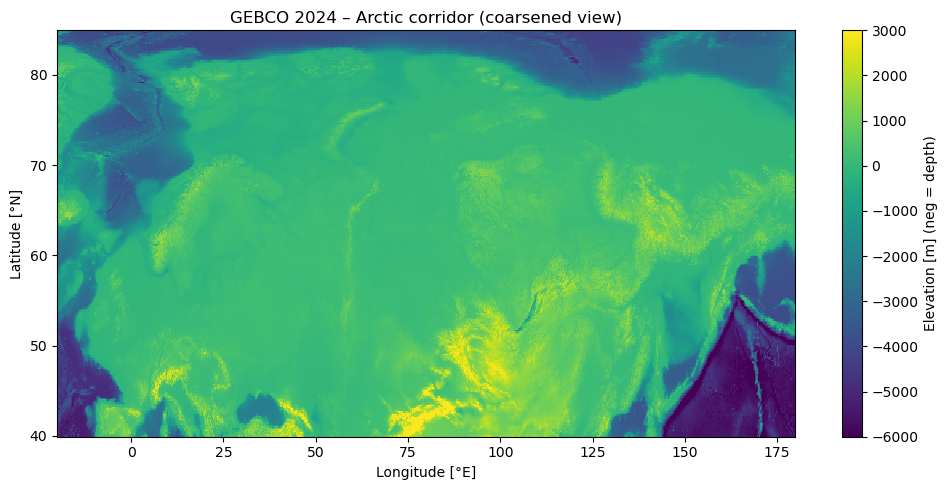

In [2]:
import matplotlib.pyplot as plt
import numpy as np

print("=== QUICKLOOK 1: Coarse GEBCO map ===")

# Subsample to avoid huge plot (step of 40 → ~0.17° resolution)
step = 40
depth_sample = ds["elevation"][::step, ::step]
lat_sample = ds["lat"][::step]
lon_sample = ds["lon"][::step]

print("Sampled shape:", depth_sample.shape)

plt.figure(figsize=(10, 5))
pcm = plt.pcolormesh(
    lon_sample,
    lat_sample,
    depth_sample,
    shading="auto",
    vmin=-6000,   # clip extremes for nicer contrast
    vmax=3000
)
plt.colorbar(pcm, label="Elevation [m] (neg = depth)")
plt.xlabel("Longitude [°E]")
plt.ylabel("Latitude [°N]")
plt.title("GEBCO 2024 – Arctic corridor (coarsened view)")
plt.tight_layout()
plt.show()

=== QUICKLOOK 2: Depth histogram (ocean only) ===
Number of ocean points: 251800571


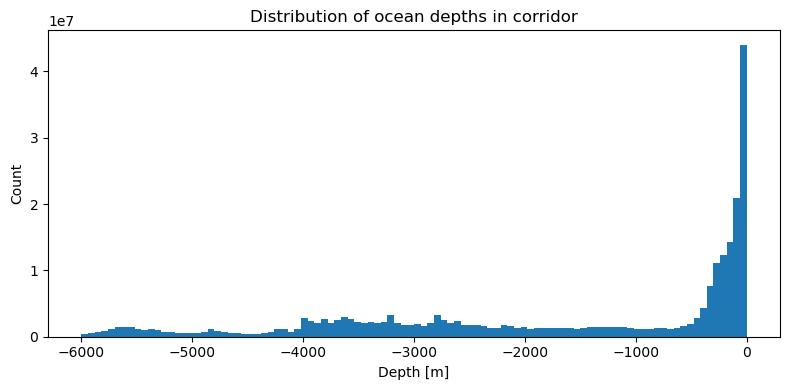

In [3]:
print("=== QUICKLOOK 2: Depth histogram (ocean only) ===")

depth = ds["elevation"]

# Load into memory as a NumPy array (1 GB, but doable on your machine; if it explodes, we’ll sample)
depth_np = depth.values

# Mask to ocean (negative depths)
ocean_depths = depth_np[depth_np < 0]

print("Number of ocean points:", ocean_depths.size)

plt.figure(figsize=(8, 4))
plt.hist(ocean_depths, bins=100, range=(-6000, 0))
plt.xlabel("Depth [m]")
plt.ylabel("Count")
plt.title("Distribution of ocean depths in corridor")
plt.tight_layout()
plt.show()

=== QUICKLOOK 3: Latitudinal cross-section ===
Mid-lat index: 5400 lat ≈ 62.50208333333333


/var/folders/6_/4517vxws0wq2qfxj8hkfdgdm0000gp/T/ipykernel_22047/1039082215.py:3: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  nlat = ds.dims["lat"]


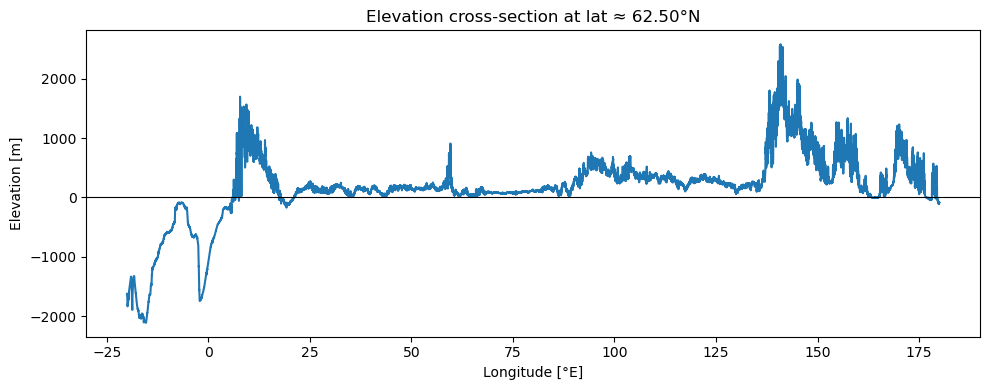

In [4]:
print("=== QUICKLOOK 3: Latitudinal cross-section ===")

nlat = ds.dims["lat"]
mid_ilat = nlat // 2
mid_lat = float(ds["lat"][mid_ilat].values)

print("Mid-lat index:", mid_ilat, "lat ≈", mid_lat)

section = depth.isel(lat=mid_ilat).values
lon_vals = ds["lon"].values

plt.figure(figsize=(10, 4))
plt.plot(lon_vals, section)
plt.axhline(0, color="k", linewidth=0.8)
plt.xlabel("Longitude [°E]")
plt.ylabel("Elevation [m]")
plt.title(f"Elevation cross-section at lat ≈ {mid_lat:.2f}°N")
plt.tight_layout()
plt.show()

=== FANCY PLOT A: Land/sea mask (coarse) ===
Land_sample shape: (270, 1200)


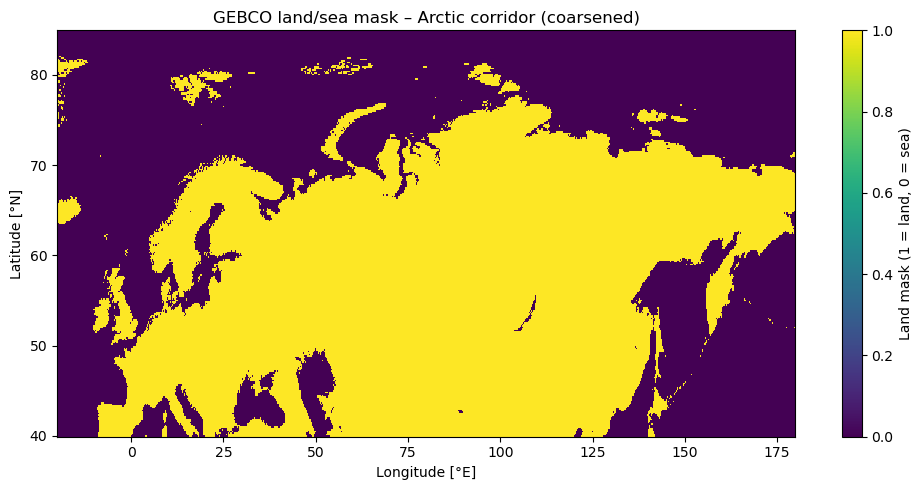

In [5]:
import matplotlib.pyplot as plt
import numpy as np

print("=== FANCY PLOT A: Land/sea mask (coarse) ===")

depth = ds["elevation"]

# land = elevation >= 0, sea = elevation < 0
land_mask_full = (depth >= 0)

# coarsen for plotting
step = 40
land_sample = land_mask_full[::step, ::step]
lat_sample = ds["lat"][::step]
lon_sample = ds["lon"][::step]

print("Land_sample shape:", land_sample.shape)

plt.figure(figsize=(10, 5))
pcm = plt.pcolormesh(
    lon_sample,
    lat_sample,
    land_sample,
    shading="auto"
)
plt.colorbar(pcm, label="Land mask (1 = land, 0 = sea)")
plt.xlabel("Longitude [°E]")
plt.ylabel("Latitude [°N]")
plt.title("GEBCO land/sea mask – Arctic corridor (coarsened)")
plt.tight_layout()
plt.show()

=== FANCY PLOT B: Zoomed bathymetry around NSR region ===
Subsampled zoom shape: (144, 720)


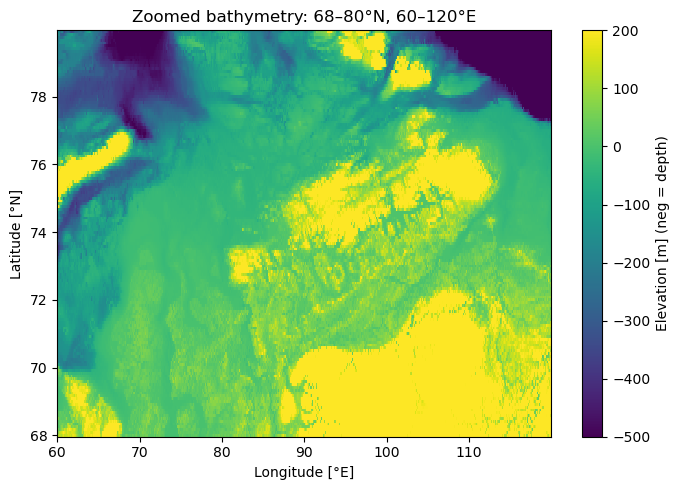

In [6]:
print("=== FANCY PLOT B: Zoomed bathymetry around NSR region ===")

def plot_zoomed_bathy(lat_min, lat_max, lon_min, lon_max, step=10, vmin=-1000, vmax=200):
    """
    Zoomed bathymetry plot for a sub-region.
    step: subsampling step on the high-res grid.
    vmin/vmax: color limits in meters (neg = deeper).
    """
    # subset indices
    lat_vals = ds["lat"].values
    lon_vals = ds["lon"].values

    lat_mask = (lat_vals >= lat_min) & (lat_vals <= lat_max)
    lon_mask = (lon_vals >= lon_min) & (lon_vals <= lon_max)

    if not lat_mask.any() or not lon_mask.any():
        print("No data in this lat/lon box.")
        return

    depth_sub = ds["elevation"].isel(
        lat=np.where(lat_mask)[0],
        lon=np.where(lon_mask)[0]
    )

    # subsample
    depth_sub = depth_sub[::step, ::step]
    lat_sub = ds["lat"].isel(lat=np.where(lat_mask)[0])[::step]
    lon_sub = ds["lon"].isel(lon=np.where(lon_mask)[0])[::step]

    print("Subsampled zoom shape:", depth_sub.shape)

    plt.figure(figsize=(7, 5))
    pcm = plt.pcolormesh(
        lon_sub,
        lat_sub,
        depth_sub,
        shading="auto",
        vmin=vmin,
        vmax=vmax
    )
    plt.colorbar(pcm, label="Elevation [m] (neg = depth)")
    plt.xlabel("Longitude [°E]")
    plt.ylabel("Latitude [°N]")
    plt.title(f"Zoomed bathymetry: {lat_min}–{lat_max}°N, {lon_min}–{lon_max}°E")
    plt.tight_layout()
    plt.show()

# Example: central NSR area (tweak as you like)
plot_zoomed_bathy(
    lat_min=68, lat_max=80,
    lon_min=60, lon_max=120,
    step=20,
    vmin=-500,  # focus on shallow vs deep
    vmax=200
)

=== FOLIUM LAND/SEA MASK MAP ===
Lat native resolution [deg]: 0.004166666666662877
Lon native resolution [deg]: 0.004166666666662877
Coarsening factors (lat, lon): 120 120
Coarse depth shape: (90, 400)
Coarse lat range: 40.25 to 84.75
Coarse lon range: -19.75 to 179.75
Land fraction (coarse): 0.5212222222222223
Sea fraction (coarse): 0.47877777777777775
Map center: 62.5 80.0
=== DONE: displaying folium map object 'm' ===



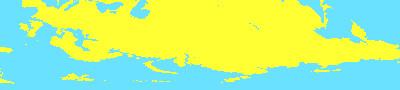

In [7]:
import numpy as np
import folium
from folium.raster_layers import ImageOverlay

print("=== FOLIUM LAND/SEA MASK MAP ===")

depth = ds["elevation"]
lat = ds["lat"].values
lon = ds["lon"].values

# --- 1) Work out index step for ~0.5° resolution ---
lat_res_deg = float(lat[1] - lat[0])
lon_res_deg = float(lon[1] - lon[0])
print("Lat native resolution [deg]:", lat_res_deg)
print("Lon native resolution [deg]:", lon_res_deg)

target_deg = 0.5  # target coarse resolution

step_lat = int(round(target_deg / lat_res_deg))
step_lon = int(round(target_deg / lon_res_deg))
print("Coarsening factors (lat, lon):", step_lat, step_lon)

# --- 2) Coarsen elevation to ~0.5° ---
depth_coarse = depth.coarsen(lat=step_lat, lon=step_lon, boundary="trim").mean()
lat_c = depth_coarse["lat"].values
lon_c = depth_coarse["lon"].values

print("Coarse depth shape:", depth_coarse.shape)
print("Coarse lat range:", float(lat_c.min()), "to", float(lat_c.max()))
print("Coarse lon range:", float(lon_c.min()), "to", float(lon_c.max()))

# --- 3) Land/sea mask on coarse grid ---
land_coarse = (depth_coarse >= 0).values  # True = land, False = sea

print("Land fraction (coarse):", land_coarse.mean())
print("Sea fraction (coarse):", 1.0 - land_coarse.mean())

# --- 4) Build RGB image: land = brown, sea = blue ---
h, w = land_coarse.shape
img = np.zeros((h, w, 3), dtype=np.uint8)

# sea: blue-ish
img[~land_coarse] = [50, 80, 200]
# land: brown/green-ish
img[land_coarse] = [120, 90, 40]

# --- 5) Create folium map ---
lat_center = float(lat_c.mean())
lon_center = float(lon_c.mean())
print("Map center:", lat_center, lon_center)

m = folium.Map(location=[lat_center, lon_center], zoom_start=2, tiles="CartoDB positron")

# bounds = [[south, west], [north, east]]
bounds = [
    [float(lat_c.min()), float(lon_c.min())],
    [float(lat_c.max()), float(lon_c.max())],
]

overlay = ImageOverlay(
    image=img,
    bounds=bounds,
    opacity=0.7,
    name="Land/Sea mask (coarse)",
    interactive=False,
    cross_origin=False,
    zindex=1,
)

overlay.add_to(m)
folium.LayerControl().add_to(m)

print("=== DONE: displaying folium map object 'm' ===")
m

=== FIXED FOLIUM LAND/SEA MASK MAP ===
Lat native resolution [deg]: 0.004166666666662877
Lon native resolution [deg]: 0.004166666666662877
Coarsening factors (lat, lon): 120 120
Coarse land_frac shape: (90, 400)
Land fraction (coarse, >0.5): 0.5135555555555555
Sea fraction (coarse): 0.48644444444444446
Map center: 62.5 80.0
=== DONE: displaying fixed folium map object 'm_fixed' ===



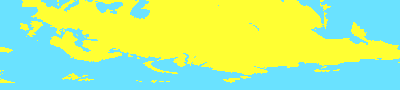

In [8]:
import numpy as np
import folium
from folium.raster_layers import ImageOverlay

print("=== FIXED FOLIUM LAND/SEA MASK MAP ===")

depth = ds["elevation"]
lat = ds["lat"].values
lon = ds["lon"].values

# 1) Native resolution step (just to see)
lat_res_deg = float(lat[1] - lat[0])
lon_res_deg = float(lon[1] - lon[0])
print("Lat native resolution [deg]:", lat_res_deg)
print("Lon native resolution [deg]:", lon_res_deg)

target_deg = 0.5  # target coarse resolution
step_lat = int(round(target_deg / lat_res_deg))
step_lon = int(round(target_deg / lon_res_deg))
print("Coarsening factors (lat, lon):", step_lat, step_lon)

# 2) Build high-res binary land mask: 1 = land, 0 = sea
land_hr = (depth >= 0).astype("int8")

# 3) Coarsen land mask and compute fraction of land in each coarse cell
land_frac = land_hr.coarsen(lat=step_lat, lon=step_lon, boundary="trim").mean()
lat_c = land_frac["lat"].values
lon_c = land_frac["lon"].values

print("Coarse land_frac shape:", land_frac.shape)

# threshold: >0.5 = mostly land, else sea
LAND_THRESHOLD = 0.5
land_coarse = (land_frac.values > LAND_THRESHOLD)

print("Land fraction (coarse, >0.5):", land_coarse.mean())
print("Sea fraction (coarse):", 1.0 - land_coarse.mean())

# 4) Build RGB image: land = brown, sea = blue
h, w = land_coarse.shape
img = np.zeros((h, w, 3), dtype=np.uint8)
img[~land_coarse] = [50, 80, 200]     # sea
img[land_coarse] = [120, 90, 40]      # land

# 5) Create folium map
lat_center = float(lat_c.mean())
lon_center = float(lon_c.mean())
print("Map center:", lat_center, lon_center)

m = folium.Map(location=[lat_center, lon_center], zoom_start=2, tiles="CartoDB positron")

bounds = [
    [float(lat_c.min()), float(lon_c.min())],
    [float(lat_c.max()), float(lon_c.max())],
]

overlay = ImageOverlay(
    image=img,
    bounds=bounds,
    opacity=0.7,
    name=f"Land/Sea mask (coarse, land_frac>{LAND_THRESHOLD})",
    interactive=False,
    cross_origin=False,
    zindex=1,
)

overlay.add_to(m)
folium.LayerControl().add_to(m)

print("=== DONE: displaying fixed folium map object 'm_fixed' ===")
m

=== SIMPLE LAND/SEA PLOT FROM GEBCO ===
Sampled shape: (270, 1200)
Land fraction (sampled): 0.5153086419753087
Sea fraction (sampled): 0.4846913580246913


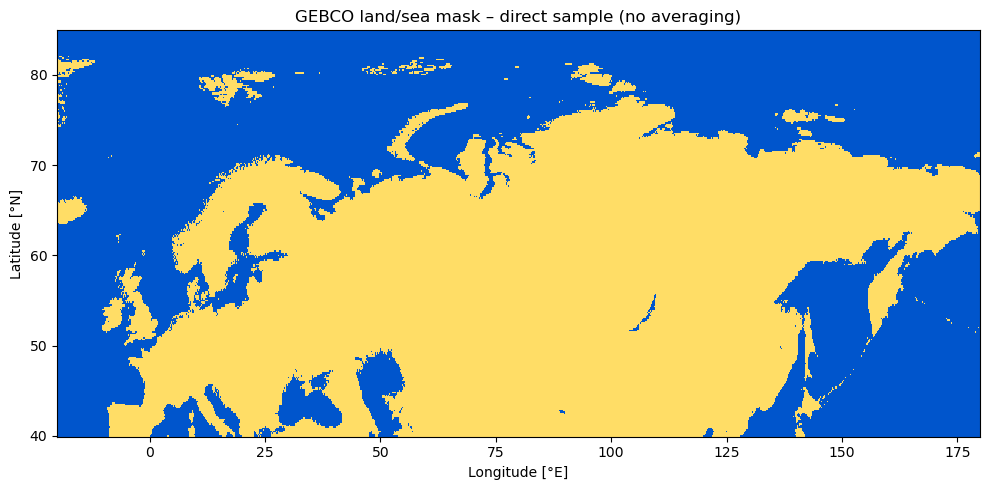

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

print("=== SIMPLE LAND/SEA PLOT FROM GEBCO ===")

depth = ds["elevation"]
lat = ds["lat"].values
lon = ds["lon"].values

# Simple downsampling by index step to keep it light
step = 40  # increase if it's still slow; decrease if you want more detail

lat_s = lat[::step]
lon_s = lon[::step]
depth_s = depth[::step, ::step].values  # no averaging, just picking every Nth point

# Binary land/sea mask: 1 = land, 0 = sea
land_mask = (depth_s >= 0).astype(int)

print("Sampled shape:", land_mask.shape)
print("Land fraction (sampled):", land_mask.mean())
print("Sea fraction (sampled):", 1.0 - land_mask.mean())

# Simple 2-color colormap: sea = blue, land = yellow
cmap = ListedColormap(["#0055cc", "#ffdd66"])

plt.figure(figsize=(10, 5))
plt.pcolormesh(lon_s, lat_s, land_mask, shading="auto", cmap=cmap)
plt.xlabel("Longitude [°E]")
plt.ylabel("Latitude [°N]")
plt.title("GEBCO land/sea mask – direct sample (no averaging)")
plt.tight_layout()
plt.show()

=== GLOBAL MAP WITH GEBCO LAND/SEA CORRIDOR ===
Sampled mask shape: (270, 1200)


/opt/miniconda3/envs/phd-paper2/lib/python3.10/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/opt/miniconda3/envs/phd-paper2/lib/python3.10/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/opt/miniconda3/envs/phd-paper2/lib/python3.10/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/opt/miniconda3/envs/phd-paper2/lib/python3.10/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/opt/miniconda3/envs/phd-paper2/lib/python3.10/site-packages/shapely/creation.py:730: RuntimeWarning

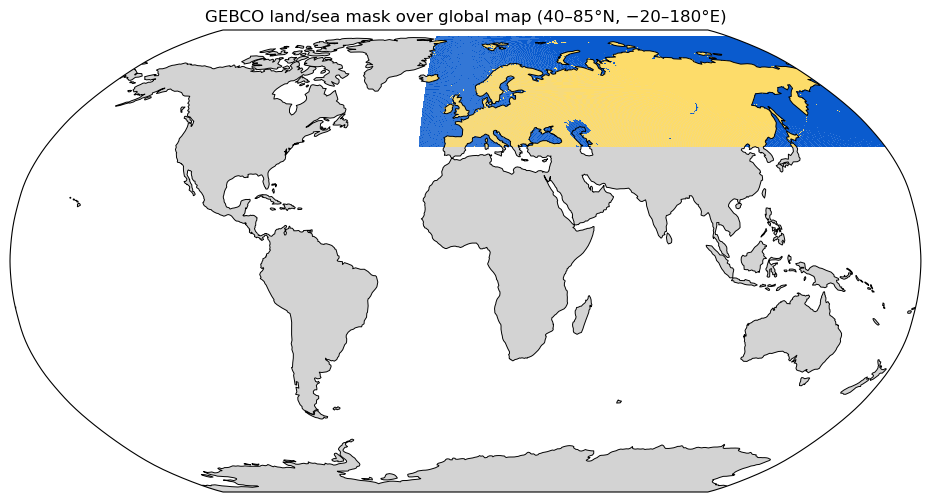

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import cartopy.crs as ccrs
import cartopy.feature as cfeature

print("=== GLOBAL MAP WITH GEBCO LAND/SEA CORRIDOR ===")

# 1) Sample GEBCO (no averaging, just take every Nth point)
step = 40   # change to 20 for more detail, 80 for lighter plot

lat_s = lat[::step]
lon_s = lon[::step]
depth_s = depth[::step, ::step].values   # shape: (len(lat_s), len(lon_s))

# Binary land/sea: 1 = land, 0 = sea
land_mask = (depth_s >= 0).astype(int)

print("Sampled mask shape:", land_mask.shape)

# 2-color colormap: sea = blue, land = yellow
cmap = ListedColormap(["#0055cc", "#ffdd66"])

# 2) Set up a global map projection
proj_map = ccrs.Robinson()      # pretty global view
proj_data = ccrs.PlateCarree()  # our data is in lat/lon degrees

fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=proj_map)

ax.set_global()
ax.coastlines(linewidth=0.7)
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=0)

# 3) Overlay our corridor land/sea mask
# pcolormesh with 1D lon/lat + 2D mask is fine
mesh = ax.pcolormesh(
    lon_s,
    lat_s,
    land_mask,
    transform=proj_data,
    cmap=cmap,
    shading="auto",
    alpha=0.8,
)

# Optional: draw the rectangle of the corridor
ax.set_title("GEBCO land/sea mask over global map (40–85°N, −20–180°E)")

plt.savefig("figA1_gebco_global_domain.png",
            dpi=300, bbox_inches="tight")
plt.show()

# Step 2

=== STEP 2: Define coarse routing grid (0.5°) ===
Target routing resolution [deg]: 0.5 0.5

--- Routing grid definition ---
lat_full min/max: 40.00208333333333 84.99791666666667
lon_full min/max: -19.99791666666667 179.99791666666667
lat_rg min/max: 40.5 84.5
lon_rg min/max: -19.5 179.5
n_lat_rg: 89
n_lon_rg: 399

First few lat diffs: [0.5 0.5 0.5 0.5]
First few lon diffs: [0.5 0.5 0.5 0.5]

Sampled mask shape for background plot: (270, 1200)


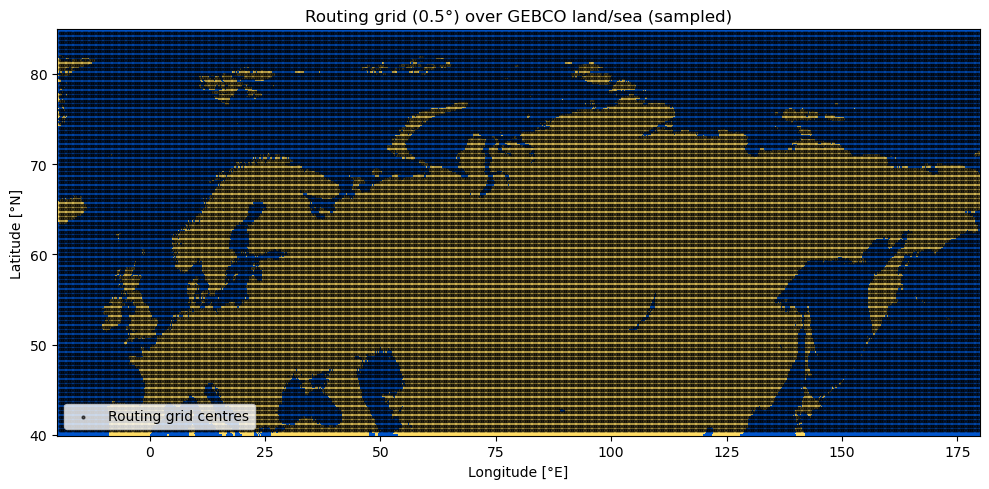


=== END STEP 2 ===


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

print("=== STEP 2: Define coarse routing grid (0.5°) ===")

# We assume ds, lat, lon, depth already from STEP 1
lat_full = ds["lat"].values
lon_full = ds["lon"].values

# 1) Choose target routing resolution
dlat_rg = 0.5
dlon_rg = 0.5
print("Target routing resolution [deg]:", dlat_rg, dlon_rg)

# 2) Compute min/max that align to 0.5°
lat_min = float(lat_full.min())
lat_max = float(lat_full.max())
lon_min = float(lon_full.min())
lon_max = float(lon_full.max())

lat_rg_min = np.ceil(lat_min / dlat_rg) * dlat_rg
lat_rg_max = np.floor(lat_max / dlat_rg) * dlat_rg
lon_rg_min = np.ceil(lon_min / dlon_rg) * dlon_rg
lon_rg_max = np.floor(lon_max / dlon_rg) * dlon_rg

# 3) Build routing grid (centres)
lats_rg = np.arange(lat_rg_min, lat_rg_max + 1e-6, dlat_rg)
lons_rg = np.arange(lon_rg_min, lon_rg_max + 1e-6, dlon_rg)

print("\n--- Routing grid definition ---")
print("lat_full min/max:", lat_min, lat_max)
print("lon_full min/max:", lon_min, lon_max)
print("lat_rg min/max:", lats_rg[0], lats_rg[-1])
print("lon_rg min/max:", lons_rg[0], lons_rg[-1])
print("n_lat_rg:", lats_rg.size)
print("n_lon_rg:", lons_rg.size)

# 4) Quick routing-grid spacing sanity (should be ~0.5 deg)
print("\nFirst few lat diffs:", np.diff(lats_rg[:5]))
print("First few lon diffs:", np.diff(lons_rg[:5]))

# 5) Build a simple land/sea sample from GEBCO to plot beneath (no averaging, just subsample)
step_sample = 40   # purely for plotting
lat_s = lat_full[::step_sample]
lon_s = lon_full[::step_sample]
depth_s = ds["elevation"][::step_sample, ::step_sample].values

land_mask_s = (depth_s >= 0).astype(int)  # 1 = land, 0 = sea

print("\nSampled mask shape for background plot:", land_mask_s.shape)

cmap_ls = ListedColormap(["#0055cc", "#ffdd66"])  # sea blue, land yellow

# 6) Plot: background land/sea + routing grid points
plt.figure(figsize=(10, 5))
plt.pcolormesh(lon_s, lat_s, land_mask_s, shading="auto", cmap=cmap_ls)
plt.scatter(
    lons_rg,
    np.full_like(lons_rg, lats_rg[0]),
    s=0, alpha=0
)  # dummy to ensure axes scale nicely

# Now overlay all routing grid centres as black dots
lon_mesh_rg, lat_mesh_rg = np.meshgrid(lons_rg, lats_rg)
plt.scatter(lon_mesh_rg, lat_mesh_rg, s=4, c="k", alpha=0.6, label="Routing grid centres")

plt.xlabel("Longitude [°E]")
plt.ylabel("Latitude [°N]")
plt.title("Routing grid (0.5°) over GEBCO land/sea (sampled)")
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()

print("\n=== END STEP 2 ===")

# Step 3

=== STEP 3: Land/sea mask on routing grid ===
Routing depth shape: (89, 399)
Routing depth min: -8709.0
Routing depth max: 5526.0
Sea fraction on routing grid: 0.48235757934161244
Land fraction on routing grid: 0.5176424206583875


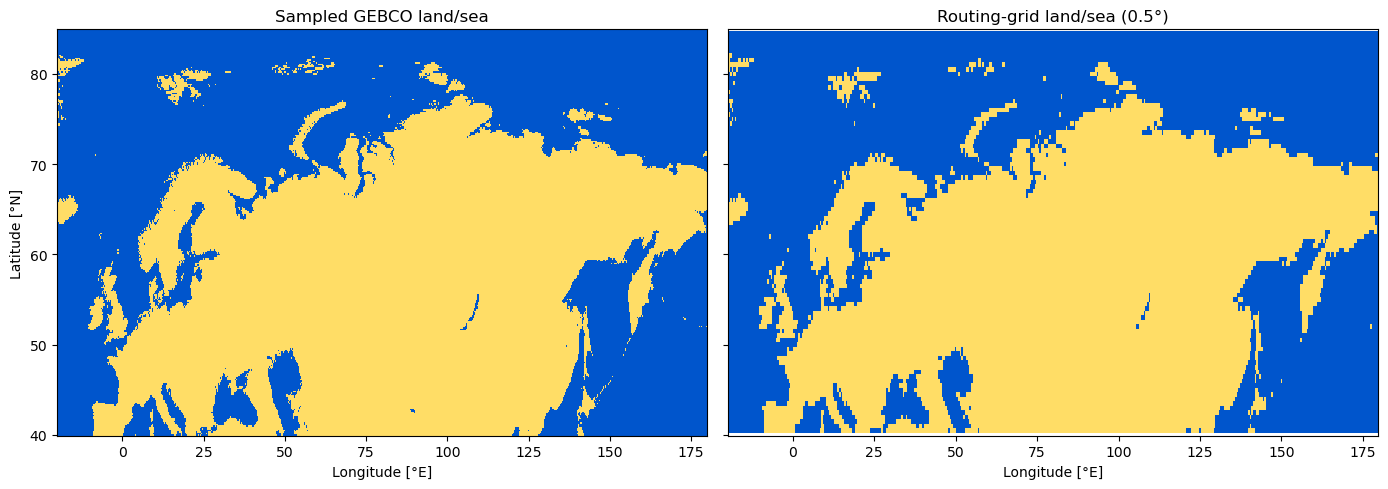

=== END STEP 3 ===


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

print("=== STEP 3: Land/sea mask on routing grid ===")

depth = ds["elevation"]

# 1) Interpolate elevation onto routing grid (nearest neighbour to keep it simple)
depth_rg = depth.interp(
    lat=("lat", lats_rg),
    lon=("lon", lons_rg),
    method="nearest"
)

print("Routing depth shape:", depth_rg.shape)
print("Routing depth min:", float(depth_rg.min().values))
print("Routing depth max:", float(depth_rg.max().values))

# 2) Land/sea mask on routing grid
#    1 = land (elev >= 0), 0 = sea (elev < 0)
land_rg = (depth_rg >= 0).astype(int).values
sea_rg = (depth_rg < 0).astype(int).values

sea_frac = sea_rg.mean()
land_frac = land_rg.mean()

print("Sea fraction on routing grid:", sea_frac)
print("Land fraction on routing grid:", land_frac)

# 3) Compare visually to sampled raw land/sea background
#    (re-use the sampled background from step 2)
cmap_ls = ListedColormap(["#0055cc", "#ffdd66"])  # sea blue, land yellow

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Left: sampled "truth" from GEBCO
im0 = axes[0].pcolormesh(
    lon_s, lat_s, land_mask_s,
    shading="auto", cmap=cmap_ls
)
axes[0].set_title("Sampled GEBCO land/sea")
axes[0].set_xlabel("Longitude [°E]")
axes[0].set_ylabel("Latitude [°N]")

# Right: routing-grid land/sea
im1 = axes[1].pcolormesh(
    lons_rg, lats_rg, land_rg,
    shading="auto", cmap=cmap_ls
)
axes[1].set_title("Routing-grid land/sea (0.5°)")
axes[1].set_xlabel("Longitude [°E]")

plt.tight_layout()
plt.show()

print("=== END STEP 3 ===")

=== OPTIONAL: sea components on routing grid ===
Number of sea components on routing grid: 23


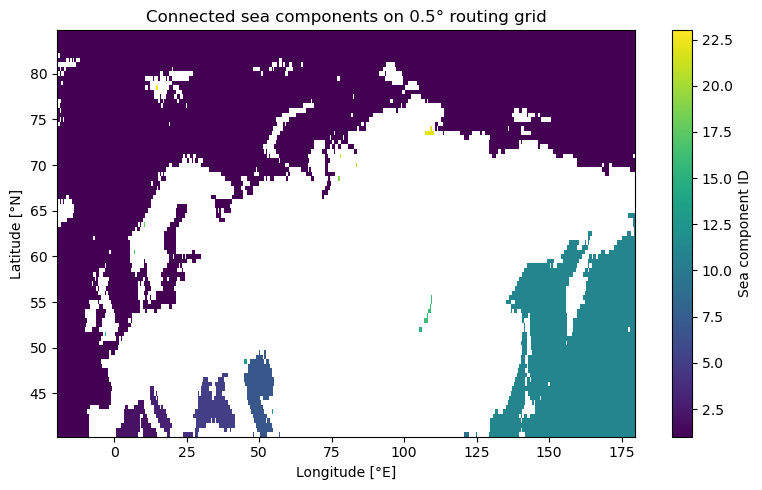

In [13]:
from scipy import ndimage as ndi
import matplotlib.pyplot as plt

print("=== OPTIONAL: sea components on routing grid ===")

sea_mask_rg = (land_rg == 0)  # True = sea
structure = ndi.generate_binary_structure(2, 2)  # 8-connected
labels_rg, num_comp_rg = ndi.label(sea_mask_rg, structure=structure)

print("Number of sea components on routing grid:", num_comp_rg)

plt.figure(figsize=(8, 5))
# show only where sea is; land is masked out
labels_plot = np.where(sea_mask_rg, labels_rg, np.nan)
plt.pcolormesh(lons_rg, lats_rg, labels_plot, shading="auto")
plt.colorbar(label="Sea component ID")
plt.title("Connected sea components on 0.5° routing grid")
plt.xlabel("Longitude [°E]")
plt.ylabel("Latitude [°N]")
plt.tight_layout()
plt.show()

=== OPTIONAL: Depth on 0.5° routing grid ===


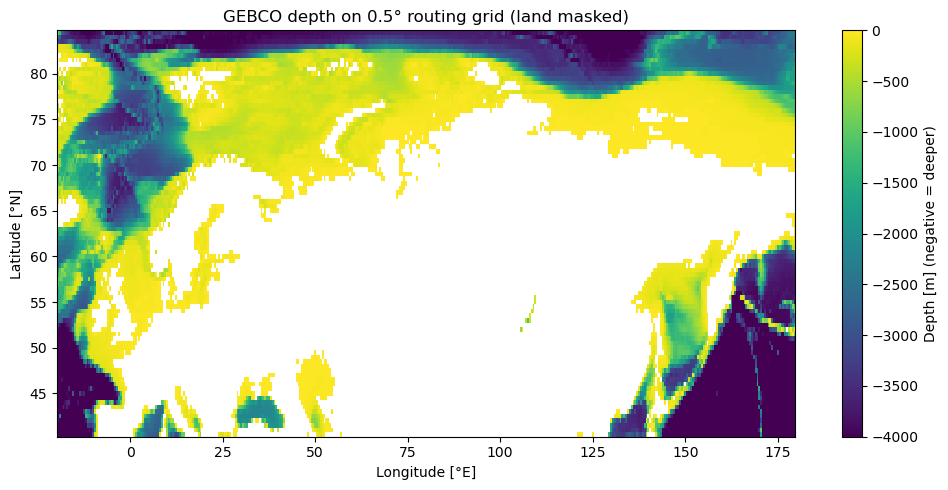

In [14]:
import numpy as np
import matplotlib.pyplot as plt

print("=== OPTIONAL: Depth on 0.5° routing grid ===")

# Mask land as NaN so we only see ocean depths
depth_rg_np = depth_rg.values.astype(float)
depth_rg_np[land_rg == 1] = np.nan  # hide land

plt.figure(figsize=(10, 5))
im = plt.pcolormesh(
    lons_rg,
    lats_rg,
    depth_rg_np,
    shading="auto",
    vmin=-4000,   # clip for contrast
    vmax=0
)
plt.colorbar(im, label="Depth [m] (negative = deeper)")
plt.xlabel("Longitude [°E]")
plt.ylabel("Latitude [°N]")
plt.title("GEBCO depth on 0.5° routing grid (land masked)")
plt.tight_layout()
plt.show()

# Step 4

=== STEP 4: Pick OD inside one sea component & check connectivity ===
Routing sea mask shape: (89, 399)
Sea fraction: 0.48235757934161244
Number of sea components on routing grid: 23
Largest sea component ID: 1 with cells: 13270
Largest component lat range: 40.5 to 84.5
Largest component lon range: -19.5 to 179.5

Chosen OD inside largest sea component:
  Start (west): index=(0,0), lat=40.50, lon=-19.50
  Goal  (east): index=(58,398), lat=69.50, lon=179.50

BFS reachable from start to goal in largest sea component? -> True


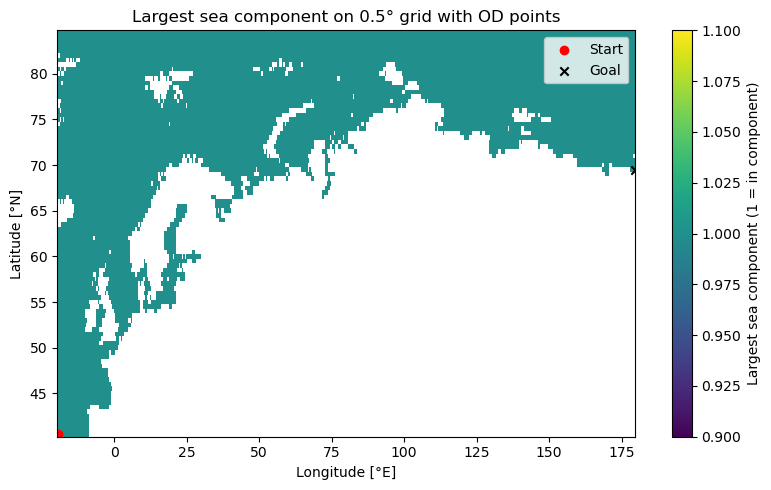

=== END STEP 4 ===


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage as ndi
from collections import deque

print("=== STEP 4: Pick OD inside one sea component & check connectivity ===")

# 0) Basic inputs we already have from previous steps:
#    lats_rg, lons_rg, land_rg  (0=sea, 1=land)
sea_mask_rg = (land_rg == 0)  # True = sea

print("Routing sea mask shape:", sea_mask_rg.shape)
print("Sea fraction:", sea_mask_rg.mean())

# 1) Label connected sea components (8-connected)
structure = ndi.generate_binary_structure(2, 2)
labels_rg, num_comp_rg = ndi.label(sea_mask_rg, structure=structure)

print("Number of sea components on routing grid:", num_comp_rg)

# 2) Find largest sea component (exclude label 0 = background)
counts = np.bincount(labels_rg.ravel())
counts[0] = 0
largest_comp_id = counts.argmax()
print("Largest sea component ID:", largest_comp_id, "with cells:", counts[largest_comp_id])

# 3) Extract indices of that component & choose westmost/eastmost points as OD
ii, jj = np.where(labels_rg == largest_comp_id)
comp_lats = lats_rg[ii]
comp_lons = lons_rg[jj]

print("Largest component lat range:", comp_lats.min(), "to", comp_lats.max())
print("Largest component lon range:", comp_lons.min(), "to", comp_lons.max())

# westmost & eastmost
west_idx = np.argmin(comp_lons)
east_idx = np.argmax(comp_lons)

ilat_start, ilon_start = ii[west_idx], jj[west_idx]
ilat_goal,  ilon_goal  = ii[east_idx], jj[east_idx]

start_lat = float(lats_rg[ilat_start])
start_lon = float(lons_rg[ilon_start])
goal_lat  = float(lats_rg[ilat_goal])
goal_lon  = float(lons_rg[ilon_goal])

print(f"\nChosen OD inside largest sea component:")
print(f"  Start (west): index=({ilat_start},{ilon_start}), lat={start_lat:.2f}, lon={start_lon:.2f}")
print(f"  Goal  (east): index=({ilat_goal},{ilon_goal}), lat={goal_lat:.2f}, lon={goal_lon:.2f}")

# 4) BFS connectivity check on this component
NEIGH_OFFSETS = [
    (-1, 0), (1, 0),
    (0, -1), (0, 1),
    (-1, -1), (-1, 1),
    (1, -1), (1, 1),
]

def bfs_reachable(mask, start_idx, goal_idx):
    nlat, nlon = mask.shape
    si, sj = start_idx
    gi, gj = goal_idx
    if not mask[si, sj]:
        print("Start is not sea in this mask.")
        return False
    if not mask[gi, gj]:
        print("Goal is not sea in this mask.")
        return False
    
    visited = np.zeros_like(mask, dtype=bool)
    q = deque()
    q.append((si, sj))
    visited[si, sj] = True
    
    while q:
        i, j = q.popleft()
        if i == gi and j == gj:
            return True
        for di, dj in NEIGH_OFFSETS:
            ni, nj = i + di, j + dj
            if 0 <= ni < nlat and 0 <= nj < nlon:
                if mask[ni, nj] and not visited[ni, nj]:
                    visited[ni, nj] = True
                    q.append((ni, nj))
    return False

reachable = bfs_reachable(
    sea_mask_rg,
    (ilat_start, ilon_start),
    (ilat_goal, ilon_goal),
)

print("\nBFS reachable from start to goal in largest sea component? ->", reachable)

# 5) Simple figure: show largest sea component, start & goal
comp_plot = np.where(labels_rg == largest_comp_id, 1, np.nan)  # 1 where in largest component, NaN elsewhere

plt.figure(figsize=(8, 5))
plt.pcolormesh(lons_rg, lats_rg, comp_plot, shading="auto")
plt.colorbar(label="Largest sea component (1 = in component)")
plt.scatter([start_lon], [start_lat], c="red", marker="o", label="Start")
plt.scatter([goal_lon], [goal_lat],  c="black", marker="x", label="Goal")
plt.xlabel("Longitude [°E]")
plt.ylabel("Latitude [°N]")
plt.title("Largest sea component on 0.5° grid with OD points")
plt.legend()
plt.tight_layout()
plt.show()

print("=== END STEP 4 ===")

=== OPTIONAL: BFS distance field inside largest sea component ===


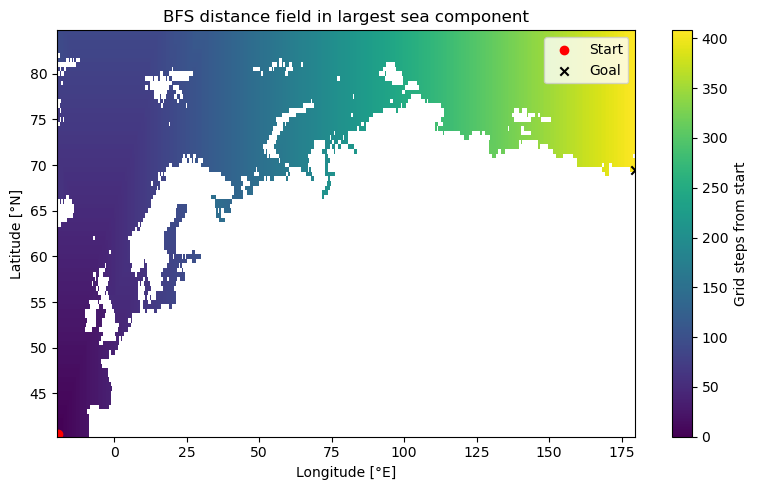

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

print("=== OPTIONAL: BFS distance field inside largest sea component ===")

nlat, nlon = sea_mask_rg.shape
dist = np.full((nlat, nlon), np.nan, dtype=float)

si, sj = ilat_start, ilon_start  # from Step 4
dist[si, sj] = 0.0

q = deque()
q.append((si, sj))

while q:
    i, j = q.popleft()
    for di, dj in NEIGH_OFFSETS:
        ni, nj = i + di, j + dj
        if 0 <= ni < nlat and 0 <= nj < nlon:
            if sea_mask_rg[ni, nj] and np.isnan(dist[ni, nj]):
                dist[ni, nj] = dist[i, j] + 1
                q.append((ni, nj))

plt.figure(figsize=(8, 5))
im = plt.pcolormesh(lons_rg, lats_rg, dist, shading="auto")
plt.colorbar(im, label="Grid steps from start")
plt.scatter([start_lon], [start_lat], c="red", marker="o", label="Start")
plt.scatter([goal_lon], [goal_lat],  c="black", marker="x", label="Goal")
plt.xlabel("Longitude [°E]")
plt.ylabel("Latitude [°N]")
plt.title("BFS distance field in largest sea component")
plt.legend()
plt.tight_layout()
plt.show()

# Step 5

=== STEP 5: Minimal A* route on sea_mask_rg ===
Start index: (0, 0) -> lat,lon = 40.5 -19.5
Goal  index: (58, 398) -> lat,lon = 69.5 179.5
  A*: reached goal after visiting 4942 nodes.
Path found. Number of steps: 409


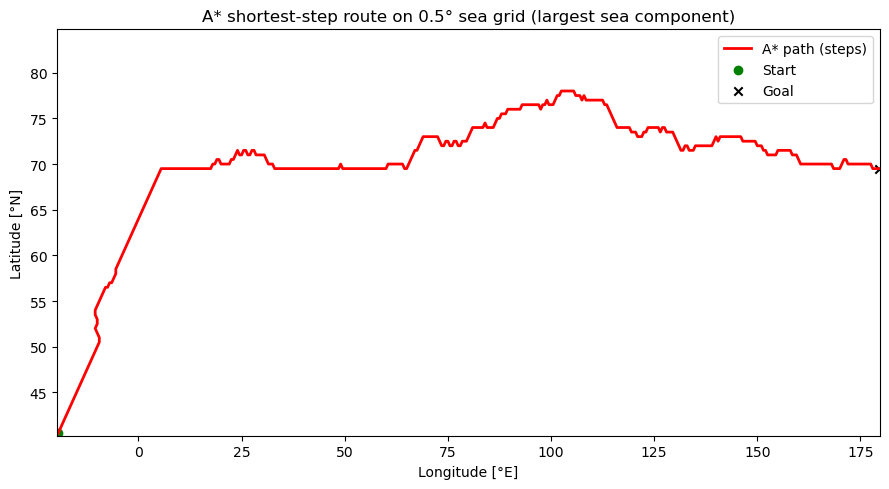

=== END STEP 5 ===


In [17]:
import numpy as np
import matplotlib.pyplot as plt
import heapq
from math import sqrt

print("=== STEP 5: Minimal A* route on sea_mask_rg ===")

# We assume from previous steps:
# - sea_mask_rg (True = sea, False = land)
# - lats_rg, lons_rg
# - ilat_start, ilon_start, ilat_goal, ilon_goal
# - NEIGH_OFFSETS (8-neighbourhood)

start_idx = (ilat_start, ilon_start)
goal_idx  = (ilat_goal, ilon_goal)

print("Start index:", start_idx, "-> lat,lon =", lats_rg[start_idx[0]], lons_rg[start_idx[1]])
print("Goal  index:", goal_idx,  "-> lat,lon =", lats_rg[goal_idx[0]],  lons_rg[goal_idx[1]])

nlat, nlon = sea_mask_rg.shape

def heuristic_grid(a, b):
    """Simple heuristic in grid space: Euclidean distance in (i,j) index space."""
    (i1, j1), (i2, j2) = a, b
    return sqrt((i1 - i2)**2 + (j1 - j2)**2)

def astar_route_steps(mask, start, goal):
    """
    Minimal A* on a 2D boolean mask.
    mask: True = traversable (sea), False = blocked (land)
    start, goal: (i, j) indices
    cost per step = 1 (we just minimise number of steps).
    """
    si, sj = start
    gi, gj = goal
    
    if not mask[si, sj]:
        raise RuntimeError("Start is not sea in this mask.")
    if not mask[gi, gj]:
        raise RuntimeError("Goal is not sea in this mask.")
    
    # g-costs (steps so far), init with inf
    g = np.full(mask.shape, np.inf, dtype=float)
    g[si, sj] = 0.0
    
    # parent pointers for path reconstruction
    parent_i = np.full(mask.shape, -1, dtype=int)
    parent_j = np.full(mask.shape, -1, dtype=int)
    
    # priority queue: (f, g, i, j)
    h0 = heuristic_grid(start, goal)
    pq = [(h0, 0.0, si, sj)]
    
    visited_count = 0
    
    while pq:
        f_curr, g_curr, i, j = heapq.heappop(pq)
        
        if g_curr > g[i, j]:
            continue  # stale entry
        
        visited_count += 1
        
        # goal check
        if (i, j) == (gi, gj):
            print("  A*: reached goal after visiting", visited_count, "nodes.")
            # reconstruct path
            path = []
            ci, cj = gi, gj
            while not (ci == si and cj == sj):
                path.append((ci, cj))
                pi, pj = parent_i[ci, cj], parent_j[ci, cj]
                if pi < 0:
                    raise RuntimeError("Broken parent chain during reconstruction.")
                ci, cj = pi, pj
            path.append((si, sj))
            path.reverse()
            return path
        
        # explore neighbours
        for di, dj in NEIGH_OFFSETS:
            ni, nj = i + di, j + dj
            if 0 <= ni < nlat and 0 <= nj < nlon:
                if not mask[ni, nj]:
                    continue  # land
                tentative_g = g_curr + 1.0  # cost per step
                if tentative_g < g[ni, nj]:
                    g[ni, nj] = tentative_g
                    parent_i[ni, nj] = i
                    parent_j[ni, nj] = j
                    h = heuristic_grid((ni, nj), goal)
                    f = tentative_g + h
                    heapq.heappush(pq, (f, tentative_g, ni, nj))
    
    raise RuntimeError("A* could not find a path between start and goal.")

# --- Run A* ---
path_indices = astar_route_steps(sea_mask_rg, start_idx, goal_idx)
print("Path found. Number of steps:", len(path_indices))

# --- Convert path to lat/lon arrays for plotting ---
path_lats = np.array([lats_rg[i] for i, j in path_indices])
path_lons = np.array([lons_rg[j] for i, j in path_indices])

# --- Plot: path over largest sea component ---
comp_plot = np.where(labels_rg == largest_comp_id, 1, np.nan)

plt.figure(figsize=(9, 5))
plt.pcolormesh(lons_rg, lats_rg, comp_plot, shading="auto", cmap="Greys", alpha=0.4)
plt.plot(path_lons, path_lats, "-r", linewidth=2, label="A* path (steps)")
plt.scatter([start_lon], [start_lat], c="green", marker="o", label="Start")
plt.scatter([goal_lon],  [goal_lat],  c="black", marker="x", label="Goal")
plt.xlabel("Longitude [°E]")
plt.ylabel("Latitude [°N]")
plt.title("A* shortest-step route on 0.5° sea grid (largest sea component)")
plt.legend()
plt.tight_layout()
plt.show()

print("=== END STEP 5 ===")

=== PLOT: A* path over routing grid & sampled land/sea ===


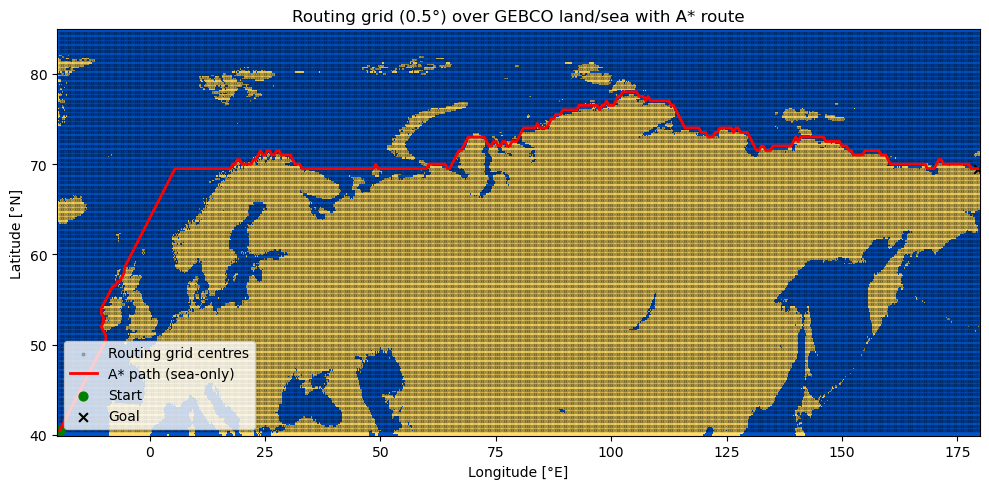

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

print("=== PLOT: A* path over routing grid & sampled land/sea ===")

cmap_ls = ListedColormap(["#0055cc", "#ffdd66"])  # sea blue, land yellow

# recreate routing grid mesh for dot plot
lon_mesh_rg, lat_mesh_rg = np.meshgrid(lons_rg, lats_rg)

plt.figure(figsize=(10, 5))

# background: sampled land/sea
plt.pcolormesh(lon_s, lat_s, land_mask_s, shading="auto", cmap=cmap_ls)

# routing grid centres (light grey dots so the path stands out)
plt.scatter(lon_mesh_rg, lat_mesh_rg, s=4, c="k", alpha=0.2, label="Routing grid centres")

# A* path in red
plt.plot(path_lons, path_lats, "-r", linewidth=2.0, label="A* path (sea-only)")

# start & goal markers
plt.scatter([start_lon], [start_lat], c="green", marker="o", s=40, label="Start")
plt.scatter([goal_lon],  [goal_lat],  c="black", marker="x", s=40, label="Goal")

plt.xlabel("Longitude [°E]")
plt.ylabel("Latitude [°N]")
plt.title("Routing grid (0.5°) over GEBCO land/sea with A* route")
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()

=== PLOT: A* path over depth on 0.5° grid ===


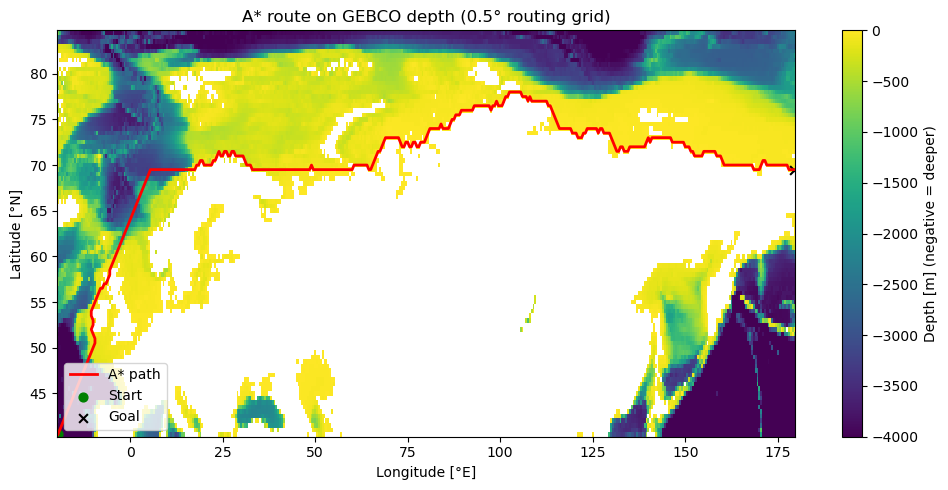

In [19]:
print("=== PLOT: A* path over depth on 0.5° grid ===")

# depth_rg is the xarray DataArray on the routing grid from previous step
depth_rg_np = depth_rg.values.astype(float)

# mask land as NaN so we only draw ocean depths
depth_rg_np[land_rg == 1] = np.nan

plt.figure(figsize=(10, 5))
im = plt.pcolormesh(
    lons_rg, lats_rg, depth_rg_np,
    shading="auto",
    vmin=-4000,  # clip for contrast
    vmax=0
)
plt.colorbar(im, label="Depth [m] (negative = deeper)")

# A* path
plt.plot(path_lons, path_lats, "-r", linewidth=2, label="A* path")

# start & goal
plt.scatter([start_lon], [start_lat], c="green", marker="o", s=40, label="Start")
plt.scatter([goal_lon],  [goal_lat],  c="black", marker="x", s=40, label="Goal")

plt.xlabel("Longitude [°E]")
plt.ylabel("Latitude [°N]")
plt.title("A* route on GEBCO depth (0.5° routing grid)")
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()

# Step 6

=== STEP 6: A* with great-circle distance cost ===
Start index: (0, 0) -> 40.5 -19.5
Goal  index: (58, 398) -> 69.5 179.5
  A*: reached goal after visiting 6412 nodes.
Path (distance-weighted) steps: 436
Total route distance [m]: 8447084.905566588
Total route distance [NM]: 4561.060964128827
Straight great-circle start→goal [NM]: 4149.566877288214
Route / straight ratio: 1.0991655512513465
Assuming 14.0 kn: travel time ≈ 13.57 days


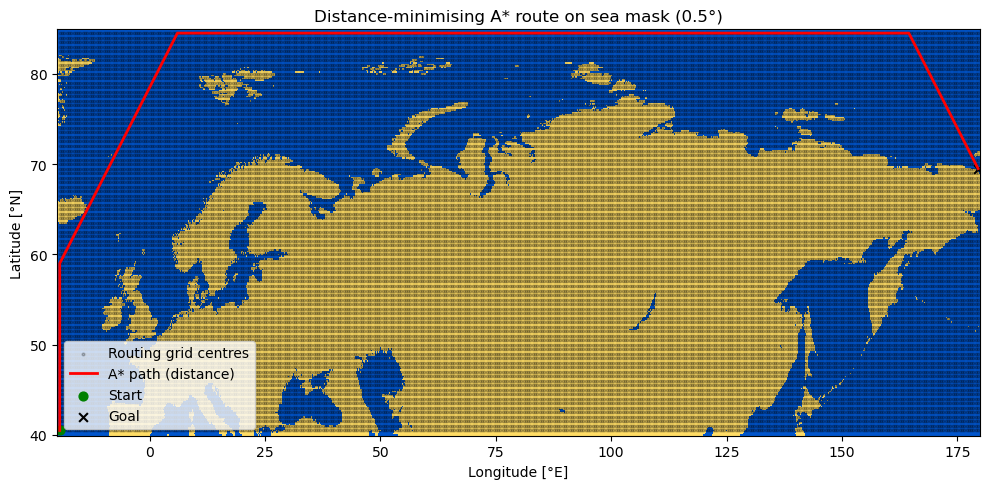

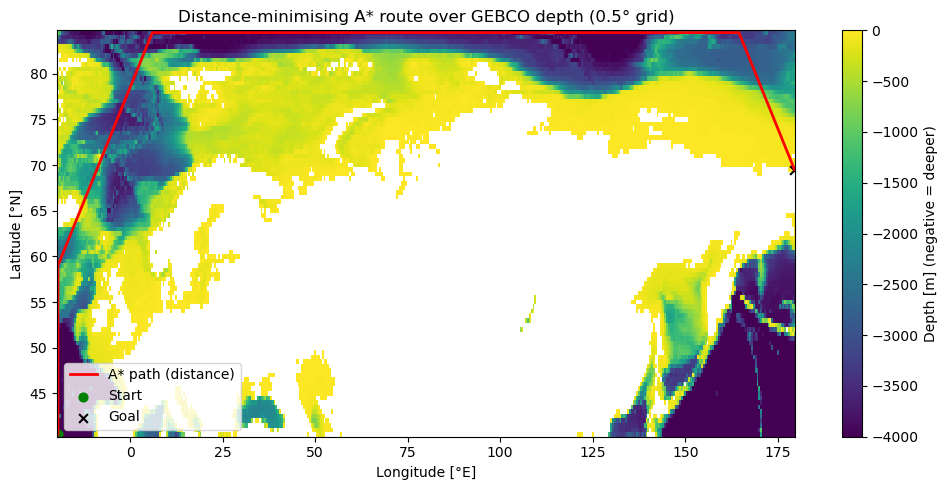

=== END STEP 6 ===


In [20]:
import numpy as np
import matplotlib.pyplot as plt
import heapq
from math import radians, sin, cos, atan2, sqrt

print("=== STEP 6: A* with great-circle distance cost ===")

# Reuse from previous steps:
# - lats_rg, lons_rg
# - sea_mask_rg (True = sea)
# - start_idx = (ilat_start, ilon_start)
# - goal_idx  = (ilat_goal, ilon_goal)
# - NEIGH_OFFSETS

start_idx = (ilat_start, ilon_start)
goal_idx  = (ilat_goal, ilon_goal)

print("Start index:", start_idx, "->", lats_rg[start_idx[0]], lons_rg[start_idx[1]])
print("Goal  index:", goal_idx,  "->", lats_rg[goal_idx[0]],  lons_rg[goal_idx[1]])

nlat, nlon = sea_mask_rg.shape

# --- 1) Haversine helpers ---
R_EARTH = 6371e3  # meters

def haversine(lat1, lon1, lat2, lon2):
    """Great-circle distance between two points in degrees."""
    phi1, phi2 = radians(lat1), radians(lat2)
    dphi = radians(lat2 - lat1)
    dlambda = radians(lon2 - lon1)
    a = sin(dphi/2.0)**2 + cos(phi1)*cos(phi2)*sin(dlambda/2.0)**2
    c = 2 * atan2(sqrt(a), sqrt(1.0 - a))
    return R_EARTH * c

def heuristic_gc(i1, j1, i2, j2):
    return haversine(lats_rg[i1], lons_rg[j1], lats_rg[i2], lons_rg[j2])

# --- 2) A* using physical distance as step cost ---
def astar_route_distance(mask, start, goal):
    si, sj = start
    gi, gj = goal
    
    if not mask[si, sj]:
        raise RuntimeError("Start is not sea in this mask.")
    if not mask[gi, gj]:
        raise RuntimeError("Goal is not sea in this mask.")
    
    g = np.full(mask.shape, np.inf, dtype=float)
    g[si, sj] = 0.0
    
    parent_i = np.full(mask.shape, -1, dtype=int)
    parent_j = np.full(mask.shape, -1, dtype=int)
    
    h0 = heuristic_gc(si, sj, gi, gj)
    pq = [(h0, 0.0, si, sj)]
    
    visited = 0
    
    while pq:
        f_curr, g_curr, i, j = heapq.heappop(pq)
        
        if g_curr > g[i, j]:
            continue  # stale
        
        visited += 1
        
        if (i, j) == (gi, gj):
            print("  A*: reached goal after visiting", visited, "nodes.")
            # reconstruct
            path = []
            ci, cj = gi, gj
            while not (ci == si and cj == sj):
                path.append((ci, cj))
                pi, pj = parent_i[ci, cj], parent_j[ci, cj]
                if pi < 0:
                    raise RuntimeError("Broken parent chain.")
                ci, cj = pi, pj
            path.append((si, sj))
            path.reverse()
            return path, g[gi, gj]  # path and total distance [m]
        
        for di, dj in NEIGH_OFFSETS:
            ni, nj = i + di, j + dj
            if 0 <= ni < nlat and 0 <= nj < nlon:
                if not mask[ni, nj]:
                    continue
                # edge cost = physical distance between cell centres
                step_cost = haversine(lats_rg[i], lons_rg[j], lats_rg[ni], lons_rg[nj])
                tentative_g = g_curr + step_cost
                if tentative_g < g[ni, nj]:
                    g[ni, nj] = tentative_g
                    parent_i[ni, nj] = i
                    parent_j[ni, nj] = j
                    h = heuristic_gc(ni, nj, gi, gj)
                    f = tentative_g + h
                    heapq.heappush(pq, (f, tentative_g, ni, nj))
    
    raise RuntimeError("A* (distance) could not find a path.")

# --- 3) Run A* with distance cost ---
path_idx_dist, total_dist_m = astar_route_distance(sea_mask_rg, start_idx, goal_idx)
print("Path (distance-weighted) steps:", len(path_idx_dist))
print("Total route distance [m]:", total_dist_m)

# basic conversions
total_dist_nm = total_dist_m / 1852.0
print("Total route distance [NM]:", total_dist_nm)

# straight great-circle between start & goal for reference
gc_straight_m = haversine(
    lats_rg[start_idx[0]], lons_rg[start_idx[1]],
    lats_rg[goal_idx[0]],  lons_rg[goal_idx[1]],
)
print("Straight great-circle start→goal [NM]:", gc_straight_m / 1852.0)
print("Route / straight ratio:", total_dist_m / gc_straight_m)

# travel time for reference speed (e.g. 14 kn ≈ 7.2 m/s)
V_REF_KTS = 14.0
V_REF_MS = V_REF_KTS * 0.514444
time_s = total_dist_m / V_REF_MS
time_days = time_s / 86400.0
print(f"Assuming {V_REF_KTS} kn: travel time ≈ {time_days:.2f} days")

# --- 4) Convert path to lat/lon for plotting ---
path_lats_dist = np.array([lats_rg[i] for i, j in path_idx_dist])
path_lons_dist = np.array([lons_rg[j] for i, j in path_idx_dist])

# --- 5) Plot over land/sea sampled background (like before) ---
from matplotlib.colors import ListedColormap

cmap_ls = ListedColormap(["#0055cc", "#ffdd66"])

lon_mesh_rg, lat_mesh_rg = np.meshgrid(lons_rg, lats_rg)

plt.figure(figsize=(10, 5))
plt.pcolormesh(lon_s, lat_s, land_mask_s, shading="auto", cmap=cmap_ls)
plt.scatter(lon_mesh_rg, lat_mesh_rg, s=4, c="k", alpha=0.2, label="Routing grid centres")
plt.plot(path_lons_dist, path_lats_dist, "-r", linewidth=2.0, label="A* path (distance)")
plt.scatter([start_lon], [start_lat], c="green", marker="o", s=40, label="Start")
plt.scatter([goal_lon],  [goal_lat],  c="black", marker="x", s=40, label="Goal")
plt.xlabel("Longitude [°E]")
plt.ylabel("Latitude [°N]")
plt.title("Distance-minimising A* route on sea mask (0.5°)")
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()

# --- 6) Optional: Same path over depth field on routing grid ---
depth_rg_np = depth_rg.values.astype(float)
depth_rg_np[land_rg == 1] = np.nan

plt.figure(figsize=(10, 5))
im = plt.pcolormesh(
    lons_rg, lats_rg, depth_rg_np,
    shading="auto",
    vmin=-4000, vmax=0
)
plt.colorbar(im, label="Depth [m] (negative = deeper)")
plt.plot(path_lons_dist, path_lats_dist, "-r", linewidth=2, label="A* path (distance)")
plt.scatter([start_lon], [start_lat], c="green", marker="o", s=40, label="Start")
plt.scatter([goal_lon],  [goal_lat],  c="black", marker="x", s=40, label="Goal")
plt.xlabel("Longitude [°E]")
plt.ylabel("Latitude [°N]")
plt.title("Distance-minimising A* route over GEBCO depth (0.5° grid)")
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()

print("=== END STEP 6 ===")

=== EXTRA 1: Depth profile along distance-minimising route ===


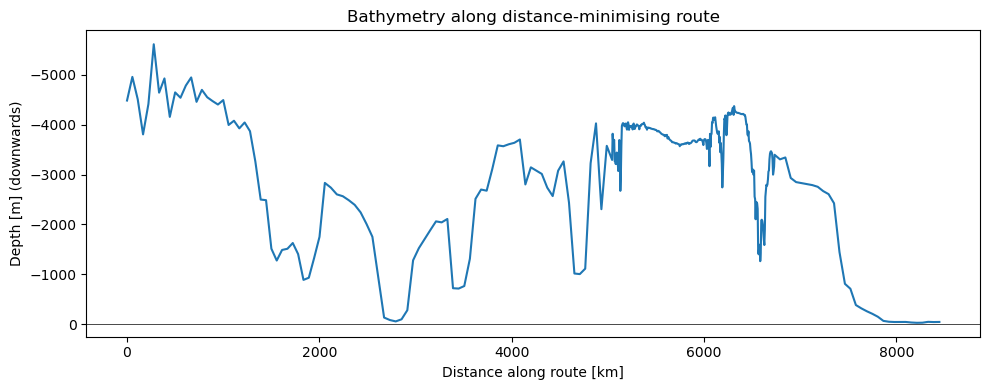

In [21]:
import numpy as np
import matplotlib.pyplot as plt

print("=== EXTRA 1: Depth profile along distance-minimising route ===")

# depth along path (using depth_rg on routing grid)
depth_along = []
for (i, j) in path_idx_dist:
    depth_along.append(float(depth_rg.values[i, j]))
depth_along = np.array(depth_along)

# cumulative distance along route (from total_dist_m)
segment_dists = [0.0]
for k in range(1, len(path_idx_dist)):
    i1, j1 = path_idx_dist[k-1]
    i2, j2 = path_idx_dist[k]
    dseg = haversine(lats_rg[i1], lons_rg[j1], lats_rg[i2], lons_rg[j2])
    segment_dists.append(segment_dists[-1] + dseg)
segment_dists = np.array(segment_dists)  # meters

plt.figure(figsize=(10, 4))
plt.plot(segment_dists / 1000.0, depth_along)
plt.axhline(0, color="k", linewidth=0.5)
plt.gca().invert_yaxis()  # deeper downwards
plt.xlabel("Distance along route [km]")
plt.ylabel("Depth [m] (downwards)")
plt.title("Bathymetry along distance-minimising route")
plt.tight_layout()
plt.show()

=== EXTRA 2: Lat–lon path coloured by depth ===


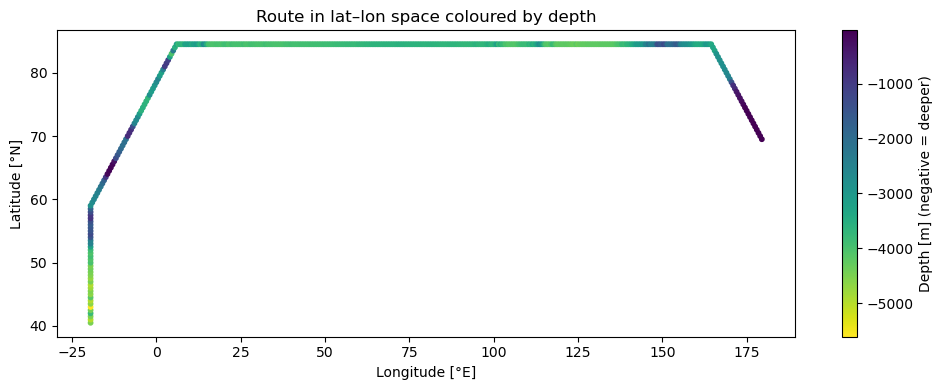

In [22]:
print("=== EXTRA 2: Lat–lon path coloured by depth ===")

# reuse depth_along from above
plt.figure(figsize=(10, 4))

sc = plt.scatter(
    path_lons_dist,
    path_lats_dist,
    c=depth_along,
    cmap="viridis_r",  # shallow = light, deep = dark (since we invert)
    s=10
)
plt.colorbar(sc, label="Depth [m] (negative = deeper)")
plt.xlabel("Longitude [°E]")
plt.ylabel("Latitude [°N]")
plt.title("Route in lat–lon space coloured by depth")
plt.tight_layout()
plt.show()

=== EXTRA 3: Route vs straight line in latitude ===


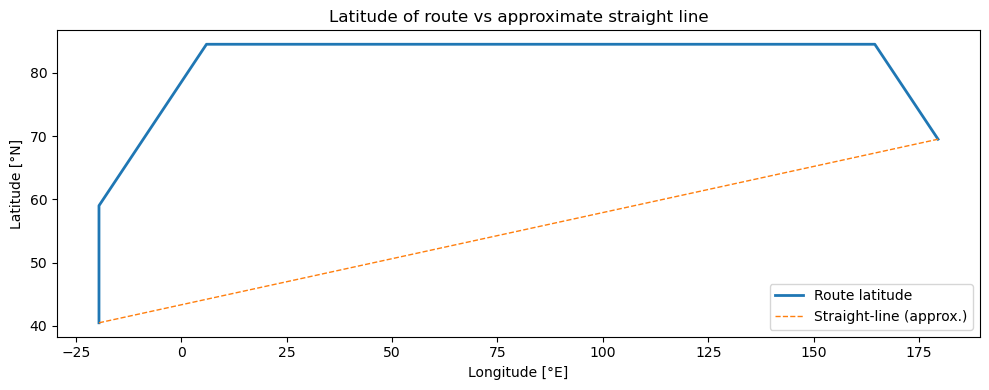

In [23]:
print("=== EXTRA 3: Route vs straight line in latitude ===")

# Straight great-circle sampled at the same longitudes (approximate: linear in lon)
lon_gc = np.linspace(path_lons_dist[0], path_lons_dist[-1], len(path_lons_dist))
lat_gc = np.linspace(path_lats_dist[0], path_lats_dist[-1], len(path_lats_dist))  # crude but illustrative

plt.figure(figsize=(10, 4))
plt.plot(path_lons_dist, path_lats_dist, label="Route latitude", linewidth=2)
plt.plot(lon_gc, lat_gc, "--", label="Straight-line (approx.)", linewidth=1)
plt.xlabel("Longitude [°E]")
plt.ylabel("Latitude [°N]")
plt.title("Latitude of route vs approximate straight line")
plt.legend()
plt.tight_layout()
plt.show()

# Step 7

In [24]:
import numpy as np
from scipy import ndimage as ndi
from math import radians, sin, cos, atan2, sqrt
import heapq

print("=== STEP 7: Define reusable routing helpers ===")

# -------------------------
# 1) Geometry helpers
# -------------------------

R_EARTH = 6371e3  # meters

def haversine(lat1, lon1, lat2, lon2):
    """Great-circle distance between two points [deg] -> meters."""
    phi1, phi2 = radians(lat1), radians(lat2)
    dphi = radians(lat2 - lat1)
    dlambda = radians(lon2 - lon1)
    a = sin(dphi/2.0)**2 + cos(phi1)*cos(phi2)*sin(dlambda/2.0)**2
    c = 2 * atan2(sqrt(a), sqrt(1.0 - a))
    return R_EARTH * c

def snap_to_grid(lat, lon, lats, lons):
    """
    Snap arbitrary (lat, lon) to nearest routing-grid indices.
    Returns (ilat, ilon).
    """
    ilat = int(np.argmin(np.abs(lats - lat)))
    ilon = int(np.argmin(np.abs(lons - lon)))
    return ilat, ilon

# -------------------------
# 2) Mask & components
# -------------------------

def label_sea_components(sea_mask, connectivity=2):
    """
    Label connected sea components on a 2D boolean mask.
    sea_mask: True = sea, False = land.
    connectivity: 1 = 4-neighbour, 2 = 8-neighbour.
    Returns (labels, num_components).
    """
    structure = ndi.generate_binary_structure(2, connectivity)
    labels, num = ndi.label(sea_mask, structure=structure)
    return labels, num

# -------------------------
# 3) A* distance router
# -------------------------

NEIGH_OFFSETS = [
    (-1, 0), (1, 0),
    (0, -1), (0, 1),
    (-1, -1), (-1, 1),
    (1, -1), (1, 1),
]

def astar_distance(sea_mask, lats, lons, start_idx, goal_idx, verbose=True):
    """
    A* shortest-distance route on a sea mask.
    sea_mask: 2D bool array (True = traversable sea, False = land/blocked)
    lats, lons: 1D arrays of grid centres
    start_idx, goal_idx: (ilat, ilon)
    
    Returns: (path_indices, total_dist_m)
      - path_indices: list of (i, j)
      - total_dist_m: total distance in meters along path
    """
    nlat, nlon = sea_mask.shape
    si, sj = start_idx
    gi, gj = goal_idx

    if not sea_mask[si, sj]:
        raise RuntimeError("Start is not sea in this mask.")
    if not sea_mask[gi, gj]:
        raise RuntimeError("Goal is not sea in this mask.")

    # g-costs
    g = np.full(sea_mask.shape, np.inf, dtype=float)
    g[si, sj] = 0.0

    parent_i = np.full(sea_mask.shape, -1, dtype=int)
    parent_j = np.full(sea_mask.shape, -1, dtype=int)

    def heuristic(i1, j1, i2, j2):
        return haversine(lats[i1], lons[j1], lats[i2], lons[j2])

    h0 = heuristic(si, sj, gi, gj)
    pq = [(h0, 0.0, si, sj)]
    visited = 0

    while pq:
        f_curr, g_curr, i, j = heapq.heappop(pq)
        if g_curr > g[i, j]:
            continue  # stale

        visited += 1

        if (i, j) == (gi, gj):
            if verbose:
                print(f"  A*: reached goal after visiting {visited} nodes.")
            # reconstruct
            path = []
            ci, cj = gi, gj
            while not (ci == si and cj == sj):
                path.append((ci, cj))
                pi, pj = parent_i[ci, cj], parent_j[ci, cj]
                if pi < 0:
                    raise RuntimeError("Broken parent chain.")
                ci, cj = pi, pj
            path.append((si, sj))
            path.reverse()
            return path, g[gi, gj]

        for di, dj in NEIGH_OFFSETS:
            ni, nj = i + di, j + dj
            if 0 <= ni < nlat and 0 <= nj < nlon and sea_mask[ni, nj]:
                step_cost = haversine(lats[i], lons[j], lats[ni], lons[nj])
                tentative_g = g_curr + step_cost
                if tentative_g < g[ni, nj]:
                    g[ni, nj] = tentative_g
                    parent_i[ni, nj] = i
                    parent_j[ni, nj] = j
                    h = heuristic(ni, nj, gi, gj)
                    f = tentative_g + h
                    heapq.heappush(pq, (f, tentative_g, ni, nj))

    raise RuntimeError("A* could not find a path between start and goal.")

# -------------------------
# 4) Route summary helper
# -------------------------

def summarise_route(path_idx, total_dist_m, lats, lons, depth_da=None, speed_kn=14.0):
    """
    Print a compact summary of a route.
    path_idx: list of (i, j)
    total_dist_m: scalar distance from A*
    depth_da: optional xarray DataArray on [lat, lon] for depth stats
    """
    total_dist_nm = total_dist_m / 1852.0
    start_i, start_j = path_idx[0]
    goal_i, goal_j = path_idx[-1]
    lat_s, lon_s = float(lats[start_i]), float(lons[start_j])
    lat_g, lon_g = float(lats[goal_i]), float(lons[goal_j])

    gc_direct_m = haversine(lat_s, lon_s, lat_g, lon_g)
    gc_direct_nm = gc_direct_m / 1852.0

    ratio = total_dist_m / gc_direct_m if gc_direct_m > 0 else np.nan

    v_ms = speed_kn * 0.514444
    time_s = total_dist_m / v_ms
    time_days = time_s / 86400.0

    print("---- Route summary ----")
    print(f"Start (lat,lon): ({lat_s:.2f}, {lon_s:.2f})")
    print(f"Goal  (lat,lon): ({lat_g:.2f}, {lon_g:.2f})")
    print(f"Route steps: {len(path_idx)}")
    print(f"Route distance: {total_dist_nm:.1f} NM ({total_dist_m/1000:.1f} km)")
    print(f"Straight GC : {gc_direct_nm:.1f} NM")
    print(f"Route / straight ratio: {ratio:.3f}")
    print(f"Travel time at {speed_kn:.1f} kn: {time_days:.2f} days")

    if depth_da is not None:
        depths = []
        for i, j in path_idx:
            depths.append(float(depth_da.values[i, j]))
        depths = np.array(depths)
        sea_depths = depths[depths < 0]  # ignore land
        if sea_depths.size > 0:
            print(f"Depth along route [m]: min={sea_depths.min():.1f}, "
                  f"mean={sea_depths.mean():.1f}, max={sea_depths.max():.1f}")
    print("------------------------")

print("Helpers defined.")

# -------------------------
# 5) Smoke test with existing OD
# -------------------------

print("\n=== Smoke test: reuse current start/goal on existing sea_mask_rg ===")

start_idx_test = (ilat_start, ilon_start)
goal_idx_test  = (ilat_goal, ilon_goal)

labels_test, ncomp_test = label_sea_components(sea_mask_rg)
print("Number of sea components (test):", ncomp_test)
print("Label(start), Label(goal):",
      labels_test[start_idx_test], labels_test[goal_idx_test])

path_idx_test, dist_m_test = astar_distance(
    sea_mask_rg, lats_rg, lons_rg,
    start_idx_test, goal_idx_test,
    verbose=True
)

summarise_route(path_idx_test, dist_m_test, lats_rg, lons_rg, depth_da=depth_rg)

print("=== END STEP 7 ===")

=== STEP 7: Define reusable routing helpers ===
Helpers defined.

=== Smoke test: reuse current start/goal on existing sea_mask_rg ===
Number of sea components (test): 23
Label(start), Label(goal): 1 1
  A*: reached goal after visiting 6412 nodes.
---- Route summary ----
Start (lat,lon): (40.50, -19.50)
Goal  (lat,lon): (69.50, 179.50)
Route steps: 436
Route distance: 4561.1 NM (8447.1 km)
Straight GC : 4149.6 NM
Route / straight ratio: 1.099
Travel time at 14.0 kn: 13.57 days
Depth along route [m]: min=-5612.0, mean=-3288.1, max=-29.0
------------------------
=== END STEP 7 ===


In [25]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

def plot_route_diagnostics(
    path_idx,
    lats_rg,
    lons_rg,
    lat_samp,
    lon_samp,
    land_mask_samp,
    depth_rg,
    land_rg,
    title_prefix="Route"
):
    """
    Plot a bundle of diagnostic figures for a route on the 0.5° grid.

    Parameters
    ----------
    path_idx : list of (i, j)
        Index pairs along the route.
    lats_rg, lons_rg : 1D arrays
        Routing grid latitudes and longitudes (centres).
    lat_samp, lon_samp : 1D arrays
        Sampled GEBCO lat/lon used for background land/sea plot.
    land_mask_samp : 2D array
        Sampled land/sea mask (1 = land, 0 = sea) for background.
    depth_rg : xarray DataArray
        GEBCO elevation on the routing grid (same shape as land_rg).
    land_rg : 2D array
        Land mask on routing grid (1 = land, 0 = sea).
    title_prefix : str
        Text prefix for figure titles.
    """

    # --- Convert path indices to lat/lon ---
    path_lats = np.array([lats_rg[i] for i, j in path_idx])
    path_lons = np.array([lons_rg[j] for i, j in path_idx])

    # --- Depth along route ---
    depth_vals = np.array([float(depth_rg.values[i, j]) for i, j in path_idx])

    # --- Cumulative distance along route (m) ---
    segment_dists = [0.0]
    for k in range(1, len(path_idx)):
        i1, j1 = path_idx[k-1]
        i2, j2 = path_idx[k]
        dseg = haversine(lats_rg[i1], lons_rg[j1], lats_rg[i2], lons_rg[j2])
        segment_dists.append(segment_dists[-1] + dseg)
    segment_dists = np.array(segment_dists)  # meters

    start_i, start_j = path_idx[0]
    goal_i, goal_j = path_idx[-1]
    start_lat, start_lon = float(lats_rg[start_i]), float(lons_rg[start_j])
    goal_lat,  goal_lon  = float(lats_rg[goal_i]), float(lons_rg[goal_j])

    # -----------------------------------------------------------------
    # 1) Route over sampled land/sea + routing grid
    # -----------------------------------------------------------------
    cmap_ls = ListedColormap(["#0055cc", "#ffdd66"])  # sea blue, land yellow
    lon_mesh_rg, lat_mesh_rg = np.meshgrid(lons_rg, lats_rg)

    plt.figure(figsize=(10, 5))
    plt.pcolormesh(lon_samp, lat_samp, land_mask_samp, shading="auto", cmap=cmap_ls)
    plt.scatter(lon_mesh_rg, lat_mesh_rg, s=4, c="k", alpha=0.2, label="Routing grid centres")
    plt.plot(path_lons, path_lats, "-r", linewidth=2.0, label="A* path")
    plt.scatter([start_lon], [start_lat], c="green", marker="o", s=40, label="Start")
    plt.scatter([goal_lon],  [goal_lat],  c="black", marker="x", s=40, label="Goal")
    plt.xlabel("Longitude [°E]")
    plt.ylabel("Latitude [°N]")
    plt.title(f"{title_prefix}: path over land/sea (sampled)")
    plt.legend(loc="lower left")
    plt.tight_layout()
    plt.show()

    # -----------------------------------------------------------------
    # 2) Route over depth on routing grid
    # -----------------------------------------------------------------
    depth_rg_np = depth_rg.values.astype(float)
    depth_rg_np[land_rg == 1] = np.nan  # mask land

    plt.figure(figsize=(10, 5))
    im = plt.pcolormesh(
        lons_rg, lats_rg, depth_rg_np,
        shading="auto",
        vmin=-4000, vmax=0
    )
    plt.colorbar(im, label="Depth [m] (negative = deeper)")
    plt.plot(path_lons, path_lats, "-r", linewidth=2, label="A* path")
    plt.scatter([start_lon], [start_lat], c="green", marker="o", s=40, label="Start")
    plt.scatter([goal_lon],  [goal_lat],  c="black", marker="x", s=40, label="Goal")
    plt.xlabel("Longitude [°E]")
    plt.ylabel("Latitude [°N]")
    plt.title(f"{title_prefix}: path over depth (0.5° grid)")
    plt.legend(loc="lower left")
    plt.tight_layout()
    plt.show()

    # -----------------------------------------------------------------
    # 3) Bathymetry profile along route
    # -----------------------------------------------------------------
    plt.figure(figsize=(10, 4))
    plt.plot(segment_dists / 1000.0, depth_vals)
    plt.axhline(0, color="k", linewidth=0.5)
    plt.gca().invert_yaxis()
    plt.xlabel("Distance along route [km]")
    plt.ylabel("Depth [m] (downwards)")
    plt.title(f"{title_prefix}: bathymetry along route")
    plt.tight_layout()
    plt.show()

    # -----------------------------------------------------------------
    # 4) Route in lat–lon space coloured by depth
    # -----------------------------------------------------------------
    plt.figure(figsize=(10, 4))
    sc = plt.scatter(
        path_lons,
        path_lats,
        c=depth_vals,
        cmap="viridis_r",   # shallow = light, deep = dark
        s=10
    )
    plt.colorbar(sc, label="Depth [m] (negative = deeper)")
    plt.xlabel("Longitude [°E]")
    plt.ylabel("Latitude [°N]")
    plt.title(f"{title_prefix}: route lat–lon coloured by depth")
    plt.tight_layout()
    plt.show()

    # -----------------------------------------------------------------
    # 5) Route latitude vs approximate straight line
    # -----------------------------------------------------------------
    lon_gc = np.linspace(start_lon, goal_lon, len(path_lons))
    lat_gc = np.linspace(start_lat, goal_lat, len(path_lats))  # simple linear approx

    plt.figure(figsize=(10, 4))
    plt.plot(path_lons, path_lats, label="Route latitude", linewidth=2)
    plt.plot(lon_gc, lat_gc, "--", label="Straight-line (approx.)", linewidth=1)
    plt.xlabel("Longitude [°E]")
    plt.ylabel("Latitude [°N]")
    plt.title(f"{title_prefix}: latitude of route vs approx. straight line")
    plt.legend()
    plt.tight_layout()
    plt.show()

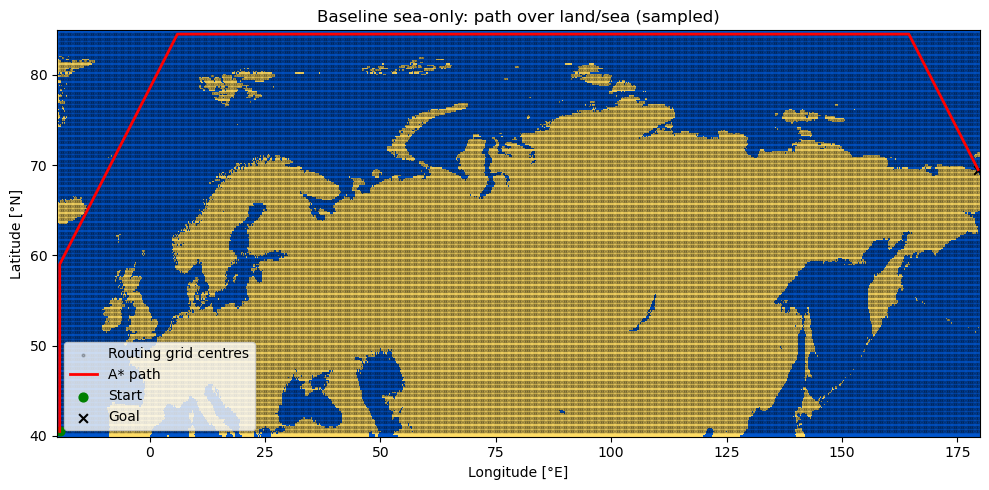

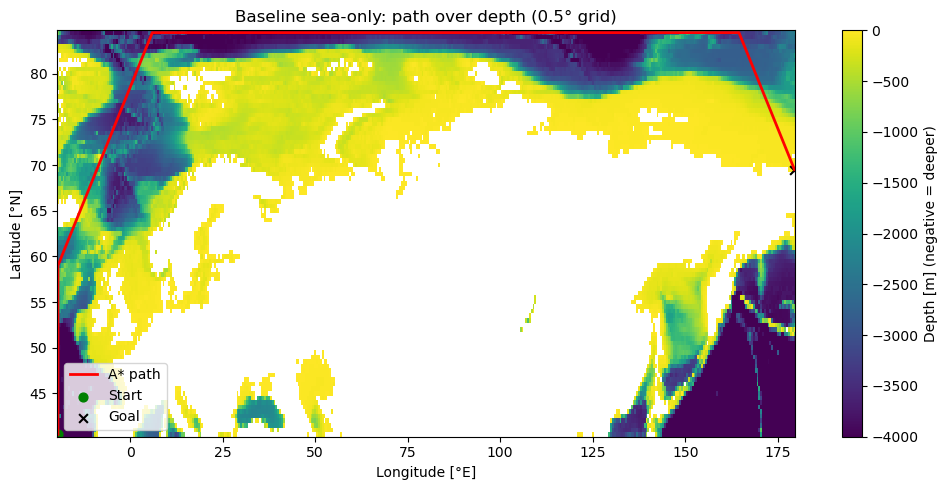

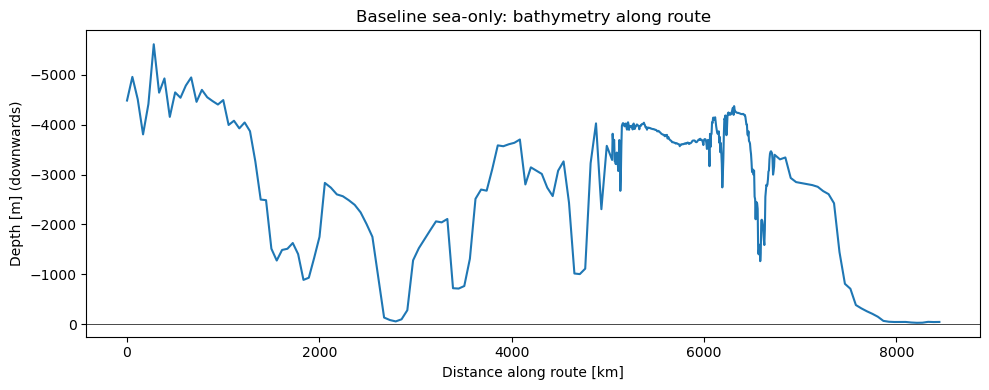

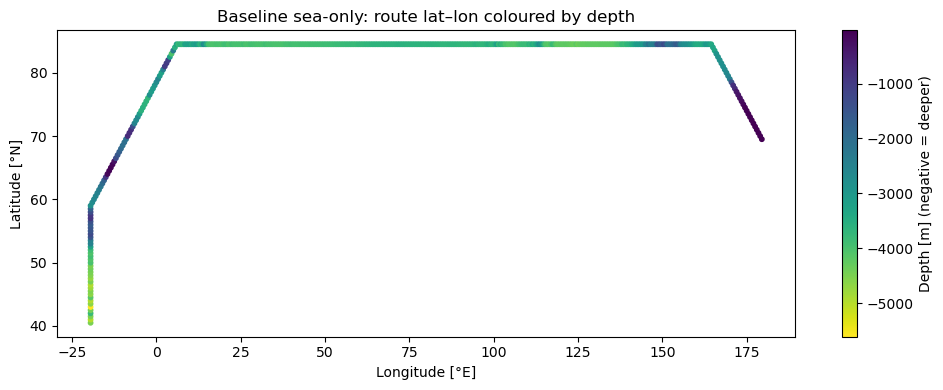

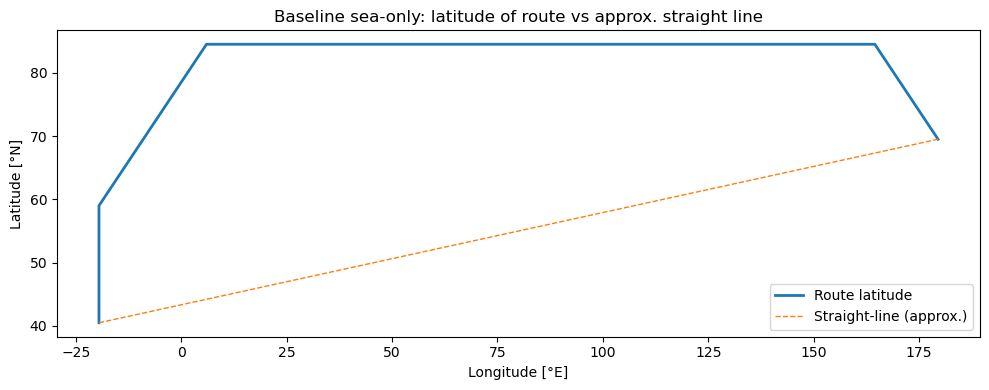

In [26]:
plot_route_diagnostics(
    path_idx_test,
    lats_rg,
    lons_rg,
    lat_s,
    lon_s,
    land_mask_s,
    depth_rg,
    land_rg,
    title_prefix="Baseline sea-only"
)

# Step 8

In [28]:
print("=== STEP 8: Baseline sea-only routes for example ODs ===")

# We assume we already have:
# - lats_rg, lons_rg
# - sea_mask_rg, land_rg
# - depth_rg
# - lat_s, lon_s, land_mask_s
# - helpers: snap_to_grid, label_sea_components, astar_distance, summarise_route, plot_route_diagnostics

# 1) Define a couple of OD pairs (lat, lon) in obvious open sea
od_cases = [
    {
        "name": "Case1_SWcorner_to_NEcorner",
        "start_lat": 40.5,
        "start_lon": -19.5,
        "goal_lat": 69.5,
        "goal_lon": 179.5,
        "plot_diagnostics": False,  # we've already studied this one in detail
    },
    {
        "name": "Case2_60N_Atlantic_to_60N_Pacific",
        "start_lat": 60.0,
        "start_lon": -10.0,
        "goal_lat": 60.0,
        "goal_lon": 150.0,
        "plot_diagnostics": True,   # new case: we’ll plot full diagnostics
    },
]

# 2) Label sea components once (bathy-only mask)
labels_rg, ncomp = label_sea_components(sea_mask_rg)
print("Sea components on routing grid:", ncomp)

for case in od_cases:
    name = case["name"]
    slat, slon = case["start_lat"], case["start_lon"]
    glat, glon = case["goal_lat"], case["goal_lon"]

    print(f"\n--- {name} ---")
    print(f"Requested start (lat,lon): ({slat:.2f}, {slon:.2f})")
    print(f"Requested goal  (lat,lon): ({glat:.2f}, {glon:.2f})")

    # Snap to nearest grid cells
    si, sj = snap_to_grid(slat, slon, lats_rg, lons_rg)
    gi, gj = snap_to_grid(glat, glon, lats_rg, lons_rg)

    start_lat_snap, start_lon_snap = float(lats_rg[si]), float(lons_rg[sj])
    goal_lat_snap,  goal_lon_snap  = float(lats_rg[gi]), float(lons_rg[gj])

    print(f"Snapped start -> idx=({si},{sj}), lat={start_lat_snap:.2f}, lon={start_lon_snap:.2f}")
    print(f"Snapped goal  -> idx=({gi},{gj}), lat={goal_lat_snap:.2f}, lon={goal_lon_snap:.2f}")

    # Check sea/land status
    print("Start sea?", bool(sea_mask_rg[si, sj]), "Goal sea?", bool(sea_mask_rg[gi, gj]))
    if not sea_mask_rg[si, sj] or not sea_mask_rg[gi, gj]:
        print("WARNING: snapped start or goal is on land. For now, skipping this case.")
        continue

    # Check component connectivity
    lab_start = labels_rg[si, sj]
    lab_goal  = labels_rg[gi, gj]
    print("Component ID (start, goal):", lab_start, lab_goal)

    if lab_start == 0 or lab_goal == 0 or lab_start != lab_goal:
        print("No sea-only connectivity between start and goal in this bathymetry mask. Skipping.")
        continue

    # Run A* distance
    path_idx, dist_m = astar_distance(
        sea_mask_rg, lats_rg, lons_rg,
        (si, sj), (gi, gj),
        verbose=True
    )

    # Summarise
    summarise_route(path_idx, dist_m, lats_rg, lons_rg, depth_da=depth_rg)

    # Optional full diagnostics plots
    if case.get("plot_diagnostics", False):
        plot_route_diagnostics(
            path_idx,
            lats_rg,
            lons_rg,
            lat_s,
            lon_s,
            land_mask_s,
            depth_rg,
            land_rg,
            title_prefix=name
        )

print("\n=== END STEP 8 ===")

=== STEP 8: Baseline sea-only routes for example ODs ===
Sea components on routing grid: 23

--- Case1_SWcorner_to_NEcorner ---
Requested start (lat,lon): (40.50, -19.50)
Requested goal  (lat,lon): (69.50, 179.50)
Snapped start -> idx=(0,0), lat=40.50, lon=-19.50
Snapped goal  -> idx=(58,398), lat=69.50, lon=179.50
Start sea? True Goal sea? True
Component ID (start, goal): 1 1
  A*: reached goal after visiting 6412 nodes.
---- Route summary ----
Start (lat,lon): (40.50, -19.50)
Goal  (lat,lon): (69.50, 179.50)
Route steps: 436
Route distance: 4561.1 NM (8447.1 km)
Straight GC : 4149.6 NM
Route / straight ratio: 1.099
Travel time at 14.0 kn: 13.57 days
Depth along route [m]: min=-5612.0, mean=-3288.1, max=-29.0
------------------------

--- Case2_60N_Atlantic_to_60N_Pacific ---
Requested start (lat,lon): (60.00, -10.00)
Requested goal  (lat,lon): (60.00, 150.00)
Snapped start -> idx=(39,19), lat=60.00, lon=-10.00
Snapped goal  -> idx=(39,339), lat=60.00, lon=150.00
Start sea? True Goal 

# Step 9

In [27]:
print("=== STEP 9: Real port ODs inside 40–85°N corridor ===")

# We assume we already have in memory:
# - lats_rg, lons_rg
# - sea_mask_rg (True = sea), land_rg
# - depth_rg
# - lat_s, lon_s, land_mask_s
# - helpers: haversine, snap_to_grid, label_sea_components,
#            astar_distance, summarise_route, plot_route_diagnostics

# 1) Define a small port dictionary (lat, lon in degrees)
ports = {
    "Rotterdam":   (51.885,   4.287),   # inside band
    "Murmansk":    (68.976,  33.051),   # inside band
    "Vladivostok": (43.10,  131.90),    # inside band
    "Yokohama":    (35.45,  139.64),    # outside 40–85N band
}

print("Ports defined:")
for name, (plat, plon) in ports.items():
    print(f"  {name}: lat={plat:.3f}, lon={plon:.3f}")

# 2) Helper: snap a port to nearest sea cell on the routing grid
def snap_port_to_sea(port_name, lat, lon, lats_rg, lons_rg, sea_mask, max_radius=5):
    """
    Snap a port (lat, lon) to the nearest sea cell on the routing grid.
    - First snap to nearest grid cell.
    - If that is land, search within a square neighbourhood up to max_radius in index space.
    Returns (i, j, snapped_lat, snapped_lon).
    Raises RuntimeError if no sea cell found within radius.
    """
    si, sj = snap_to_grid(lat, lon, lats_rg, lons_rg)
    nlat, nlon = sea_mask.shape

    if sea_mask[si, sj]:
        return si, sj, float(lats_rg[si]), float(lons_rg[sj])

    print(f"  Port {port_name}: initial snap is on land at idx=({si},{sj}). Searching nearby for sea...")

    best_i, best_j = None, None
    best_dist = np.inf

    for di in range(-max_radius, max_radius + 1):
        for dj in range(-max_radius, max_radius + 1):
            ni, nj = si + di, sj + dj
            if 0 <= ni < nlat and 0 <= nj < nlon and sea_mask[ni, nj]:
                # physical distance from port to this sea cell
                d = haversine(lat, lon, float(lats_rg[ni]), float(lons_rg[nj]))
                if d < best_dist:
                    best_dist = d
                    best_i, best_j = ni, nj

    if best_i is None:
        raise RuntimeError(f"Could not find sea cell near port {port_name} within radius {max_radius}.")

    snapped_lat = float(lats_rg[best_i])
    snapped_lon = float(lons_rg[best_j])
    print(f"  Port {port_name}: snapped to nearest sea cell at idx=({best_i},{best_j}), "
          f"lat={snapped_lat:.2f}, lon={snapped_lon:.2f}, offset ≈ {best_dist/1000:.1f} km")

    return best_i, best_j, snapped_lat, snapped_lon

# 3) Label sea components once (bathy-only)
labels_rg, ncomp = label_sea_components(sea_mask_rg)
print("\nSea components on routing grid:", ncomp)

# 4) Define OD cases using real ports that are inside our 40–85°N band
od_port_cases = [
    {
        "name": "Murmansk_to_Vladivostok",
        "start_port": "Murmansk",
        "goal_port": "Vladivostok",
        "plot_diagnostics": True,   # full plots for this one
    },
    {
        "name": "Rotterdam_to_Vladivostok",
        "start_port": "Rotterdam",
        "goal_port": "Vladivostok",
        "plot_diagnostics": False,  # just summary for now
    },
    # NOTE: Yokohama is outside our 40–85N band; we will treat that separately later
]

for case in od_port_cases:
    name = case["name"]
    sp_name = case["start_port"]
    gp_name = case["goal_port"]
    print(f"\n--- {name} ---")

    slat, slon = ports[sp_name]
    glat, glon = ports[gp_name]

    print(f"Start port {sp_name}: lat={slat:.2f}, lon={slon:.2f}")
    print(f"Goal  port {gp_name}: lat={glat:.2f}, lon={glon:.2f}")

    # Skip ports outside the 40–85N band (for now)
    if not (40.0 <= slat <= 85.0 and -20.0 <= slon <= 180.0):
        print(f"  WARNING: start port {sp_name} is outside the 40–85N corridor. Skipping for now.")
        continue
    if not (40.0 <= glat <= 85.0 and -20.0 <= glon <= 180.0):
        print(f"  WARNING: goal port {gp_name} is outside the 40–85N corridor. Skipping for now.")
        continue

    # Snap ports to nearest sea cells on the routing grid
    si, sj, s_lat_snap, s_lon_snap = snap_port_to_sea(
        sp_name, slat, slon, lats_rg, lons_rg, sea_mask_rg
    )
    gi, gj, g_lat_snap, g_lon_snap = snap_port_to_sea(
        gp_name, glat, glon, lats_rg, lons_rg, sea_mask_rg
    )

    print(f"Snapped start port {sp_name} -> idx=({si},{sj}), lat={s_lat_snap:.2f}, lon={s_lon_snap:.2f}")
    print(f"Snapped goal  port {gp_name} -> idx=({gi},{gj}), lat={g_lat_snap:.2f}, lon={g_lon_snap:.2f}")

    # Check components
    lab_start = labels_rg[si, sj]
    lab_goal  = labels_rg[gi, gj]
    print("Component ID (start, goal):", lab_start, lab_goal)

    if lab_start == 0 or lab_goal == 0 or lab_start != lab_goal:
        print("  No sea-only connectivity between start and goal in this bathymetry mask. Skipping.")
        continue

    # Run A* distance
    path_idx, dist_m = astar_distance(
        sea_mask_rg, lats_rg, lons_rg,
        (si, sj), (gi, gj),
        verbose=True
    )

    # Summarise
    summarise_route(path_idx, dist_m, lats_rg, lons_rg, depth_da=depth_rg)

    # Optional diagnostics
    if case.get("plot_diagnostics", False):
        plot_route_diagnostics(
            path_idx,
            lats_rg,
            lons_rg,
            lat_s,
            lon_s,
            land_mask_s,
            depth_rg,
            land_rg,
            title_prefix=name
        )

print("\n=== END STEP 9 ===")

=== STEP 9: Real port ODs inside 40–85°N corridor ===
Ports defined:
  Rotterdam: lat=51.885, lon=4.287
  Murmansk: lat=68.976, lon=33.051
  Vladivostok: lat=43.100, lon=131.900
  Yokohama: lat=35.450, lon=139.640

Sea components on routing grid: 23

--- Murmansk_to_Vladivostok ---
Start port Murmansk: lat=68.98, lon=33.05
Goal  port Vladivostok: lat=43.10, lon=131.90
  Port Murmansk: initial snap is on land at idx=(57,105). Searching nearby for sea...
  Port Murmansk: snapped to nearest sea cell at idx=(58,105), lat=69.50, lon=33.00, offset ≈ 58.3 km
Snapped start port Murmansk -> idx=(58,105), lat=69.50, lon=33.00
Snapped goal  port Vladivostok -> idx=(5,303), lat=43.00, lon=132.00
Component ID (start, goal): 1 11
  No sea-only connectivity between start and goal in this bathymetry mask. Skipping.

--- Rotterdam_to_Vladivostok ---
Start port Rotterdam: lat=51.88, lon=4.29
Goal  port Vladivostok: lat=43.10, lon=131.90
Snapped start port Rotterdam -> idx=(23,48), lat=52.00, lon=4.50
Sn

# Step 10

In [28]:
import numpy as np

print("=== STEP 10: Depth-constrained routing on canonical OD ===")

# We'll reuse the canonical OD from Step 7:
# path_idx_test contains the indices of the baseline sea-only route
start_idx = path_idx_test[0]
goal_idx  = path_idx_test[-1]
start_i, start_j = start_idx
goal_i,  goal_j  = goal_idx

print("Canonical OD (from baseline route):")
print("  Start idx:", start_idx, "-> lat,lon =",
      float(lats_rg[start_i]), float(lons_rg[start_j]))
print("  Goal  idx:", goal_idx,  "-> lat,lon =",
      float(lats_rg[goal_i]),  float(lons_rg[goal_j]))

# 1) Helper: build depth-safe mask for given minimum depth
def build_depth_mask(sea_mask, depth_da, min_depth_m):
    """
    Build a depth-constrained sea mask:
      - sea_mask: original sea (True) / land (False)
      - depth_da: xarray DataArray of bathymetry (negative = deeper)
      - min_depth_m: required minimum water depth in meters (e.g. 50 -> |depth| >= 50)

    Returns:
      depth_safe_mask: True where sea and depth <= -min_depth_m
    """
    depth_vals = depth_da.values
    deep_enough = depth_vals <= -min_depth_m  # e.g. <= -50 means at least 50 m deep
    depth_safe_mask = sea_mask & deep_enough
    return depth_safe_mask

# 2) Try a few reasonable depth thresholds
depth_thresholds_m = [20.0, 50.0, 200.0]

for h_min in depth_thresholds_m:
    print(f"\n--- Depth constraint: min depth = {h_min:.1f} m ---")

    depth_safe_mask = build_depth_mask(sea_mask_rg, depth_rg, h_min)

    # Basic stats
    sea_frac_original = sea_mask_rg.mean()
    sea_frac_safe = depth_safe_mask.mean()
    print(f"Original sea fraction: {sea_frac_original:.3f}")
    print(f"Depth-safe sea fraction: {sea_frac_safe:.3f} "
          f"({sea_frac_safe/sea_frac_original*100:.1f}% of original sea)")

    # Depth distribution on depth-safe sea cells
    depth_vals = depth_rg.values
    depths_safe = depth_vals[depth_safe_mask]
    if depths_safe.size > 0:
        print(f"Depth on safe sea cells [m]: "
              f"min={depths_safe.min():.1f}, "
              f"mean={depths_safe.mean():.1f}, "
              f"max={depths_safe.max():.1f}")
    else:
        print("No depth-safe sea cells at this threshold. Skipping.")
        continue

    # 3) Connectivity: label components on depth-safe mask
    labels_depth, ncomp_depth = label_sea_components(depth_safe_mask)
    print("Number of depth-safe sea components:", ncomp_depth)

    lab_start = labels_depth[start_i, start_j]
    lab_goal  = labels_depth[goal_i,  goal_j]
    print("Component ID (start, goal):", lab_start, lab_goal)

    if lab_start == 0 or lab_goal == 0:
        print("  Start or goal is not depth-safe sea at this threshold. No route.")
        continue
    if lab_start != lab_goal:
        print("  Start and goal lie in different depth-safe components. No depth-safe sea-only route.")
        continue

    # 4) Run A* on this depth-safe mask
    try:
        path_idx_depth, dist_m_depth = astar_distance(
            depth_safe_mask,
            lats_rg,
            lons_rg,
            start_idx,
            goal_idx,
            verbose=True
        )
    except RuntimeError as e:
        print("  A* failed on depth-safe mask:", e)
        continue

    # 5) Summarise this depth-constrained route
    print("Depth-constrained route summary:")
    summarise_route(path_idx_depth, dist_m_depth, lats_rg, lons_rg, depth_da=depth_rg)

    # 6) For one representative threshold (e.g. 50 m), plot full diagnostics
    if abs(h_min - 50.0) < 1e-6:
        print("Generating diagnostics plots for 50 m depth-constrained route...")
        plot_route_diagnostics(
            path_idx_depth,
            lats_rg,
            lons_rg,
            lat_s,
            lon_s,
            land_mask_s,
            depth_rg,
            land_rg,
            title_prefix=f"Depth>=50m"
        )

print("\n=== END STEP 10 ===")

=== STEP 10: Depth-constrained routing on canonical OD ===
Canonical OD (from baseline route):
  Start idx: (0, 0) -> lat,lon = 40.5 -19.5
  Goal  idx: (58, 398) -> lat,lon = 69.5 179.5

--- Depth constraint: min depth = 20.0 m ---
Original sea fraction: 0.482
Depth-safe sea fraction: 0.454 (94.1% of original sea)
Depth on safe sea cells [m]: min=-8709.0, mean=-1773.0, max=-20.0
Number of depth-safe sea components: 27
Component ID (start, goal): 1 1
  A*: reached goal after visiting 6364 nodes.
Depth-constrained route summary:
---- Route summary ----
Start (lat,lon): (40.50, -19.50)
Goal  (lat,lon): (69.50, 179.50)
Route steps: 436
Route distance: 4561.1 NM (8447.1 km)
Straight GC : 4149.6 NM
Route / straight ratio: 1.099
Travel time at 14.0 kn: 13.57 days
Depth along route [m]: min=-5612.0, mean=-3288.1, max=-29.0
------------------------

--- Depth constraint: min depth = 50.0 m ---
Original sea fraction: 0.482
Depth-safe sea fraction: 0.408 (84.6% of original sea)
Depth on safe sea 

# Step 10b

In [29]:
import numpy as np

print("=== STEP 10b: Depth-constrained routing with relaxed endpoints ===")

# Reuse canonical OD from Step 7 / 10:
start_idx = path_idx_test[0]
goal_idx  = path_idx_test[-1]
start_i, start_j = start_idx
goal_i,  goal_j  = goal_idx

print("Canonical OD (from baseline route):")
print("  Start idx:", start_idx, "-> lat,lon =",
      float(lats_rg[start_i]), float(lons_rg[start_j]))
print("  Goal  idx:", goal_idx,  "-> lat,lon =",
      float(lats_rg[goal_i]),  float(lons_rg[goal_j]))

def build_depth_mask(sea_mask, depth_da, min_depth_m):
    depth_vals = depth_da.values
    deep_enough = depth_vals <= -min_depth_m  # e.g. <= -50 means at least 50 m deep
    return sea_mask & deep_enough

# Same thresholds as before
depth_thresholds_m = [20.0, 50.0, 200.0]

for h_min in depth_thresholds_m:
    print(f"\n--- Depth constraint (endpoints relaxed): min depth = {h_min:.1f} m ---")

    # 1) Basic depth-safe mask
    depth_safe_mask = build_depth_mask(sea_mask_rg, depth_rg, h_min)

    # 2) Relax endpoints: allow start & goal cells even if shallower
    depth_safe_relaxed = depth_safe_mask.copy()
    # Ensure start/goal are allowed if they are sea in the original mask
    if sea_mask_rg[start_i, start_j]:
        depth_safe_relaxed[start_i, start_j] = True
    if sea_mask_rg[goal_i, goal_j]:
        depth_safe_relaxed[goal_i, goal_j] = True

    # Basic statistics
    sea_frac_original = sea_mask_rg.mean()
    sea_frac_safe = depth_safe_mask.mean()
    sea_frac_relaxed = depth_safe_relaxed.mean()
    print(f"Original sea fraction:       {sea_frac_original:.3f}")
    print(f"Depth-safe sea fraction:     {sea_frac_safe:.3f} "
          f"({sea_frac_safe/sea_frac_original*100:.1f}% of original sea)")
    print(f"Depth-safe (end-relaxed):    {sea_frac_relaxed:.3f} "
          f"({sea_frac_relaxed/sea_frac_original*100:.1f}% of original sea)")

    depth_vals = depth_rg.values
    depths_safe = depth_vals[depth_safe_mask]
    if depths_safe.size > 0:
        print(f"Depth on strictly safe sea cells [m]: "
              f"min={depths_safe.min():.1f}, "
              f"mean={depths_safe.mean():.1f}, "
              f"max={depths_safe.max():.1f}")
    else:
        print("No strictly depth-safe sea cells at this threshold. Skipping.")
        continue

    # 3) Connectivity on relaxed mask
    labels_relaxed, ncomp_relaxed = label_sea_components(depth_safe_relaxed)
    print("Number of depth-safe components (relaxed):", ncomp_relaxed)

    lab_start = labels_relaxed[start_i, start_j]
    lab_goal  = labels_relaxed[goal_i,  goal_j]
    print("Component ID (start, goal) on relaxed mask:", lab_start, lab_goal)

    if lab_start == 0 or lab_goal == 0:
        print("  Even with relaxed endpoints, start or goal is not in a depth-safe component. No route.")
        continue
    if lab_start != lab_goal:
        print("  Start and goal lie in different depth-safe components (relaxed). No route.")
        continue

    # 4) Run A* on relaxed mask
    try:
        path_idx_depth_relaxed, dist_m_depth_relaxed = astar_distance(
            depth_safe_relaxed,
            lats_rg,
            lons_rg,
            start_idx,
            goal_idx,
            verbose=True
        )
    except RuntimeError as e:
        print("  A* failed on relaxed depth-safe mask:", e)
        continue

    # 5) Summarise
    print("Depth-constrained (end-relaxed) route summary:")
    summarise_route(
        path_idx_depth_relaxed,
        dist_m_depth_relaxed,
        lats_rg,
        lons_rg,
        depth_da=depth_rg
    )

    # 6) For 50 m, plot diagnostics so we see how it differs from baseline
    if abs(h_min - 50.0) < 1e-6:
        print("Generating diagnostics plots for 50 m (end-relaxed) route...")
        plot_route_diagnostics(
            path_idx_depth_relaxed,
            lats_rg,
            lons_rg,
            lat_s,
            lon_s,
            land_mask_s,
            depth_rg,
            land_rg,
            title_prefix="Depth>=50m_endpoints_relaxed"
        )

print("\n=== END STEP 10b ===")

=== STEP 10b: Depth-constrained routing with relaxed endpoints ===
Canonical OD (from baseline route):
  Start idx: (0, 0) -> lat,lon = 40.5 -19.5
  Goal  idx: (58, 398) -> lat,lon = 69.5 179.5

--- Depth constraint (endpoints relaxed): min depth = 20.0 m ---
Original sea fraction:       0.482
Depth-safe sea fraction:     0.454 (94.1% of original sea)
Depth-safe (end-relaxed):    0.454 (94.1% of original sea)
Depth on strictly safe sea cells [m]: min=-8709.0, mean=-1773.0, max=-20.0
Number of depth-safe components (relaxed): 27
Component ID (start, goal) on relaxed mask: 1 1
  A*: reached goal after visiting 6364 nodes.
Depth-constrained (end-relaxed) route summary:
---- Route summary ----
Start (lat,lon): (40.50, -19.50)
Goal  (lat,lon): (69.50, 179.50)
Route steps: 436
Route distance: 4561.1 NM (8447.1 km)
Straight GC : 4149.6 NM
Route / straight ratio: 1.099
Travel time at 14.0 kn: 13.57 days
Depth along route [m]: min=-5612.0, mean=-3288.1, max=-29.0
------------------------

--- D

=== STEP 10b: Depth-constrained routing with relaxed endpoints ===
Canonical OD (from baseline route):
  Start idx: (0, 0) -> lat,lon = 40.5 -19.5
  Goal  idx: (58, 398) -> lat,lon = 69.5 179.5

--- Depth constraint (endpoints relaxed): min depth = 20.0 m ---
Original sea fraction:       0.482
Depth-safe sea fraction:     0.454 (94.1% of original sea)
Depth-safe (end-relaxed):    0.454 (94.1% of original sea)
Depth on strictly safe sea cells [m]: min=-8709.0, mean=-1773.0, max=-20.0
Number of depth-safe components (relaxed): 27
Component ID (start, goal) on relaxed mask: 1 1
  A*: reached goal after visiting 6364 nodes.
Depth-constrained (end-relaxed) route summary:
---- Route summary ----
Start (lat,lon): (40.50, -19.50)
Goal  (lat,lon): (69.50, 179.50)
Route steps: 436
Route distance: 4561.1 NM (8447.1 km)
Straight GC : 4149.6 NM
Route / straight ratio: 1.099
Travel time at 14.0 kn: 13.57 days
Depth along route [m]: min=-5612.0, mean=-3288.1, max=-29.0
------------------------
Genera

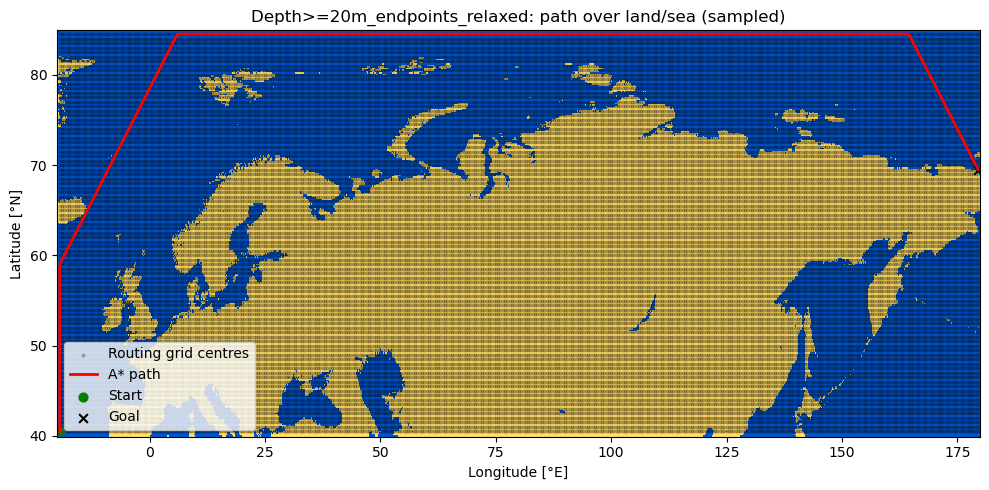

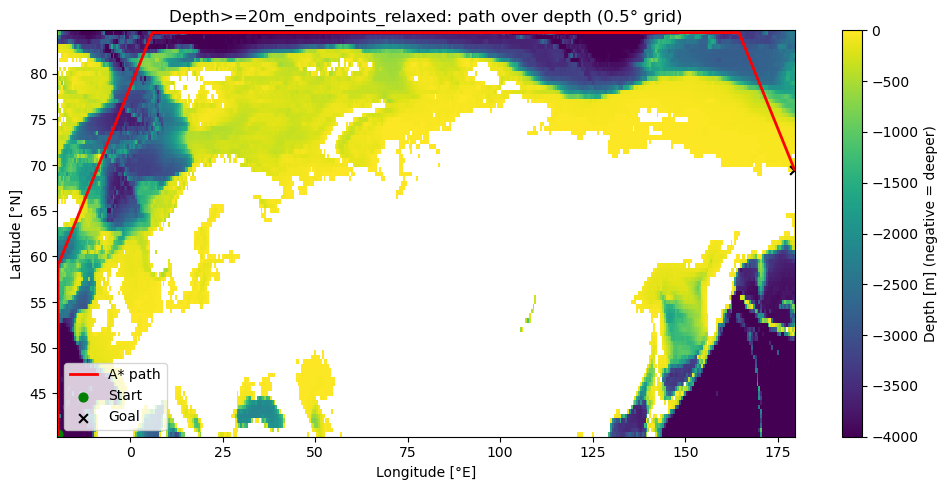

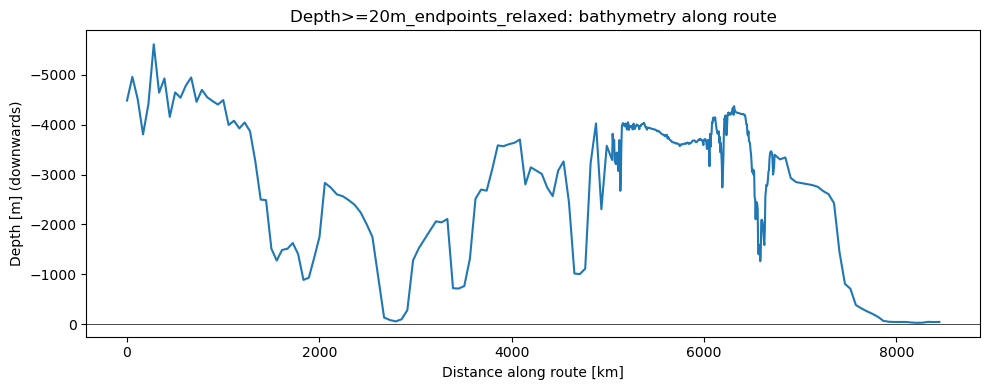

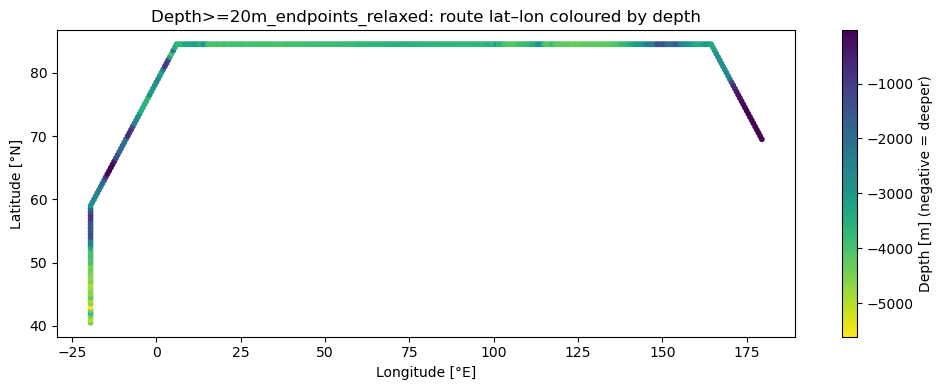

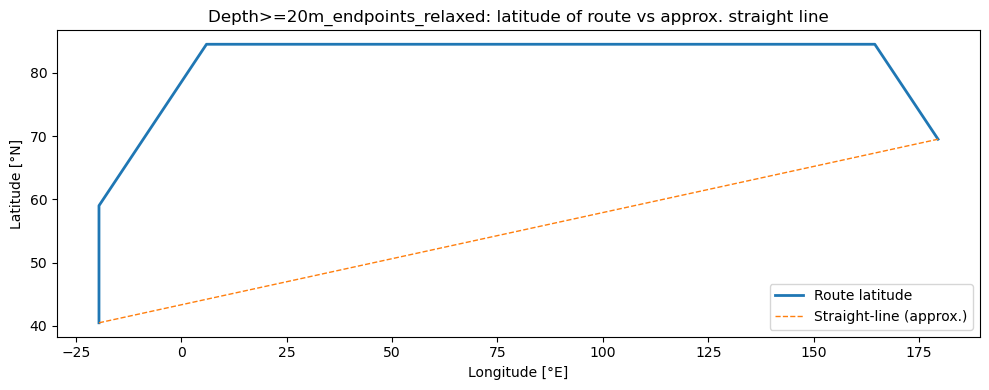


--- Depth constraint (endpoints relaxed): min depth = 50.0 m ---
Original sea fraction:       0.482
Depth-safe sea fraction:     0.408 (84.6% of original sea)
Depth-safe (end-relaxed):    0.408 (84.7% of original sea)
Depth on strictly safe sea cells [m]: min=-8709.0, mean=-1966.5, max=-50.0
Number of depth-safe components (relaxed): 31
Component ID (start, goal) on relaxed mask: 1 23
  Start and goal lie in different depth-safe components (relaxed). No route.

--- Depth constraint (endpoints relaxed): min depth = 200.0 m ---
Original sea fraction:       0.482
Depth-safe sea fraction:     0.319 (66.1% of original sea)
Depth-safe (end-relaxed):    0.319 (66.1% of original sea)
Depth on strictly safe sea cells [m]: min=-8709.0, mean=-2485.3, max=-200.0
Number of depth-safe components (relaxed): 36
Component ID (start, goal) on relaxed mask: 1 20
  Start and goal lie in different depth-safe components (relaxed). No route.

=== END STEP 10b ===


In [30]:
import numpy as np

print("=== STEP 10b: Depth-constrained routing with relaxed endpoints ===")

# Reuse canonical OD from Step 7 / 10:
start_idx = path_idx_test[0]
goal_idx  = path_idx_test[-1]
start_i, start_j = start_idx
goal_i,  goal_j  = goal_idx

print("Canonical OD (from baseline route):")
print("  Start idx:", start_idx, "-> lat,lon =",
      float(lats_rg[start_i]), float(lons_rg[start_j]))
print("  Goal  idx:", goal_idx,  "-> lat,lon =",
      float(lats_rg[goal_i]),  float(lons_rg[goal_j]))

def build_depth_mask(sea_mask, depth_da, min_depth_m):
    depth_vals = depth_da.values
    deep_enough = depth_vals <= -min_depth_m  # e.g. <= -50 means at least 50 m deep
    return sea_mask & deep_enough

# Same thresholds as before
depth_thresholds_m = [20.0, 50.0, 200.0]

for h_min in depth_thresholds_m:
    print(f"\n--- Depth constraint (endpoints relaxed): min depth = {h_min:.1f} m ---")

    # 1) Basic depth-safe mask
    depth_safe_mask = build_depth_mask(sea_mask_rg, depth_rg, h_min)

    # 2) Relax endpoints: allow start & goal cells even if shallower
    depth_safe_relaxed = depth_safe_mask.copy()
    # Ensure start/goal are allowed if they are sea in the original mask
    if sea_mask_rg[start_i, start_j]:
        depth_safe_relaxed[start_i, start_j] = True
    if sea_mask_rg[goal_i, goal_j]:
        depth_safe_relaxed[goal_i, goal_j] = True

    # Basic statistics
    sea_frac_original = sea_mask_rg.mean()
    sea_frac_safe = depth_safe_mask.mean()
    sea_frac_relaxed = depth_safe_relaxed.mean()
    print(f"Original sea fraction:       {sea_frac_original:.3f}")
    print(f"Depth-safe sea fraction:     {sea_frac_safe:.3f} "
          f"({sea_frac_safe/sea_frac_original*100:.1f}% of original sea)")
    print(f"Depth-safe (end-relaxed):    {sea_frac_relaxed:.3f} "
          f"({sea_frac_relaxed/sea_frac_original*100:.1f}% of original sea)")

    depth_vals = depth_rg.values
    depths_safe = depth_vals[depth_safe_mask]
    if depths_safe.size > 0:
        print(f"Depth on strictly safe sea cells [m]: "
              f"min={depths_safe.min():.1f}, "
              f"mean={depths_safe.mean():.1f}, "
              f"max={depths_safe.max():.1f}")
    else:
        print("No strictly depth-safe sea cells at this threshold. Skipping.")
        continue

    # 3) Connectivity on relaxed mask
    labels_relaxed, ncomp_relaxed = label_sea_components(depth_safe_relaxed)
    print("Number of depth-safe components (relaxed):", ncomp_relaxed)

    lab_start = labels_relaxed[start_i, start_j]
    lab_goal  = labels_relaxed[goal_i,  goal_j]
    print("Component ID (start, goal) on relaxed mask:", lab_start, lab_goal)

    if lab_start == 0 or lab_goal == 0:
        print("  Even with relaxed endpoints, start or goal is not in a depth-safe component. No route.")
        continue
    if lab_start != lab_goal:
        print("  Start and goal lie in different depth-safe components (relaxed). No route.")
        continue

    # 4) Run A* on relaxed mask
    try:
        path_idx_depth_relaxed, dist_m_depth_relaxed = astar_distance(
            depth_safe_relaxed,
            lats_rg,
            lons_rg,
            start_idx,
            goal_idx,
            verbose=True
        )
    except RuntimeError as e:
        print("  A* failed on relaxed depth-safe mask:", e)
        continue

    # 5) Summarise
    print("Depth-constrained (end-relaxed) route summary:")
    summarise_route(
        path_idx_depth_relaxed,
        dist_m_depth_relaxed,
        lats_rg,
        lons_rg,
        depth_da=depth_rg
    )

    # 6) For 50 m, plot diagnostics so we see how it differs from baseline
    if abs(h_min - 20.0) < 1e-6:
        print("Generating diagnostics plots for 50 m (end-relaxed) route...")
        plot_route_diagnostics(
            path_idx_depth_relaxed,
            lats_rg,
            lons_rg,
            lat_s,
            lon_s,
            land_mask_s,
            depth_rg,
            land_rg,
            title_prefix="Depth>=20m_endpoints_relaxed"
        )

print("\n=== END STEP 10b ===")

=== STEP 10c: Highlight shallow sea areas with circles ===
Shallow definition: depth > -50.0 m (i.e. |depth| < 50.0 m)
Total sea cells:          17129
Shallow sea cells:        2630
Fraction of sea shallow:  0.154
Depths of shallow cells [m]: min=-49.0, mean=-25.2, max=-1.0
Plotting 2630 shallow points as circles.


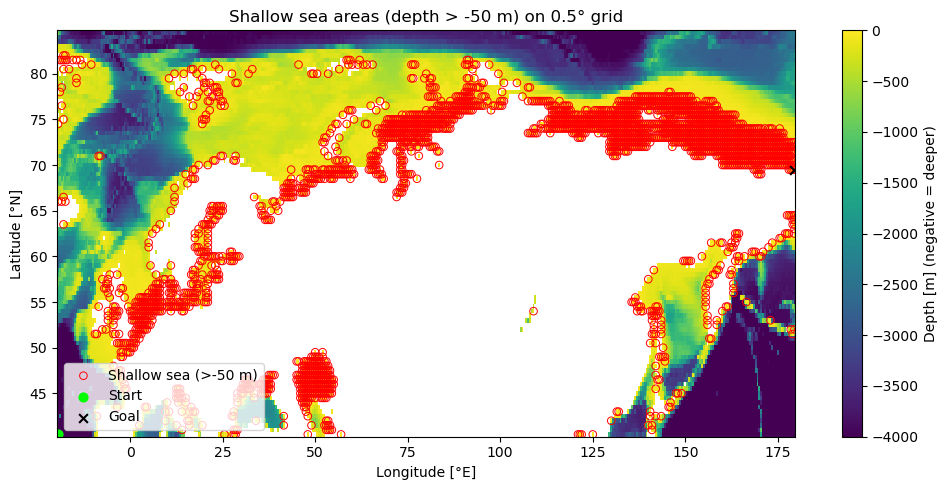

=== END STEP 10c ===


In [31]:
import numpy as np
import matplotlib.pyplot as plt

print("=== STEP 10c: Highlight shallow sea areas with circles ===")

# ---- 1) Choose shallow-depth threshold (in meters) ----
SHALLOW_THRESH_M = 50.0  # e.g. shallower than 50 m

depth_vals = depth_rg.values  # GEBCO elevation (negative = deeper)
# Shallow sea: sea cells with depth between 0 and -SHALLOW_THRESH_M
shallow_mask = sea_mask_rg & (depth_vals > -SHALLOW_THRESH_M)

n_sea = sea_mask_rg.sum()
n_shallow = shallow_mask.sum()

print(f"Shallow definition: depth > -{SHALLOW_THRESH_M:.1f} m (i.e. |depth| < {SHALLOW_THRESH_M:.1f} m)")
print(f"Total sea cells:          {n_sea}")
print(f"Shallow sea cells:        {n_shallow}")
print(f"Fraction of sea shallow:  {n_shallow / n_sea:.3f}")

if n_shallow > 0:
    depths_shallow = depth_vals[shallow_mask]
    print(f"Depths of shallow cells [m]: min={depths_shallow.min():.1f}, "
          f"mean={depths_shallow.mean():.1f}, max={depths_shallow.max():.1f}")

# ---- 2) Prepare coordinates for plotting ----
lon2d, lat2d = np.meshgrid(lons_rg, lats_rg)

# Mask land for background depth plot
depth_plot = depth_vals.copy().astype(float)
depth_plot[land_rg == 1] = np.nan

# Optional: subsample shallow points if there are too many, for readability
max_points = 4000
shallow_indices = np.argwhere(shallow_mask)
if shallow_indices.shape[0] > max_points:
    step = int(np.ceil(shallow_indices.shape[0] / max_points))
    shallow_indices = shallow_indices[::step]
    print(f"Subsampling shallow points for plotting: every {step}-th point (plotting {len(shallow_indices)} circles).")
else:
    print(f"Plotting {len(shallow_indices)} shallow points as circles.")

sh_lat = lats_rg[shallow_indices[:, 0]]
sh_lon = lons_rg[shallow_indices[:, 1]]

# ---- 3) Plot depth background + shallow circles ----
plt.figure(figsize=(10, 5))
im = plt.pcolormesh(
    lons_rg,
    lats_rg,
    depth_plot,
    shading="auto",
    vmin=-4000,
    vmax=0,
    cmap="viridis"
)
cbar = plt.colorbar(im, label="Depth [m] (negative = deeper)")

# Red circles at shallow sea cells
plt.scatter(
    sh_lon,
    sh_lat,
    facecolors="none",
    edgecolors="red",
    linewidths=0.7,
    s=30,
    label=f"Shallow sea (>{-SHALLOW_THRESH_M:.0f} m)"
)

# Mark start & goal of canonical OD for context
start_i, start_j = path_idx_test[0]
goal_i, goal_j = path_idx_test[-1]
plt.scatter(
    [lons_rg[start_j]], [lats_rg[start_i]],
    c="lime", marker="o", s=40, label="Start"
)
plt.scatter(
    [lons_rg[goal_j]], [lats_rg[goal_i]],
    c="black", marker="x", s=40, label="Goal"
)

plt.xlabel("Longitude [°E]")
plt.ylabel("Latitude [°N]")
plt.title(f"Shallow sea areas (depth > {-SHALLOW_THRESH_M:.0f} m) on 0.5° grid")
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()

print("=== END STEP 10c ===")

=== STEP 10c: Highlight shallow sea areas with circles ===
Shallow definition: depth > -200.0 m (i.e. |depth| < 200.0 m)
Total sea cells:          17129
Shallow sea cells:        5801
Fraction of sea shallow:  0.339
Depths of shallow cells [m]: min=-199.0, mean=-73.3, max=-1.0
Subsampling shallow points for plotting: every 2-th point (plotting 2901 circles).


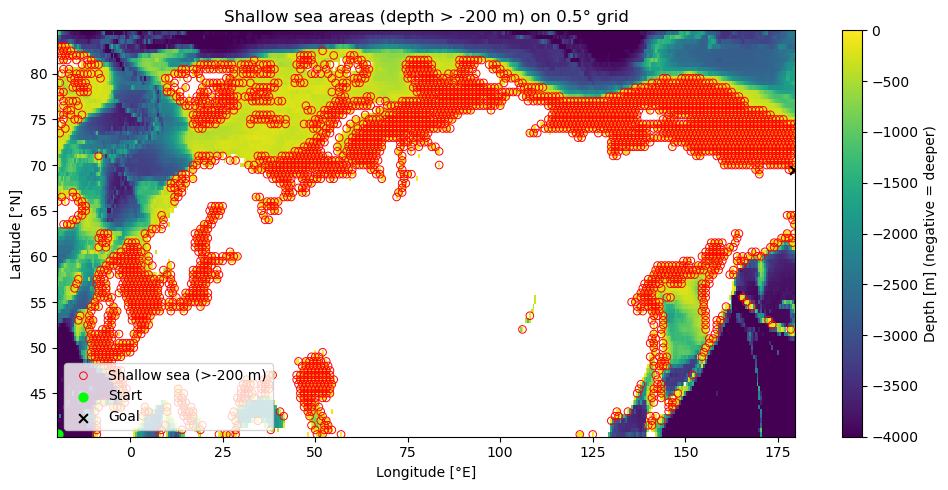

=== END STEP 10c ===


In [32]:
import numpy as np
import matplotlib.pyplot as plt

print("=== STEP 10c: Highlight shallow sea areas with circles ===")

# ---- 1) Choose shallow-depth threshold (in meters) ----
SHALLOW_THRESH_M = 200.0  # e.g. shallower than 50 m

depth_vals = depth_rg.values  # GEBCO elevation (negative = deeper)
# Shallow sea: sea cells with depth between 0 and -SHALLOW_THRESH_M
shallow_mask = sea_mask_rg & (depth_vals > -SHALLOW_THRESH_M)

n_sea = sea_mask_rg.sum()
n_shallow = shallow_mask.sum()

print(f"Shallow definition: depth > -{SHALLOW_THRESH_M:.1f} m (i.e. |depth| < {SHALLOW_THRESH_M:.1f} m)")
print(f"Total sea cells:          {n_sea}")
print(f"Shallow sea cells:        {n_shallow}")
print(f"Fraction of sea shallow:  {n_shallow / n_sea:.3f}")

if n_shallow > 0:
    depths_shallow = depth_vals[shallow_mask]
    print(f"Depths of shallow cells [m]: min={depths_shallow.min():.1f}, "
          f"mean={depths_shallow.mean():.1f}, max={depths_shallow.max():.1f}")

# ---- 2) Prepare coordinates for plotting ----
lon2d, lat2d = np.meshgrid(lons_rg, lats_rg)

# Mask land for background depth plot
depth_plot = depth_vals.copy().astype(float)
depth_plot[land_rg == 1] = np.nan

# Optional: subsample shallow points if there are too many, for readability
max_points = 4000
shallow_indices = np.argwhere(shallow_mask)
if shallow_indices.shape[0] > max_points:
    step = int(np.ceil(shallow_indices.shape[0] / max_points))
    shallow_indices = shallow_indices[::step]
    print(f"Subsampling shallow points for plotting: every {step}-th point (plotting {len(shallow_indices)} circles).")
else:
    print(f"Plotting {len(shallow_indices)} shallow points as circles.")

sh_lat = lats_rg[shallow_indices[:, 0]]
sh_lon = lons_rg[shallow_indices[:, 1]]

# ---- 3) Plot depth background + shallow circles ----
plt.figure(figsize=(10, 5))
im = plt.pcolormesh(
    lons_rg,
    lats_rg,
    depth_plot,
    shading="auto",
    vmin=-4000,
    vmax=0,
    cmap="viridis"
)
cbar = plt.colorbar(im, label="Depth [m] (negative = deeper)")

# Red circles at shallow sea cells
plt.scatter(
    sh_lon,
    sh_lat,
    facecolors="none",
    edgecolors="red",
    linewidths=0.7,
    s=30,
    label=f"Shallow sea (>{-SHALLOW_THRESH_M:.0f} m)"
)

# Mark start & goal of canonical OD for context
start_i, start_j = path_idx_test[0]
goal_i, goal_j = path_idx_test[-1]
plt.scatter(
    [lons_rg[start_j]], [lats_rg[start_i]],
    c="lime", marker="o", s=40, label="Start"
)
plt.scatter(
    [lons_rg[goal_j]], [lats_rg[goal_i]],
    c="black", marker="x", s=40, label="Goal"
)

plt.xlabel("Longitude [°E]")
plt.ylabel("Latitude [°N]")
plt.title(f"Shallow sea areas (depth > {-SHALLOW_THRESH_M:.0f} m) on 0.5° grid")
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()

print("=== END STEP 10c ===")

=== STEP 10c: Highlight shallow sea areas with circles ===
Shallow definition: depth > -0.0 m (i.e. |depth| < 0.0 m)
Total sea cells:          17129
Shallow sea cells:        0
Fraction of sea shallow:  0.000
Plotting 0 shallow points as circles.


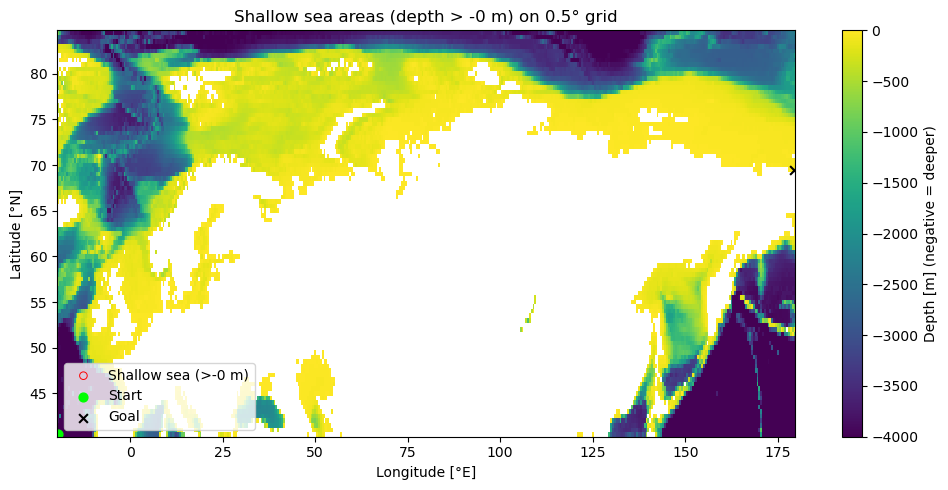

=== END STEP 10c ===


In [33]:
import numpy as np
import matplotlib.pyplot as plt

print("=== STEP 10c: Highlight shallow sea areas with circles ===")

# ---- 1) Choose shallow-depth threshold (in meters) ----
SHALLOW_THRESH_M = 0.0  # e.g. shallower than 50 m

depth_vals = depth_rg.values  # GEBCO elevation (negative = deeper)
# Shallow sea: sea cells with depth between 0 and -SHALLOW_THRESH_M
shallow_mask = sea_mask_rg & (depth_vals > -SHALLOW_THRESH_M)

n_sea = sea_mask_rg.sum()
n_shallow = shallow_mask.sum()

print(f"Shallow definition: depth > -{SHALLOW_THRESH_M:.1f} m (i.e. |depth| < {SHALLOW_THRESH_M:.1f} m)")
print(f"Total sea cells:          {n_sea}")
print(f"Shallow sea cells:        {n_shallow}")
print(f"Fraction of sea shallow:  {n_shallow / n_sea:.3f}")

if n_shallow > 0:
    depths_shallow = depth_vals[shallow_mask]
    print(f"Depths of shallow cells [m]: min={depths_shallow.min():.1f}, "
          f"mean={depths_shallow.mean():.1f}, max={depths_shallow.max():.1f}")

# ---- 2) Prepare coordinates for plotting ----
lon2d, lat2d = np.meshgrid(lons_rg, lats_rg)

# Mask land for background depth plot
depth_plot = depth_vals.copy().astype(float)
depth_plot[land_rg == 1] = np.nan

# Optional: subsample shallow points if there are too many, for readability
max_points = 4000
shallow_indices = np.argwhere(shallow_mask)
if shallow_indices.shape[0] > max_points:
    step = int(np.ceil(shallow_indices.shape[0] / max_points))
    shallow_indices = shallow_indices[::step]
    print(f"Subsampling shallow points for plotting: every {step}-th point (plotting {len(shallow_indices)} circles).")
else:
    print(f"Plotting {len(shallow_indices)} shallow points as circles.")

sh_lat = lats_rg[shallow_indices[:, 0]]
sh_lon = lons_rg[shallow_indices[:, 1]]

# ---- 3) Plot depth background + shallow circles ----
plt.figure(figsize=(10, 5))
im = plt.pcolormesh(
    lons_rg,
    lats_rg,
    depth_plot,
    shading="auto",
    vmin=-4000,
    vmax=0,
    cmap="viridis"
)
cbar = plt.colorbar(im, label="Depth [m] (negative = deeper)")

# Red circles at shallow sea cells
plt.scatter(
    sh_lon,
    sh_lat,
    facecolors="none",
    edgecolors="red",
    linewidths=0.7,
    s=30,
    label=f"Shallow sea (>{-SHALLOW_THRESH_M:.0f} m)"
)

# Mark start & goal of canonical OD for context
start_i, start_j = path_idx_test[0]
goal_i, goal_j = path_idx_test[-1]
plt.scatter(
    [lons_rg[start_j]], [lats_rg[start_i]],
    c="lime", marker="o", s=40, label="Start"
)
plt.scatter(
    [lons_rg[goal_j]], [lats_rg[goal_i]],
    c="black", marker="x", s=40, label="Goal"
)

plt.xlabel("Longitude [°E]")
plt.ylabel("Latitude [°N]")
plt.title(f"Shallow sea areas (depth > {-SHALLOW_THRESH_M:.0f} m) on 0.5° grid")
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()

print("=== END STEP 10c ===")

=== STEP 10c: Highlight shallow sea areas with circles ===
Shallow definition: depth > -500.0 m (i.e. |depth| < 500.0 m)
Total sea cells:          17129
Shallow sea cells:        8169
Fraction of sea shallow:  0.477
Depths of shallow cells [m]: min=-499.0, mean=-140.5, max=-1.0
Subsampling shallow points for plotting: every 3-th point (plotting 2723 circles).


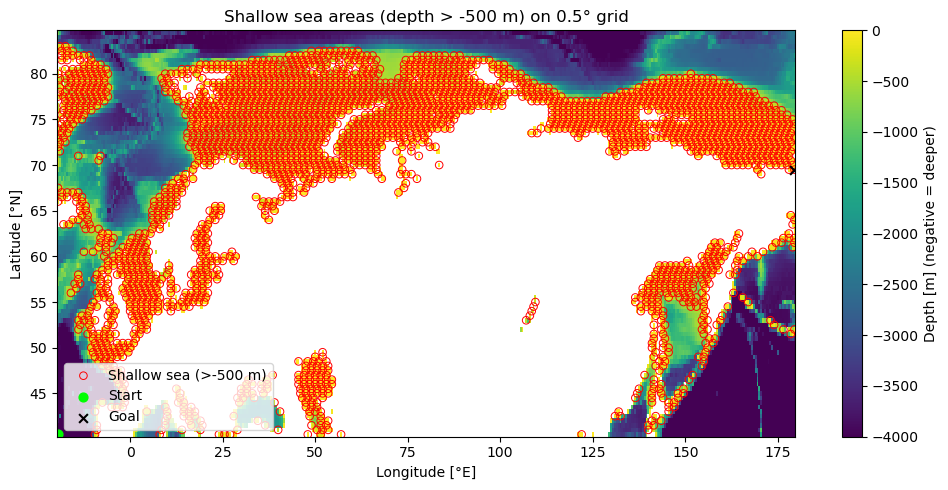

=== END STEP 10c ===


In [34]:
import numpy as np
import matplotlib.pyplot as plt

print("=== STEP 10c: Highlight shallow sea areas with circles ===")

# ---- 1) Choose shallow-depth threshold (in meters) ----
SHALLOW_THRESH_M = 500.0  # e.g. shallower than 50 m

depth_vals = depth_rg.values  # GEBCO elevation (negative = deeper)
# Shallow sea: sea cells with depth between 0 and -SHALLOW_THRESH_M
shallow_mask = sea_mask_rg & (depth_vals > -SHALLOW_THRESH_M)

n_sea = sea_mask_rg.sum()
n_shallow = shallow_mask.sum()

print(f"Shallow definition: depth > -{SHALLOW_THRESH_M:.1f} m (i.e. |depth| < {SHALLOW_THRESH_M:.1f} m)")
print(f"Total sea cells:          {n_sea}")
print(f"Shallow sea cells:        {n_shallow}")
print(f"Fraction of sea shallow:  {n_shallow / n_sea:.3f}")

if n_shallow > 0:
    depths_shallow = depth_vals[shallow_mask]
    print(f"Depths of shallow cells [m]: min={depths_shallow.min():.1f}, "
          f"mean={depths_shallow.mean():.1f}, max={depths_shallow.max():.1f}")

# ---- 2) Prepare coordinates for plotting ----
lon2d, lat2d = np.meshgrid(lons_rg, lats_rg)

# Mask land for background depth plot
depth_plot = depth_vals.copy().astype(float)
depth_plot[land_rg == 1] = np.nan

# Optional: subsample shallow points if there are too many, for readability
max_points = 4000
shallow_indices = np.argwhere(shallow_mask)
if shallow_indices.shape[0] > max_points:
    step = int(np.ceil(shallow_indices.shape[0] / max_points))
    shallow_indices = shallow_indices[::step]
    print(f"Subsampling shallow points for plotting: every {step}-th point (plotting {len(shallow_indices)} circles).")
else:
    print(f"Plotting {len(shallow_indices)} shallow points as circles.")

sh_lat = lats_rg[shallow_indices[:, 0]]
sh_lon = lons_rg[shallow_indices[:, 1]]

# ---- 3) Plot depth background + shallow circles ----
plt.figure(figsize=(10, 5))
im = plt.pcolormesh(
    lons_rg,
    lats_rg,
    depth_plot,
    shading="auto",
    vmin=-4000,
    vmax=0,
    cmap="viridis"
)
cbar = plt.colorbar(im, label="Depth [m] (negative = deeper)")

# Red circles at shallow sea cells
plt.scatter(
    sh_lon,
    sh_lat,
    facecolors="none",
    edgecolors="red",
    linewidths=0.7,
    s=30,
    label=f"Shallow sea (>{-SHALLOW_THRESH_M:.0f} m)"
)

# Mark start & goal of canonical OD for context
start_i, start_j = path_idx_test[0]
goal_i, goal_j = path_idx_test[-1]
plt.scatter(
    [lons_rg[start_j]], [lats_rg[start_i]],
    c="lime", marker="o", s=40, label="Start"
)
plt.scatter(
    [lons_rg[goal_j]], [lats_rg[goal_i]],
    c="black", marker="x", s=40, label="Goal"
)

plt.xlabel("Longitude [°E]")
plt.ylabel("Latitude [°N]")
plt.title(f"Shallow sea areas (depth > {-SHALLOW_THRESH_M:.0f} m) on 0.5° grid")
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()

print("=== END STEP 10c ===")

In [50]:
import numpy as np
import matplotlib.pyplot as plt

def plot_route_diagnostics(
    path_idx,
    lats_rg,
    lons_rg,
    lat_s,
    lon_s,
    land_mask_s,
    depth_da,
    land_rg,
    title_prefix="",
    shallow_thresh_m=None,
):
    """
    Plot a set of diagnostic figures for a given route on the routing grid.

    Parameters
    ----------
    path_idx : list of (i,j)
        Sequence of grid indices along the route.
    lats_rg, lons_rg : 1D arrays
        Routing grid latitudes and longitudes.
    lat_s, lon_s : 2D arrays
        Sampled (high-res) lat/lon for background land/sea plots.
    land_mask_s : 2D bool/int array
        Sampled land mask (1=land, 0=sea) for background.
    depth_da : xarray.DataArray
        Bathymetry/elevation on routing grid (lat, lon), negative = deeper.
    land_rg : 2D bool/int array
        Land mask on routing grid (1=land, 0=sea).
    title_prefix : str
        Optional prefix for figure titles.
    shallow_thresh_m : float or None
        If not None, additionally plot shallow sea cells with depth > -shallow_thresh_m
        as red circles on a separate figure.
    """

    depth_vals = depth_da.values
    lon2d, lat2d = np.meshgrid(lons_rg, lats_rg)

    # Extract route coordinates and depths
    path_idx_arr = np.array(path_idx)
    pi = path_idx_arr[:, 0]
    pj = path_idx_arr[:, 1]
    path_lats = lats_rg[pi]
    path_lons = lons_rg[pj]
    path_depths = depth_vals[pi, pj]

    # ---------- FIG 1: Route over depth on routing grid ----------
    depth_plot = depth_vals.copy().astype(float)
    depth_plot[land_rg == 1] = np.nan

    plt.figure(figsize=(10, 5))
    im = plt.pcolormesh(
        lons_rg,
        lats_rg,
        depth_plot,
        shading="auto",
        vmin=-4000,
        vmax=0,
        cmap="viridis",
    )
    plt.colorbar(im, label="Depth [m] (negative = deeper)")

    plt.plot(path_lons, path_lats, "r-", lw=2, label="A* path")
    plt.scatter(path_lons[0], path_lats[0], c="lime", marker="o", s=40, label="Start")
    plt.scatter(path_lons[-1], path_lats[-1], c="black", marker="x", s=40, label="Goal")

    plt.xlabel("Longitude [°E]")
    plt.ylabel("Latitude [°N]")
    plt.title(f"{title_prefix}: path over depth (0.5° grid)")
    plt.legend(loc="lower left")
    plt.tight_layout()
    plt.show()

    # ---------- FIG 2: Route over sampled land/sea with routing grid ----------
    plt.figure(figsize=(10, 5))
    plt.pcolormesh(
        lon_s,
        lat_s,
        land_mask_s,
        shading="auto",
        cmap="cividis",
        vmin=0,
        vmax=1,
    )
    plt.scatter(lon2d, lat2d, c="k", s=1, alpha=0.2, label="Routing grid centres")
    plt.plot(path_lons, path_lats, "r-", lw=2, label="A* path")
    plt.scatter(path_lons[0], path_lats[0], c="lime", marker="o", s=40, label="Start")
    plt.scatter(path_lons[-1], path_lats[-1], c="black", marker="x", s=40, label="Goal")

    plt.xlabel("Longitude [°E]")
    plt.ylabel("Latitude [°N]")
    plt.title(f"{title_prefix}: route over land/sea")
    plt.legend(loc="lower left")
    plt.tight_layout()
    plt.show()

    # ---------- FIG 3: Bathymetry along the route ----------
    # Compute along-track distances (approx)
    def haversine(lat1, lon1, lat2, lon2):
        R = 6371.0e3
        phi1 = np.radians(lat1)
        phi2 = np.radians(lat2)
        dphi = np.radians(lat2 - lat1)
        dlambda = np.radians(lon2 - lon1)
        a = np.sin(dphi / 2) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2) ** 2
        return 2 * R * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    dists = [0.0]
    for k in range(1, len(path_lats)):
        d = haversine(path_lats[k - 1], path_lons[k - 1], path_lats[k], path_lons[k])
        dists.append(d)
    dists = np.cumsum(dists) / 1000.0  # km

    plt.figure(figsize=(10, 4))
    plt.plot(dists, path_depths)
    plt.gca().invert_yaxis()
    plt.xlabel("Distance along route [km]")
    plt.ylabel("Depth [m] (downwards)")
    plt.title(f"{title_prefix}: Bathymetry along route")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # ---------- FIG 4: Route in lat–lon coloured by depth ----------
    plt.figure(figsize=(10, 4))
    sc = plt.scatter(
        path_lons,
        path_lats,
        c=path_depths,
        cmap="viridis",
        vmin=-4000,
        vmax=0,
        s=30,
    )
    plt.colorbar(sc, label="Depth [m] (negative = deeper)")
    plt.xlabel("Longitude [°E]")
    plt.ylabel("Latitude [°N]")
    plt.title(f"{title_prefix}: route in lat-lon coloured by depth")
    plt.tight_layout()
    plt.show()

    # ---------- FIG 5: Latitude vs approximate straight line ----------
    plt.figure(figsize=(10, 4))
    plt.plot(path_lons, path_lats, label="Route latitude")

    lon_line = np.linspace(path_lons[0], path_lons[-1], 100)
    lat_line = np.linspace(path_lats[0], path_lats[-1], 100)
    plt.plot(lon_line, lat_line, "k--", label="Straight-line (approx.)")

    plt.xlabel("Longitude [°E]")
    plt.ylabel("Latitude [°N]")
    plt.title(f"{title_prefix}: Latitude of route vs straight line")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ---------- OPTIONAL FIG 6: Shallow areas with circles ----------
    if shallow_thresh_m is not None:
        print(
            f"Plotting shallow sea cells: depth > -{shallow_thresh_m:.1f} m "
            f"(i.e. |depth| < {shallow_thresh_m:.1f} m)"
        )
        shallow_mask = (land_rg == 0) & (depth_vals > -shallow_thresh_m)
        n_sea = (land_rg == 0).sum()
        n_shallow = shallow_mask.sum()
        print(f"  Total sea cells:         {n_sea}")
        print(f"  Shallow sea cells:       {n_shallow}")
        if n_sea > 0:
            print(f"  Fraction of sea shallow: {n_shallow / n_sea:.3f}")

        shallow_indices = np.argwhere(shallow_mask)
        max_points = 4000
        if shallow_indices.shape[0] > max_points:
            step = int(np.ceil(shallow_indices.shape[0] / max_points))
            shallow_indices = shallow_indices[::step]
            print(
                f"  Subsampling shallow points: every {step}-th "
                f"(plotting {len(shallow_indices)} circles)."
            )
        else:
            print(f"  Plotting {len(shallow_indices)} shallow points as circles.")

        sh_lat = lats_rg[shallow_indices[:, 0]]
        sh_lon = lons_rg[shallow_indices[:, 1]]

        depth_plot2 = depth_vals.copy().astype(float)
        depth_plot2[land_rg == 1] = np.nan

        plt.figure(figsize=(10, 5))
        im2 = plt.pcolormesh(
            lons_rg,
            lats_rg,
            depth_plot2,
            shading="auto",
            vmin=-4000,
            vmax=0,
            cmap="viridis",
        )
        plt.colorbar(im2, label="Depth [m] (negative = deeper)")

        # shallow circles
        plt.scatter(
            sh_lon,
            sh_lat,
            facecolors="none",
            edgecolors="red",
            linewidths=0.7,
            s=30,
            label=f"Shallow sea (>{-shallow_thresh_m:.0f} m)",
        )

        # route and endpoints for context
        plt.plot(path_lons, path_lats, "w-", lw=1.5, alpha=0.8, label="Route")
        plt.scatter(
            path_lons[0],
            path_lats[0],
            c="lime",
            marker="o",
            s=40,
            label="Start",
        )
        plt.scatter(
            path_lons[-1],
            path_lats[-1],
            c="black",
            marker="x",
            s=40,
            label="Goal",
        )

        plt.xlabel("Longitude [°E]")
        plt.ylabel("Latitude [°N]")
        plt.title(
            f"{title_prefix}: Shallow sea areas (depth > {-shallow_thresh_m:.0f} m)"
        )
        plt.legend(loc="lower left")
        plt.tight_layout()
        plt.savefig("figA2_shallow_sea_50m.png",
        dpi=300, bbox_inches="tight")
        plt.show()

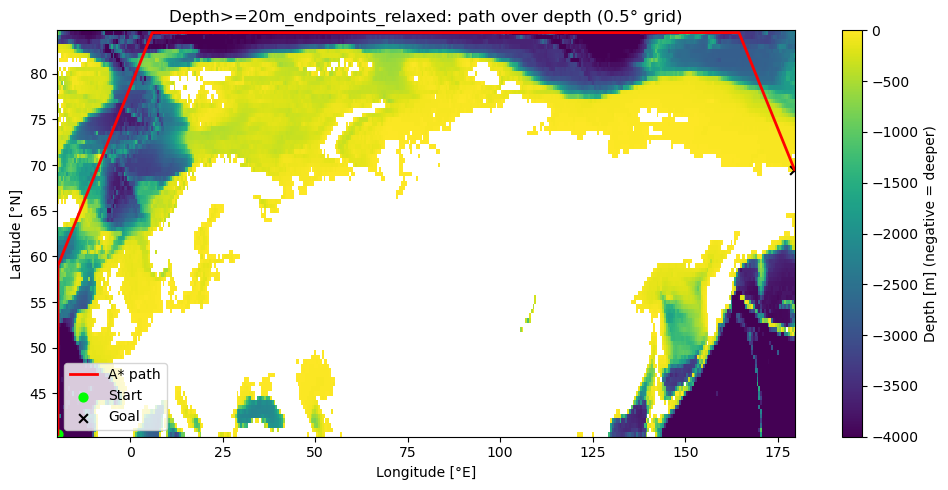

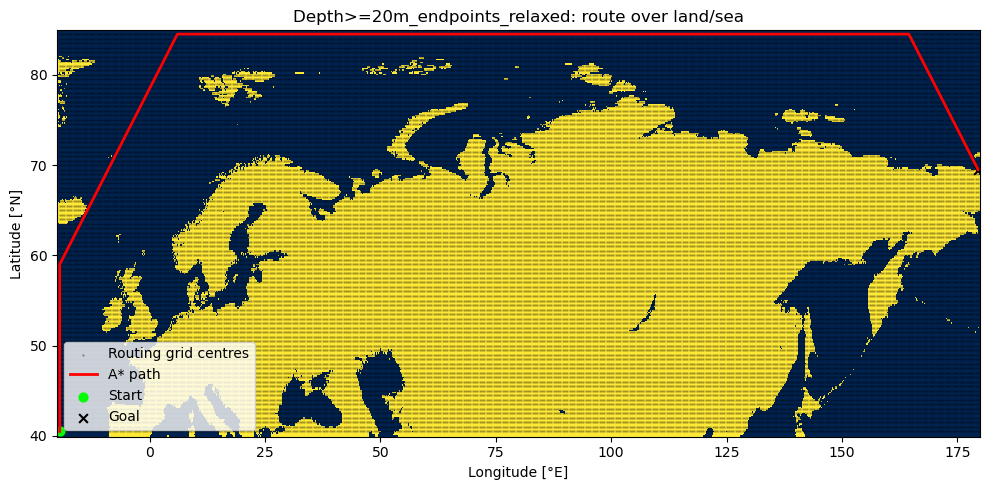

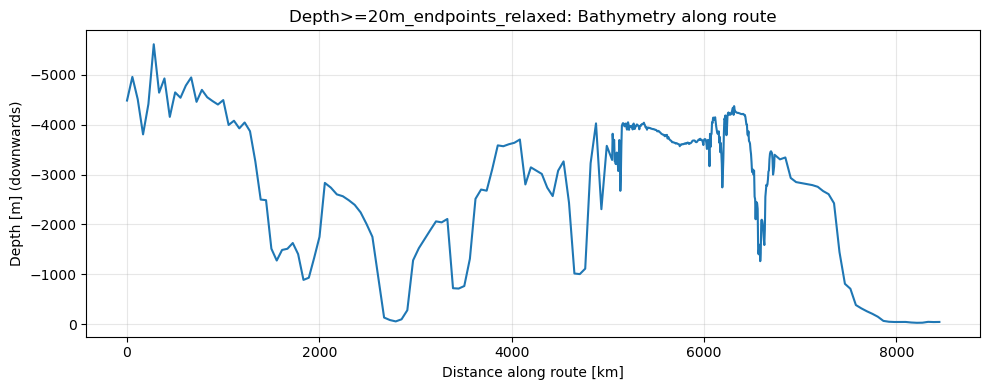

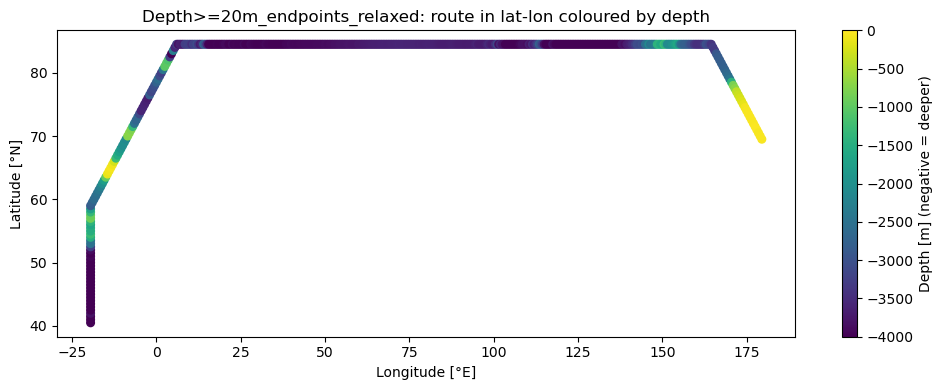

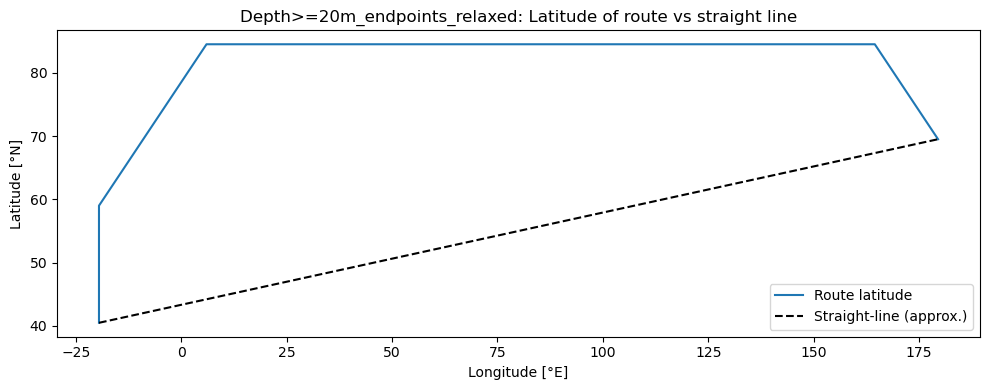

Plotting shallow sea cells: depth > -50.0 m (i.e. |depth| < 50.0 m)
  Total sea cells:         17129
  Shallow sea cells:       2630
  Fraction of sea shallow: 0.154
  Plotting 2630 shallow points as circles.


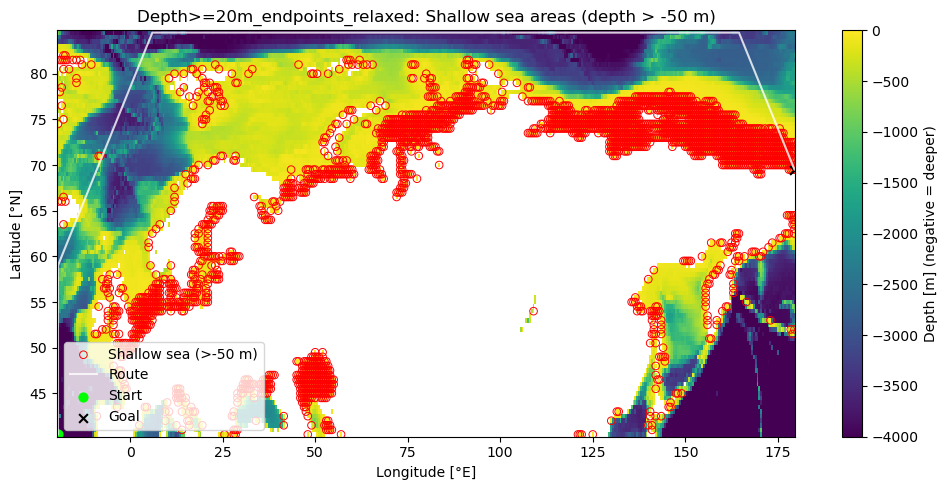

In [51]:
plot_route_diagnostics(
    path_idx_test,
    lats_rg,
    lons_rg,
    lat_s,
    lon_s,
    land_mask_s,
    depth_rg,
    land_rg,
    title_prefix="Depth>=20m_endpoints_relaxed",
    shallow_thresh_m=50.0,  # highlight shelves shallower than 50 m
)

# Step 11

In [36]:
import numpy as np
import matplotlib.pyplot as plt

def plot_route_diagnostics(
    path_idx,
    lats_rg,
    lons_rg,
    lat_s,
    lon_s,
    land_mask_s,
    depth_da,
    land_rg,
    title_prefix="",
    shallow_thresh_m=None,
    contour_levels=None,
    show_depth_histogram=True,
    depth_thresholds_for_connectivity=None,
    sea_mask_rg=None,
):
    """
    Plot a set of diagnostic figures for a given route on the routing grid.

    Parameters
    ----------
    path_idx : list[(i,j)]
        Sequence of grid indices along the route.
    lats_rg, lons_rg : 1D arrays
        Routing grid latitudes and longitudes.
    lat_s, lon_s : 2D arrays
        Sampled (high-res) lat/lon for background land/sea plots.
    land_mask_s : 2D array
        Sampled land mask (1=land, 0=sea) for background.
    depth_da : xarray.DataArray
        Bathymetry/elevation on routing grid (lat, lon), negative = deeper.
    land_rg : 2D array
        Land mask on routing grid (1=land, 0=sea).
    title_prefix : str
        Optional prefix for figure titles.
    shallow_thresh_m : float or None
        If not None, extra figure highlights shallow sea cells
        with depth > -shallow_thresh_m as red circles.
    contour_levels : list[float] or None
        If not None, overlay isobath contours (e.g. [-50, -200, -1000]) on the
        depth map figure.
    show_depth_histogram : bool
        If True, plot depth histogram: corridor sea vs along-route.
    depth_thresholds_for_connectivity : list[float] or None
        If provided, create a connectivity figure across these depth thresholds
        (in meters), using sea_mask_rg and global label_sea_components.
    sea_mask_rg : 2D bool/array or None
        Sea mask (True/1 = sea, False/0 = land) on routing grid.
        Needed only if depth_thresholds_for_connectivity is not None.
    """

    depth_vals = depth_da.values
    lon2d, lat2d = np.meshgrid(lons_rg, lats_rg)

    # Route indices & values
    path_idx_arr = np.array(path_idx)
    pi = path_idx_arr[:, 0]
    pj = path_idx_arr[:, 1]
    path_lats = lats_rg[pi]
    path_lons = lons_rg[pj]
    path_depths = depth_vals[pi, pj]

    # ---------- Helper for along-track distances ----------
    def haversine(lat1, lon1, lat2, lon2):
        R = 6371.0e3
        phi1 = np.radians(lat1)
        phi2 = np.radians(lat2)
        dphi = np.radians(lat2 - lat1)
        dlambda = np.radians(lon2 - lon1)
        a = np.sin(dphi / 2) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2) ** 2
        return 2 * R * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    dists = [0.0]
    for k in range(1, len(path_lats)):
        d = haversine(path_lats[k - 1], path_lons[k - 1], path_lats[k], path_lons[k])
        dists.append(d)
    dists = np.cumsum(dists) / 1000.0  # km

    # =====================================================
    # FIG 1: Route over depth (with optional contours)
    # =====================================================
    depth_plot = depth_vals.copy().astype(float)
    depth_plot[land_rg == 1] = np.nan

    plt.figure(figsize=(10, 5))
    im = plt.pcolormesh(
        lons_rg,
        lats_rg,
        depth_plot,
        shading="auto",
        vmin=-4000,
        vmax=0,
        cmap="viridis",
    )
    plt.colorbar(im, label="Depth [m] (negative = deeper)")

    # optional contours
    if contour_levels is not None:
        # ensure levels are strictly increasing as required by matplotlib
        levels_sorted = np.sort(np.array(contour_levels, dtype=float))
        cs = plt.contour(
            lons_rg,
            lats_rg,
            depth_plot,
            levels=levels_sorted,
            colors="black",
            linewidths=0.7,
            alpha=0.8,
        )
        plt.clabel(cs, inline=True, fontsize=7, fmt="%.0f")

    plt.plot(path_lons, path_lats, "r-", lw=2, label="A* path")
    plt.scatter(path_lons[0], path_lats[0], c="lime", marker="o", s=40, label="Start")
    plt.scatter(path_lons[-1], path_lats[-1], c="black", marker="x", s=40, label="Goal")

    plt.xlabel("Longitude [°E]")
    plt.ylabel("Latitude [°N]")
    plt.title(f"{title_prefix}: path over depth (0.5° grid)")
    plt.legend(loc="lower left")
    plt.tight_layout()
    plt.show()

    # =====================================================
    # FIG 2: Route over sampled land/sea + routing grid
    # =====================================================
    plt.figure(figsize=(10, 5))
    plt.pcolormesh(
        lon_s,
        lat_s,
        land_mask_s,
        shading="auto",
        cmap="cividis",
        vmin=0,
        vmax=1,
    )
    plt.scatter(lon2d, lat2d, c="k", s=1, alpha=0.2, label="Routing grid centres")
    plt.plot(path_lons, path_lats, "r-", lw=2, label="A* path")
    plt.scatter(path_lons[0], path_lats[0], c="lime", marker="o", s=40, label="Start")
    plt.scatter(path_lons[-1], path_lats[-1], c="black", marker="x", s=40, label="Goal")

    plt.xlabel("Longitude [°E]")
    plt.ylabel("Latitude [°N]")
    plt.title(f"{title_prefix}: route over land/sea")
    plt.legend(loc="lower left")
    plt.tight_layout()
    plt.show()

    # =====================================================
    # FIG 3: Bathymetry along the route (depth vs distance)
    # =====================================================
    plt.figure(figsize=(10, 4))
    plt.plot(dists, path_depths)
    plt.gca().invert_yaxis()
    plt.xlabel("Distance along route [km]")
    plt.ylabel("Depth [m] (downwards)")
    plt.title(f"{title_prefix}: Bathymetry along route")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # =====================================================
    # FIG 4: Route in lat–lon coloured by depth
    # =====================================================
    plt.figure(figsize=(10, 4))
    sc = plt.scatter(
        path_lons,
        path_lats,
        c=path_depths,
        cmap="viridis",
        vmin=-4000,
        vmax=0,
        s=30,
    )
    plt.colorbar(sc, label="Depth [m] (negative = deeper)")
    plt.xlabel("Longitude [°E]")
    plt.ylabel("Latitude [°N]")
    plt.title(f"{title_prefix}: route in lat-lon coloured by depth")
    plt.tight_layout()
    plt.show()

    # =====================================================
    # FIG 5: Latitude vs approximate straight line
    # =====================================================
    plt.figure(figsize=(10, 4))
    plt.plot(path_lons, path_lats, label="Route latitude")

    lon_line = np.linspace(path_lons[0], path_lons[-1], 100)
    lat_line = np.linspace(path_lats[0], path_lats[-1], 100)
    plt.plot(lon_line, lat_line, "k--", label="Straight-line (approx.)")

    plt.xlabel("Longitude [°E]")
    plt.ylabel("Latitude [°N]")
    plt.title(f"{title_prefix}: Latitude of route vs straight line")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # =====================================================
    # FIG 6: OPTIONAL shallow areas with circles
    # =====================================================
    if shallow_thresh_m is not None:
        print(
            f"Plotting shallow sea cells: depth > -{shallow_thresh_m:.1f} m "
            f"(i.e. |depth| < {shallow_thresh_m:.1f} m)"
        )
        shallow_mask = (land_rg == 0) & (depth_vals > -shallow_thresh_m)
        n_sea = (land_rg == 0).sum()
        n_shallow = shallow_mask.sum()
        if n_sea > 0:
            print(f"  Total sea cells:         {n_sea}")
            print(f"  Shallow sea cells:       {n_shallow}")
            print(f"  Fraction of sea shallow: {n_shallow / n_sea:.3f}")

        shallow_indices = np.argwhere(shallow_mask)
        max_points = 4000
        if shallow_indices.shape[0] > max_points:
            step = int(np.ceil(shallow_indices.shape[0] / max_points))
            shallow_indices = shallow_indices[::step]
            print(
                f"  Subsampling shallow points: every {step}-th "
                f"(plotting {len(shallow_indices)} circles)."
            )
        else:
            print(f"  Plotting {len(shallow_indices)} shallow points as circles.")

        sh_lat = lats_rg[shallow_indices[:, 0]]
        sh_lon = lons_rg[shallow_indices[:, 1]]

        depth_plot2 = depth_vals.copy().astype(float)
        depth_plot2[land_rg == 1] = np.nan

        plt.figure(figsize=(10, 5))
        im2 = plt.pcolormesh(
            lons_rg,
            lats_rg,
            depth_plot2,
            shading="auto",
            vmin=-4000,
            vmax=0,
            cmap="viridis",
        )
        plt.colorbar(im2, label="Depth [m] (negative = deeper)")

        plt.scatter(
            sh_lon,
            sh_lat,
            facecolors="none",
            edgecolors="red",
            linewidths=0.7,
            s=30,
            label=f"Shallow sea (>{-shallow_thresh_m:.0f} m)",
        )

        plt.plot(path_lons, path_lats, "w-", lw=1.5, alpha=0.8, label="Route")
        plt.scatter(
            path_lons[0],
            path_lats[0],
            c="lime",
            marker="o",
            s=40,
            label="Start",
        )
        plt.scatter(
            path_lons[-1],
            path_lats[-1],
            c="black",
            marker="x",
            s=40,
            label="Goal",
        )

        plt.xlabel("Longitude [°E]")
        plt.ylabel("Latitude [°N]")
        plt.title(
            f"{title_prefix}: Shallow sea areas (depth > {-shallow_thresh_m:.0f} m)"
        )
        plt.legend(loc="lower left")
        plt.tight_layout()
        plt.show()

    # =====================================================
    # FIG 7: OPTIONAL depth histogram (corridor vs route)
    # =====================================================
    if show_depth_histogram:
        sea_mask = (land_rg == 0)
        depths_corridor = depth_vals[sea_mask]

        plt.figure(figsize=(8, 4))
        bins = 40
        plt.hist(
            depths_corridor,
            bins=bins,
            alpha=0.5,
            label="All sea cells in corridor",
        )
        plt.hist(
            path_depths,
            bins=bins,
            alpha=0.7,
            label="Cells along route",
        )
        plt.gca().invert_xaxis()  # more negative (deeper) on left if you like
        plt.xlabel("Depth [m] (negative = deeper)")
        plt.ylabel("Count")
        plt.title(f"{title_prefix}: Depth distribution (corridor vs route)")
        plt.legend()
        plt.tight_layout()
        plt.show()

    # =====================================================
    # FIG 8: OPTIONAL depth-threshold connectivity curve
    # =====================================================
    if depth_thresholds_for_connectivity is not None and sea_mask_rg is not None:
        from copy import deepcopy

        thresholds = np.array(depth_thresholds_for_connectivity, dtype=float)

        frac_safe = []
        n_components = []
        connected = []

        start_i, start_j = pi[0], pj[0]
        goal_i, goal_j = pi[-1], pj[-1]

        for h_min in thresholds:
            depth_safe_mask = (sea_mask_rg.astype(bool) &
                               (depth_vals <= -h_min))
            frac_safe.append(depth_safe_mask.mean())

            labels_h, ncomp_h = label_sea_components(depth_safe_mask)
            n_components.append(ncomp_h)

            lab_s = labels_h[start_i, start_j]
            lab_g = labels_h[goal_i,  goal_j]
            conn = (lab_s != 0) and (lab_g != 0) and (lab_s == lab_g)
            connected.append(conn)

        frac_safe = np.array(frac_safe)
        n_components = np.array(n_components)
        connected = np.array(connected)

        plt.figure(figsize=(10, 4))

        ax1 = plt.gca()
        ax2 = ax1.twinx()

        ax1.plot(
            thresholds,
            frac_safe,
            "o-",
            label="Fraction of sea cells depth-safe",
        )
        ax1.set_xlabel("Minimum depth threshold [m]")
        ax1.set_ylabel("Sea fraction (depth <= -h)", color="C0")
        ax1.tick_params(axis="y", labelcolor="C0")

        ax2.plot(
            thresholds,
            n_components,
            "s--",
            color="C1",
            label="Number of depth-safe components",
        )
        ax2.set_ylabel("Number of components", color="C1")
        ax2.tick_params(axis="y", labelcolor="C1")

        # Mark connectivity
        for h, conn in zip(thresholds, connected):
            ax1.scatter(
                h,
                0.0,
                c="green" if conn else "red",
                marker="o" if conn else "x",
                s=40,
                zorder=5,
            )

        plt.title(
            f"{title_prefix}: Depth-threshold connectivity "
            "(green=connected, red=disconnected at bottom axis)"
        )
        plt.tight_layout()
        plt.show()

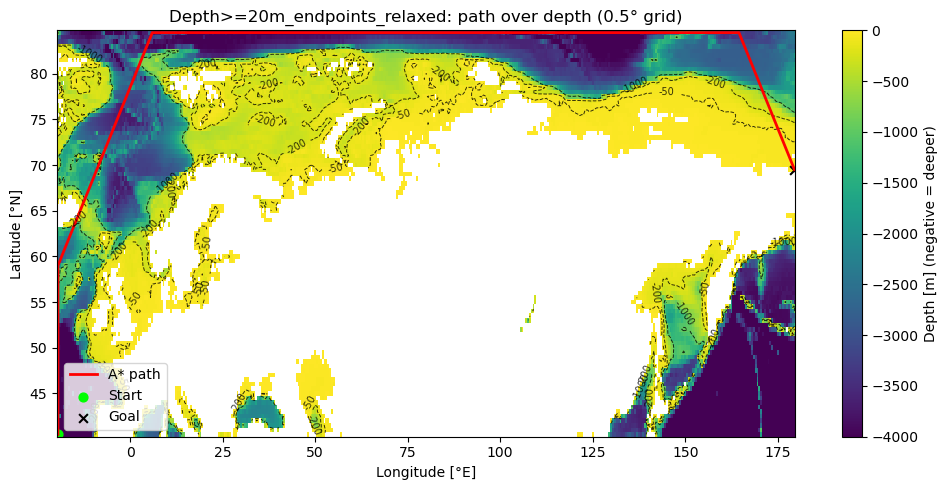

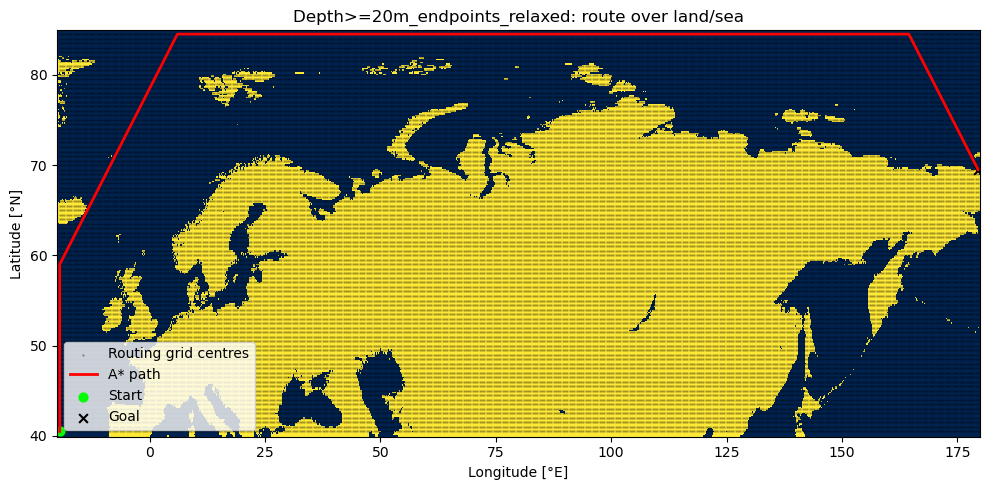

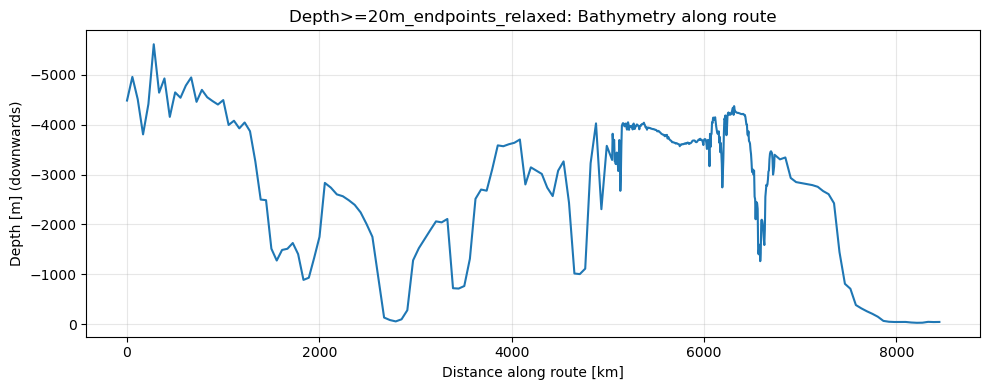

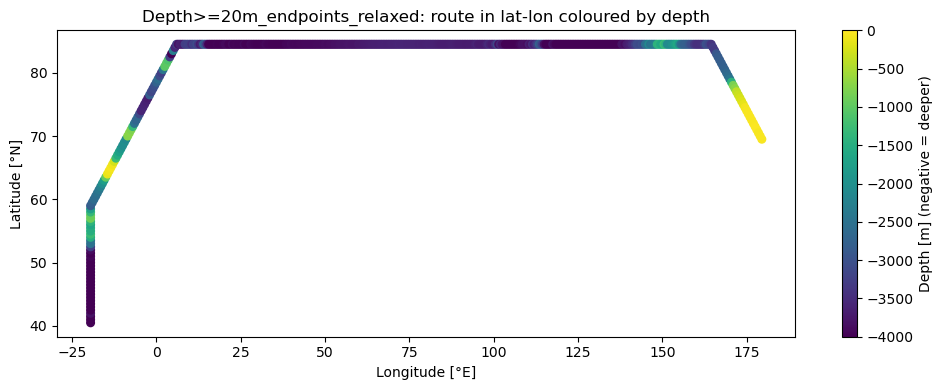

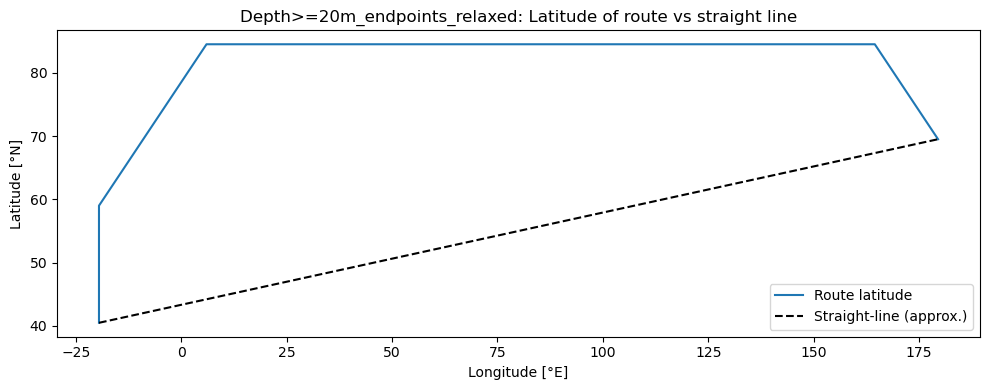

Plotting shallow sea cells: depth > -50.0 m (i.e. |depth| < 50.0 m)
  Total sea cells:         17129
  Shallow sea cells:       2630
  Fraction of sea shallow: 0.154
  Plotting 2630 shallow points as circles.


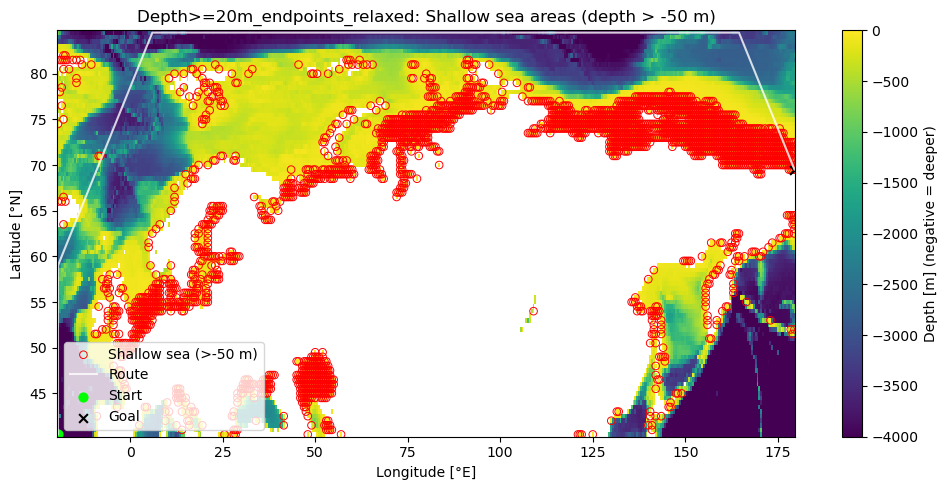

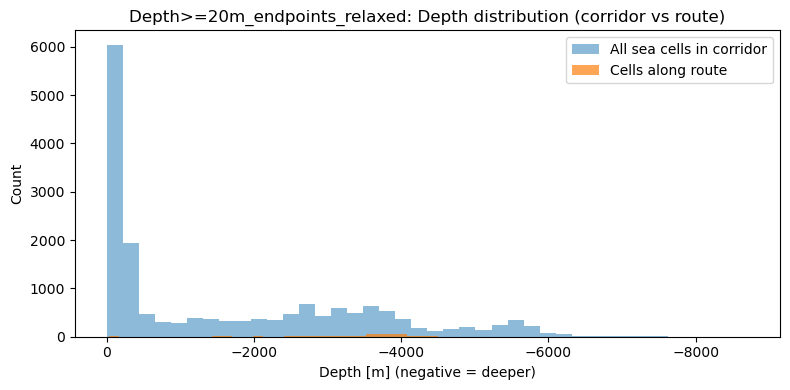

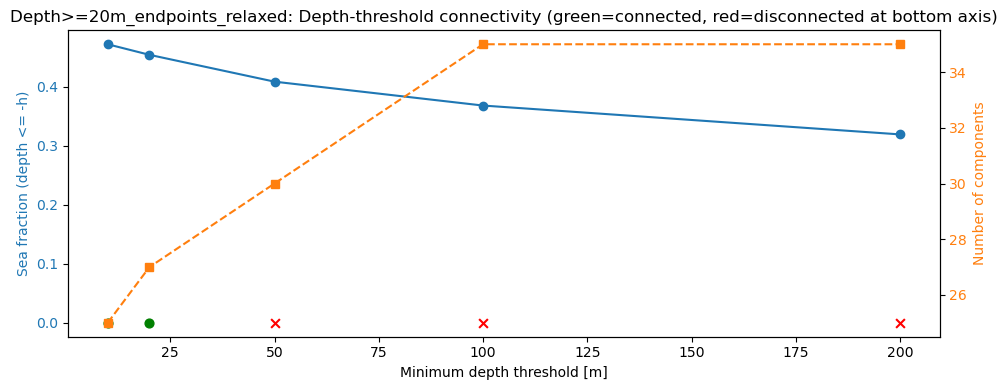

In [37]:
plot_route_diagnostics(
    path_idx_test,
    lats_rg,
    lons_rg,
    lat_s,
    lon_s,
    land_mask_s,
    depth_rg,
    land_rg,
    title_prefix="Depth>=20m_endpoints_relaxed",
    shallow_thresh_m=50.0,                     # show shallow shelves
    contour_levels=[-50, -200, -1000],         # isobaths
    show_depth_histogram=True,
    depth_thresholds_for_connectivity=[10,20,50,100,200],
    sea_mask_rg=sea_mask_rg,                   # for connectivity curve
)

# Step 11

In [46]:
from pathlib import Path

In [47]:
Path().cwd()

PosixPath('/Users/abdellamohamed/projects/phd/src/voyage_optimization/submission_3/notebooks')

=== STEP 11: Load & inspect CMEMS sea-ice concentration ===

--- CMEMS sea-ice dataset summary ---
<xarray.Dataset> Size: 15GB
Dimensions:    (time: 122, latitude: 1000, longitude: 7667)
Coordinates:
  * latitude   (latitude) float64 8kB 60.0 60.03 60.06 ... 89.91 89.94 89.97
  * time       (time) datetime64[ns] 976B 2018-06-01 2018-06-02 ... 2018-09-30
  * longitude  (longitude) float64 61kB -30.0 -29.97 -29.94 ... 200.0 200.0
Data variables:
    siconc     (time, latitude, longitude) float64 7GB ...
    sithick    (time, latitude, longitude) float64 7GB ...
Attributes:
    contact:                   servicedesk.cmems@mercator-ocean.eu
    institution:               NERSC, Jahnebakken 3, N-5007 Bergen, Norway
    source:                    neXtSIM model fields
    title:                     Arctic sea ice reanalysis
    references:                https://marine.copernicus.eu/
    credit:                    E.U. Copernicus Marine Service Information (CM...
    Conventions:             

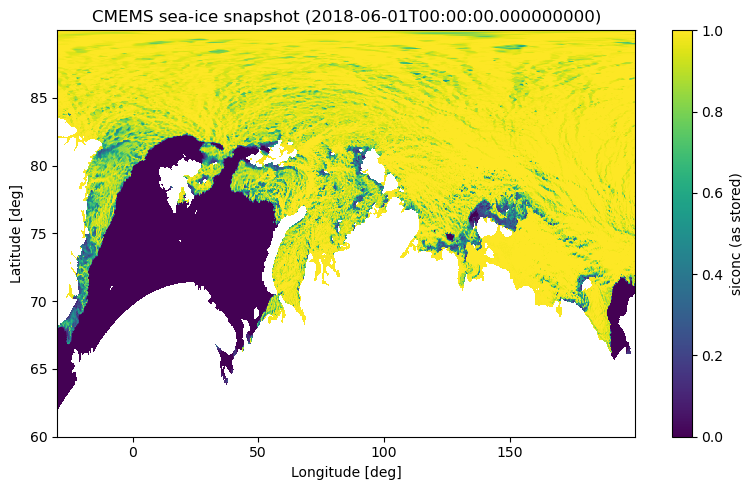


--- Ice concentration stats (first snapshot) ---
min: 0.0 max: 1.0000000000000002

=== END STEP 11 ===


In [38]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

print("=== STEP 11: Load & inspect CMEMS sea-ice concentration ===")

# 1) Set your CMEMS ice file path here
ICE_FILE = "arctic_routing_paperA/data/raw/seaice_cmems/cmems_arc_seaice_2018_JJAS_subset.nc"  # <<< CHANGE THIS

# --- Open dataset ---
ds_ice = xr.open_dataset(ICE_FILE)
print("\n--- CMEMS sea-ice dataset summary ---")
print(ds_ice)

print("\n--- Dimensions ---")
print(ds_ice.dims)

print("\n--- Coordinates ---")
print(list(ds_ice.coords))

print("\n--- Data variables ---")
print(list(ds_ice.data_vars))

# Try to guess variable + lat/lon names
# (we'll still print them explicitly so you can see)
# Common CMEMS naming: time, latitude, longitude, siconc
lat_name_candidates = [n for n in ds_ice.coords if "lat" in n.lower()]
lon_name_candidates = [n for n in ds_ice.coords if "lon" in n.lower()]
sic_name_candidates = [n for n in ds_ice.data_vars
                       if ("sic" in n.lower()) or ("siconc" in n.lower()) or ("ice" in n.lower())]

print("\nGuessed latitude coord name(s):", lat_name_candidates)
print("Guessed longitude coord name(s):", lon_name_candidates)
print("Guessed ice variable name(s):", sic_name_candidates)

# For now, pick first candidates (we can adjust later if needed)
lat_name = lat_name_candidates[0]
lon_name = lon_name_candidates[0]
sic_name = sic_name_candidates[0]

lat_ice = ds_ice[lat_name]
lon_ice = ds_ice[lon_name]
sic = ds_ice[sic_name]

print(f"\nUsing lat='{lat_name}', lon='{lon_name}', variable='{sic_name}'")

# --- Basic stats ---
print("\n--- Lat / Lon ranges (ice grid) ---")
print(f"{lat_name} min/max:", float(lat_ice.min()), float(lat_ice.max()))
print(f"{lon_name} min/max:", float(lon_ice.min()), float(lon_ice.max()))

if "time" in ds_ice.coords:
    t = ds_ice["time"]
    print("\n--- Time axis ---")
    print("Number of time steps:", t.size)
    print("First time:", t.isel(time=0).values)
    print("Last time :", t.isel(time=-1).values)
else:
    print("\n(No time coordinate found – assuming single static field.)")

# --- Pick one time slice for plotting (first time) ---
if "time" in sic.dims:
    sic0 = sic.isel(time=0)
    time_str = str(sic["time"].isel(time=0).values)
else:
    sic0 = sic
    time_str = "no_time_dim"

# --- Plot: sea-ice concentration over full ice grid ---
plt.figure(figsize=(8,5))
# handle 1D vs 2D lat/lon
if lat_ice.ndim == 1 and lon_ice.ndim == 1:
    im = plt.pcolormesh(
        lon_ice, lat_ice, sic0,
        shading="auto",
        cmap="viridis"
    )
else:
    im = plt.pcolormesh(
        lon_ice, lat_ice, sic0,
        shading="auto",
        cmap="viridis"
    )

cbar = plt.colorbar(im, label=f"{sic_name} (as stored)")
plt.xlabel("Longitude [deg]")
plt.ylabel("Latitude [deg]")
plt.title(f"CMEMS sea-ice snapshot ({time_str})")
plt.tight_layout()
plt.show()

# --- Also report min/max values for sanity ---
print("\n--- Ice concentration stats (first snapshot) ---")
print("min:", float(sic0.min()), "max:", float(sic0.max()))

print("\n=== END STEP 11 ===")

# Step 12

=== STEP 12: Regrid CMEMS sea-ice onto 0.5° routing grid ===
Selected ice time slice closest to 2018-09-01: 2018-09-01T00:00:00.000000000
siconc raw min/max for this slice: 0.000, 1.000
Detected siconc likely in 0–1; using as-is.

--- Regridding to routing grid ---
Ice grid lat range: 60.00000000000038 89.9700000000015
Ice grid lon range: -29.999999999994316 199.98000000000076
Routing grid lat range: 40.5 84.5
Routing grid lon range: -19.5 179.5
Regridded ice shape (routing grid): (89, 399)
NaN count on routing grid before fill: 25241
NaN count after fill: 0
Regridded siconc stats (0–1): min=0.000, mean=0.079, max=1.000

Fraction of sea cells with ice >= 15%: 0.202


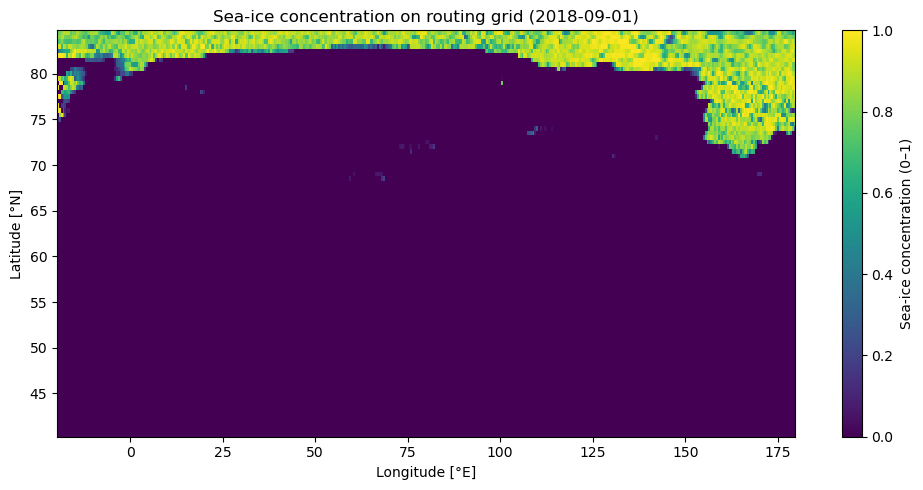

/var/folders/6_/4517vxws0wq2qfxj8hkfdgdm0000gp/T/ipykernel_22047/3888100339.py:102: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", 3)


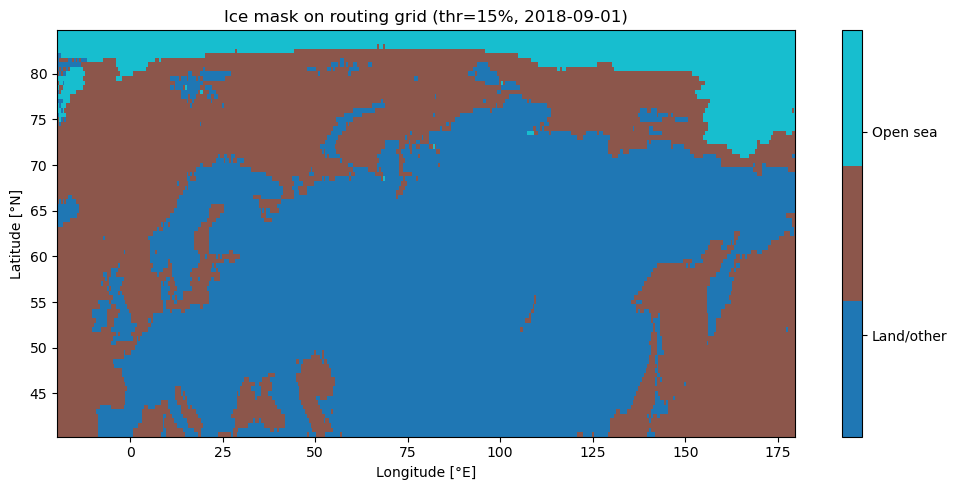


=== END STEP 12 ===


In [39]:
import numpy as np
import matplotlib.pyplot as plt

print("=== STEP 12: Regrid CMEMS sea-ice onto 0.5° routing grid ===")

# We assume from STEP 11:
# - ds_ice, sic_name, lat_name, lon_name already exist
# - sic = ds_ice[sic_name]
# And from previous LEGOs:
# - lats_rg, lons_rg (1D routing-grid coords)
# - sea_mask_rg, land_rg

# 1) Choose target date for ice
TARGET_DATE = np.datetime64("2018-09-01")  # adjust later as needed

sic_full = ds_ice[sic_name]
time_coord = ds_ice["time"]

# Select nearest time slice
sic_sel = sic_full.sel(time=TARGET_DATE, method="nearest")
sel_time = sic_sel["time"].values
print(f"Selected ice time slice closest to {TARGET_DATE}: {sel_time}")

# 2) Normalise to 0–1 if needed
max_val = float(sic_sel.max())
min_val = float(sic_sel.min())
print(f"siconc raw min/max for this slice: {min_val:.3f}, {max_val:.3f}")

if max_val > 1.5:  # then it is probably 0–100
    print("Detected siconc likely in 0–100; dividing by 100.")
    sic_norm = sic_sel / 100.0
else:
    print("Detected siconc likely in 0–1; using as-is.")
    sic_norm = sic_sel

sic_norm = sic_norm.clip(0.0, 1.0)

# 3) Interpolate to routing grid (nearest-neighbour for now)
lat_ice = ds_ice[lat_name]
lon_ice = ds_ice[lon_name]

print("\n--- Regridding to routing grid ---")
print("Ice grid lat range:", float(lat_ice.min()), float(lat_ice.max()))
print("Ice grid lon range:", float(lon_ice.min()), float(lon_ice.max()))
print("Routing grid lat range:", float(lats_rg.min()), float(lats_rg.max()))
print("Routing grid lon range:", float(lons_rg.min()), float(lons_rg.max()))

# xarray interp handles 1D lat/lon nicely
sic_rg = sic_norm.interp(
    {lat_name: lats_rg, lon_name: lons_rg},
    method="nearest"
)

print("Regridded ice shape (routing grid):", sic_rg.shape)

# 4) Fill NaNs (e.g. south of 60N) with 0 = open water
nan_count = int(np.isnan(sic_rg.values).sum())
print("NaN count on routing grid before fill:", nan_count)

sic_rg_filled = sic_rg.fillna(0.0)
print("NaN count after fill:", int(np.isnan(sic_rg_filled.values).sum()))

sic_rg_vals = sic_rg_filled.values
print("Regridded siconc stats (0–1): min={:.3f}, mean={:.3f}, max={:.3f}".format(
    sic_rg_vals.min(), sic_rg_vals.mean(), sic_rg_vals.max()
))

# 5) Build a simple ice mask for one threshold (e.g. 15% ice)
ICE_THRESH = 0.15  # 15% concentration
ice_blocked_rg = sic_rg_vals >= ICE_THRESH
sea_open_ice_safe = sea_mask_rg & (~ice_blocked_rg)

frac_ice_blocked_at_sea = ice_blocked_rg[sea_mask_rg].mean()
print(f"\nFraction of sea cells with ice >= {ICE_THRESH*100:.0f}%: "
      f"{frac_ice_blocked_at_sea:.3f}")

# 6) Plot: SIC on routing grid over our corridor
plt.figure(figsize=(10, 5))
im = plt.pcolormesh(
    lons_rg,
    lats_rg,
    sic_rg_vals,
    shading="auto",
    vmin=0.0,
    vmax=1.0,
    cmap="viridis"
)
plt.colorbar(im, label="Sea-ice concentration (0–1)")
plt.xlabel("Longitude [°E]")
plt.ylabel("Latitude [°N]")
plt.title(f"Sea-ice concentration on routing grid ({str(sel_time)[:10]})")
plt.tight_layout()
plt.show()

# 7) Plot: ice-blocked vs open sea on routing grid
#    0 = land or outside corridor, 1 = open sea, 2 = ice-blocked sea
plot_mask = np.zeros_like(sea_mask_rg, dtype=int)
plot_mask[sea_mask_rg & (~ice_blocked_rg)] = 1
plot_mask[sea_mask_rg & ice_blocked_rg] = 2

plt.figure(figsize=(10, 5))
cmap = plt.cm.get_cmap("tab10", 3)
im2 = plt.pcolormesh(
    lons_rg,
    lats_rg,
    plot_mask,
    shading="auto",
    cmap=cmap,
    vmin=0,
    vmax=2
)
cbar2 = plt.colorbar(im2, ticks=[0.5, 1.5, 2.5])
cbar2.ax.set_yticklabels(["Land/other", "Open sea", "Ice-blocked"])

plt.xlabel("Longitude [°E]")
plt.ylabel("Latitude [°N]")
plt.title(f"Ice mask on routing grid (thr={ICE_THRESH*100:.0f}%, {str(sel_time)[:10]})")
plt.tight_layout()
plt.show()

print("\n=== END STEP 12 ===")

# Step 13

=== STEP 13: Joint depth + ice constrained routing ===
Sea fraction on routing grid:            0.482
Depth-safe (>= 20 m) sea:   0.454 (94.1% of sea)
Ice-safe (ice < 15%) sea: 0.385 (79.8% of sea)
Joint depth+ice safe sea:               0.357 (74.0% of sea)

Number of joint-safe components: 39
Component ID (start, goal): 1 20
Start and goal in same joint-safe component? False
  -> No continuous joint-safe corridor between start and goal.


/var/folders/6_/4517vxws0wq2qfxj8hkfdgdm0000gp/T/ipykernel_22047/4178361874.py:84: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", 3)


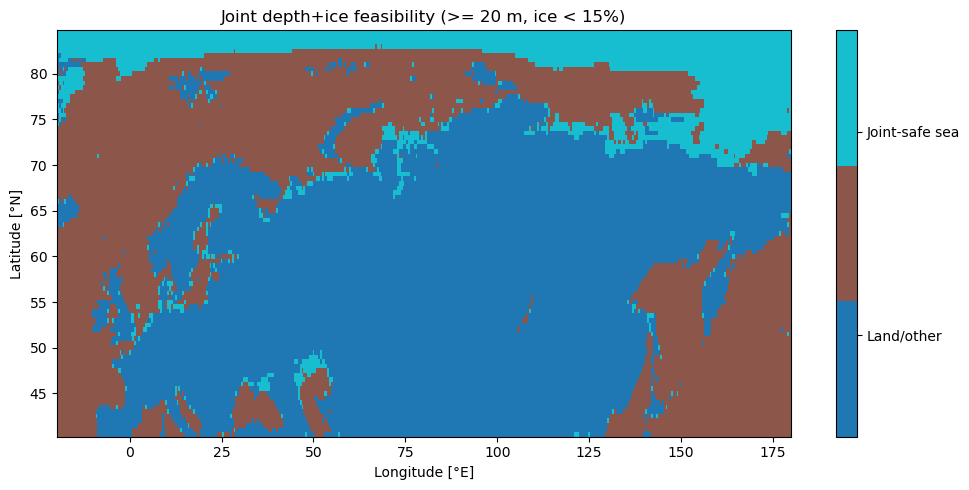

=== END STEP 13 ===


In [40]:
import numpy as np
import matplotlib.pyplot as plt

print("=== STEP 13: Joint depth + ice constrained routing ===")

# --- 1) Set thresholds (can tweak later) ---
DEPTH_MIN_M = 20.0    # require depth >= 20 m (i.e. depth <= -20)
ICE_THRESH  = 0.15    # ice >= 15% is blocked (should match previous cell)

# depth_rg: xarray DataArray with negative depth = deeper
depth_vals = depth_rg.values

# --- 2) Build masks ---
sea_mask = sea_mask_rg.astype(bool)
depth_safe_mask = sea_mask & (depth_vals <= -DEPTH_MIN_M)
ice_safe_mask   = sea_mask & (~ice_blocked_rg)

joint_safe_mask = depth_safe_mask & ice_safe_mask  # sea & deep & ice-free

# --- 3) Print fractions for debugging ---
sea_frac          = sea_mask.mean()
depth_safe_frac   = depth_safe_mask.mean()
ice_safe_frac     = ice_safe_mask.mean()
joint_safe_frac   = joint_safe_mask.mean()

print(f"Sea fraction on routing grid:            {sea_frac:.3f}")
print(f"Depth-safe (>= {DEPTH_MIN_M:.0f} m) sea:   {depth_safe_frac:.3f} "
      f"({depth_safe_frac/sea_frac*100:.1f}% of sea)")
print(f"Ice-safe (ice < {ICE_THRESH*100:.0f}%) sea: {ice_safe_frac:.3f} "
      f"({ice_safe_frac/sea_frac*100:.1f}% of sea)")
print(f"Joint depth+ice safe sea:               {joint_safe_frac:.3f} "
      f"({joint_safe_frac/sea_frac*100:.1f}% of sea)")

# --- 4) Check connectivity via components ---
labels_joint, ncomp_joint = label_sea_components(joint_safe_mask)
print(f"\nNumber of joint-safe components: {ncomp_joint}")

si, sj = start_idx_test
gi, gj = goal_idx_test

lab_s = labels_joint[si, sj]
lab_g = labels_joint[gi, gj]
print(f"Component ID (start, goal): {lab_s} {lab_g}")

if (lab_s == 0) or (lab_g == 0):
    print("  -> Start or goal lies outside joint-safe sea. No route under these constraints.")
    path_joint = None
else:
    same_comp = (lab_s == lab_g)
    print(f"Start and goal in same joint-safe component? {same_comp}")
    if not same_comp:
        print("  -> No continuous joint-safe corridor between start and goal.")
        path_joint = None
    else:
        # --- 5) Run A* on joint-safe mask ---
        print("\nRunning A* with joint depth+ice mask ...")
        path_joint = astar_route(
            joint_safe_mask,
            si, sj,
            gi, gj,
            lats_rg, lons_rg,
            cost_mode="distance"  # same as before: great-circle distance
        )
        if path_joint is None:
            print("  A*: No path found, unexpected given connectivity. (Check cost/mask.)")
        else:
            print("  A*: path found. Summarising...")
            summarise_route(
                path_joint,
                lats_rg,
                lons_rg,
                depth_vals,
                title_prefix=f"Depth>={DEPTH_MIN_M:.0f}m & ice<{ICE_THRESH*100:.0f}%"
            )

# --- 6) Simple map of joint feasibility + route ---
plt.figure(figsize=(10, 5))

# 0=land/other, 1=joint-safe sea, 2=sea but blocked by depth or ice
plot_mask = np.zeros_like(sea_mask, dtype=int)
plot_mask[sea_mask & (~joint_safe_mask)] = 2
plot_mask[joint_safe_mask] = 1

cmap = plt.cm.get_cmap("tab10", 3)
im = plt.pcolormesh(
    lons_rg,
    lats_rg,
    plot_mask,
    shading="auto",
    cmap=cmap,
    vmin=0,
    vmax=2,
)
cbar = plt.colorbar(im, ticks=[0.5, 1.5, 2.5])
cbar.ax.set_yticklabels(["Land/other", "Joint-safe sea", "Sea but blocked"])

# overlay route if we have one
if path_joint is not None:
    path_arr = np.array(path_joint)
    p_i = path_arr[:, 0]
    p_j = path_arr[:, 1]
    plt.plot(lons_rg[p_j], lats_rg[p_i], "r-", lw=2, label="Joint-safe route")
    plt.scatter(lons_rg[sj], lats_rg[si], c="lime", marker="o", s=40, label="Start")
    plt.scatter(lons_rg[gj], lats_rg[gi], c="black", marker="x", s=40, label="Goal")
    plt.legend(loc="lower left")

plt.xlabel("Longitude [°E]")
plt.ylabel("Latitude [°N]")
plt.title(f"Joint depth+ice feasibility (>= {DEPTH_MIN_M:.0f} m, ice < {ICE_THRESH*100:.0f}%)")
plt.tight_layout()
plt.show()

print("=== END STEP 13 ===")

# Step 13b

In [41]:
import numpy as np
import matplotlib.pyplot as plt

print("=== STEP 13b: Ice-only constrained routing (DEPTH OFF) ===")

ICE_THRESH = 0.15  # should match what we used before
sea_mask = sea_mask_rg.astype(bool)

# ice_blocked_rg comes from STEP 12 (sic >= ICE_THRESH)
ice_safe_mask = sea_mask & (~ice_blocked_rg)

sea_frac        = sea_mask.mean()
ice_safe_frac   = ice_safe_mask.mean()

print(f"Sea fraction on routing grid:        {sea_frac:.3f}")
print(f"Ice-safe (ice < {ICE_THRESH*100:.0f}%) sea: {ice_safe_frac:.3f} "
      f"({ice_safe_frac/sea_frac*100:.1f}% of sea)")

# --- Connected components on ice-safe sea ---
labels_ice, ncomp_ice = label_sea_components(ice_safe_mask)
print(f"\nNumber of ice-safe components: {ncomp_ice}")

si, sj = start_idx_test
gi, gj = goal_idx_test

lab_s = labels_ice[si, sj]
lab_g = labels_ice[gi, gj]
print(f"Component ID (start, goal): {lab_s} {lab_g}")

path_ice = None
if (lab_s == 0) or (lab_g == 0):
    print("  -> Start or goal lies outside ice-safe sea. No route under ice-only mask.")
else:
    same_comp = (lab_s == lab_g)
    print(f"Start and goal in same ice-safe component? {same_comp}")
    if not same_comp:
        print("  -> No continuous ice-safe corridor between start and goal (even without depth).")
    else:
        print("\nRunning A* on ice-safe mask (distance cost)...")
        path_ice = astar_route(
            ice_safe_mask,
            si, sj,
            gi, gj,
            lats_rg, lons_rg,
            cost_mode="distance"
        )
        if path_ice is None:
            print("  A*: No path found despite connectivity (check implementation).")
        else:
            print("  A*: path found. Summary:")
            summarise_route(
                path_ice,
                lats_rg,
                lons_rg,
                depth_rg.values,
                title_prefix=f"Ice<{ICE_THRESH*100:.0f}% (no depth constraint)"
            )

# --- Map: ice-safe feasibility + route if exists ---
plt.figure(figsize=(10, 5))

plot_mask = np.zeros_like(sea_mask, dtype=int)
plot_mask[sea_mask & (~ice_safe_mask)] = 2  # sea but ice-blocked
plot_mask[ice_safe_mask] = 1               # ice-safe sea

cmap = plt.cm.get_cmap("tab10", 3)
im = plt.pcolormesh(
    lons_rg,
    lats_rg,
    plot_mask,
    shading="auto",
    cmap=cmap,
    vmin=0,
    vmax=2,
)
cbar = plt.colorbar(im, ticks=[0.5, 1.5, 2.5])
cbar.ax.set_yticklabels(["Land/other", "Ice-safe sea", "Sea but ice-blocked"])

if path_ice is not None:
    p = np.array(path_ice)
    p_i, p_j = p[:, 0], p[:, 1]
    plt.plot(lons_rg[p_j], lats_rg[p_i], "r-", lw=2, label="Ice-safe route")
    plt.scatter(lons_rg[sj], lats_rg[si], c="lime", marker="o", s=40, label="Start")
    plt.scatter(lons_rg[gj], lats_rg[gi], c="black", marker="x", s=40, label="Goal")
    plt.legend(loc="lower left")

plt.xlabel("Longitude [°E]")
plt.ylabel("Latitude [°N]")
plt.title(f"Ice-only feasibility (ice < {ICE_THRESH*100:.0f}%, {str(sel_time)[:10]})")
plt.tight_layout()
plt.show()

print("=== END STEP 13b ===")

=== STEP 13b: Ice-only constrained routing (DEPTH OFF) ===
Sea fraction on routing grid:        0.482
Ice-safe (ice < 15%) sea: 0.385 (79.8% of sea)

Number of ice-safe components: 31
Component ID (start, goal): 1 1
Start and goal in same ice-safe component? True

Running A* on ice-safe mask (distance cost)...


NameError: name 'astar_route' is not defined

In [42]:
import heapq
import numpy as np

def astar_route(mask, si, sj, gi, gj, lats_rg, lons_rg, cost_mode="distance"):
    """
    Minimal A* on a 2D boolean mask.

    Parameters
    ----------
    mask : 2D bool
        True = traversable, False = blocked.
    si, sj : int
        Start indices (i,j).
    gi, gj : int
        Goal indices (i,j).
    lats_rg, lons_rg : 1D arrays
        Routing-grid lat/lon (for distance heuristic).
    cost_mode : {"steps", "distance"}
        If "steps": cost per move = 1 (plus sqrt(2) for diagonal).
        If "distance": cost per move = great-circle distance between cell centres.

    Returns
    -------
    path : list[(i,j)] or None
        Sequence of indices from start to goal (inclusive), or None if no path.
    """
    n_i, n_j = mask.shape
    if not mask[si, sj] or not mask[gi, gj]:
        return None

    # Precompute lat/lon arrays for heuristic and cost
    lon2d, lat2d = np.meshgrid(lons_rg, lats_rg)

    def haversine(lat1, lon1, lat2, lon2):
        R = 6371.0e3
        phi1 = np.radians(lat1)
        phi2 = np.radians(lat2)
        dphi = np.radians(lat2 - lat1)
        dlambda = np.radians(lon2 - lon1)
        a = np.sin(dphi / 2) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2) ** 2
        return 2 * R * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    def heuristic(i, j):
        return haversine(
            lat2d[i, j], lon2d[i, j],
            lat2d[gi, gj], lon2d[gi, gj]
        )

    # Neighbour offsets (8-connected grid)
    neighbours = [(-1, 0), (1, 0), (0, -1), (0, 1),
                  (-1, -1), (-1, 1), (1, -1), (1, 1)]

    start = (si, sj)
    goal = (gi, gj)

    open_set = []
    heapq.heappush(open_set, (0.0, start))
    came_from = {}
    g_score = {start: 0.0}

    visited_count = 0

    while open_set:
        _, current = heapq.heappop(open_set)
        visited_count += 1

        if current == goal:
            # Reconstruct path
            path = [current]
            while current in came_from:
                current = came_from[current]
                path.append(current)
            path.reverse()
            print(f"  A*: reached goal after visiting {visited_count} nodes.")
            return path

        ci, cj = current
        for di, dj in neighbours:
            ni, nj = ci + di, cj + dj
            if ni < 0 or ni >= n_i or nj < 0 or nj >= n_j:
                continue
            if not mask[ni, nj]:
                continue

            # Movement cost
            if cost_mode == "steps":
                step_cost = np.sqrt(2.0) if (di != 0 and dj != 0) else 1.0
            else:
                step_cost = haversine(
                    lat2d[ci, cj], lon2d[ci, cj],
                    lat2d[ni, nj], lon2d[ni, nj]
                )

            tentative_g = g_score[current] + step_cost
            neighbour = (ni, nj)

            if tentative_g < g_score.get(neighbour, np.inf):
                came_from[neighbour] = current
                g_score[neighbour] = tentative_g
                f = tentative_g + heuristic(ni, nj)
                heapq.heappush(open_set, (f, neighbour))

    print(f"  A*: failed to find path after visiting {visited_count} nodes.")
    return None


def summarise_route(path_idx, lats_rg, lons_rg, depth_vals, title_prefix=""):
    """
    Print a small summary of route length, GC distance, ratio, and depths.
    """
    import numpy as np

    path = np.array(path_idx)
    pi = path[:, 0]
    pj = path[:, 1]
    lat_route = lats_rg[pi]
    lon_route = lons_rg[pj]

    def haversine(lat1, lon1, lat2, lon2):
        R = 6371.0e3
        phi1 = np.radians(lat1)
        phi2 = np.radians(lat2)
        dphi = np.radians(lat2 - lat1)
        dlambda = np.radians(lon2 - lon1)
        a = np.sin(dphi / 2) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2) ** 2
        return 2 * R * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    dists = []
    for k in range(1, len(lat_route)):
        d = haversine(lat_route[k-1], lon_route[k-1],
                      lat_route[k],   lon_route[k])
        dists.append(d)
    total_m = np.sum(dists)
    total_nm = total_m / 1852.0

    # straight great-circle
    gc_m = haversine(lat_route[0], lon_route[0],
                     lat_route[-1], lon_route[-1])
    gc_nm = gc_m / 1852.0

    ratio = total_nm / gc_nm if gc_nm > 0 else np.nan

    depth_route = depth_vals[pi, pj]
    dmin = float(depth_route.min())
    dmean = float(depth_route.mean())
    dmax = float(depth_route.max())

    print("---- Route summary ----")
    print(f"Start (lat,lon): ({lat_route[0]:.2f}, {lon_route[0]:.2f})")
    print(f"Goal  (lat,lon): ({lat_route[-1]:.2f}, {lon_route[-1]:.2f})")
    print(f"Route steps: {len(path_idx)}")
    print(f"Route distance: {total_nm:.1f} NM ({total_m/1000:.1f} km)")
    print(f"Straight GC : {gc_nm:.1f} NM")
    print(f"Route / straight ratio: {ratio:.3f}")
    print(f"Depth along route [m]: min={dmin:.1f}, mean={dmean:.1f}, max={dmax:.1f}")
    print("------------------------")

In [66]:
sic

<xarray.DataArray 'siconc' (time: 122, latitude: 1000, longitude: 7667)> Size: 7GB
[935374000 values with dtype=float64]
Coordinates:
  * latitude   (latitude) float64 8kB 60.0 60.03 60.06 ... 89.91 89.94 89.97
  * time       (time) datetime64[ns] 976B 2018-06-01 2018-06-02 ... 2018-09-30
  * longitude  (longitude) float64 61kB -30.0 -29.97 -29.94 ... 200.0 200.0
Attributes:
    standard_name:  sea_ice_area_fraction
    units:          1
    long_name:      Sea Ice Concentration

=== STEP 13b: Ice-only constrained routing (DEPTH OFF) ===
Sea fraction on routing grid:        0.482
Ice-safe (ice < 15%) sea: 0.385 (79.8% of sea)

Number of ice-safe components: 31
Component ID (start, goal): 1 1
Start and goal in same ice-safe component? True

Running A* on ice-safe mask (distance cost)...
  A*: reached goal after visiting 18144 nodes.
  A*: path found. Summary:
---- Route summary ----
Start (lat,lon): (40.50, -19.50)
Goal  (lat,lon): (69.50, 179.50)
Route steps: 427
Route distance: 5037.6 NM (9329.7 km)
Straight GC : 4149.6 NM
Route / straight ratio: 1.214
Depth along route [m]: min=-5612.0, mean=-1713.7, max=-9.0
------------------------


/var/folders/6_/4517vxws0wq2qfxj8hkfdgdm0000gp/T/ipykernel_22047/2140652216.py:66: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", 3)


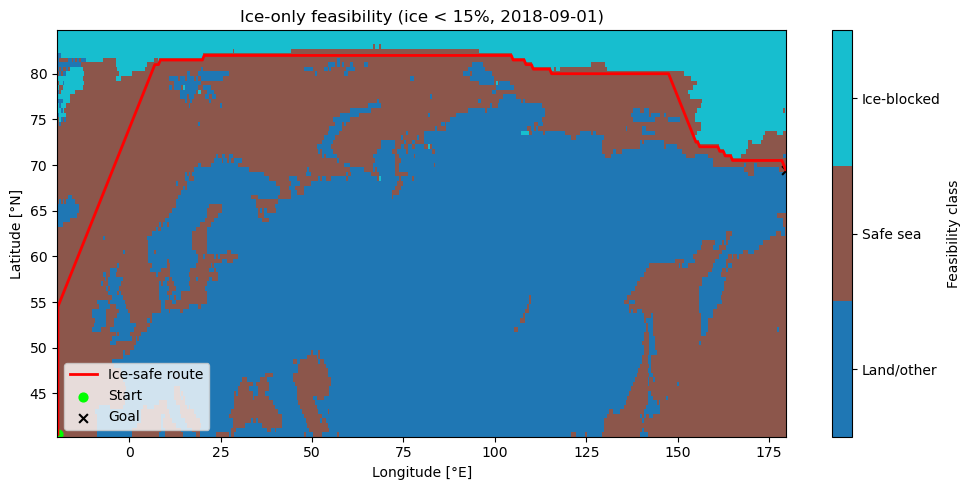

=== END STEP 13b ===


In [48]:
import numpy as np
import matplotlib.pyplot as plt

print("=== STEP 13b: Ice-only constrained routing (DEPTH OFF) ===")

ICE_THRESH = 0.15  # should match what we used before
sea_mask = sea_mask_rg.astype(bool)

# ice_blocked_rg comes from STEP 12 (sic >= ICE_THRESH)
ice_safe_mask = sea_mask & (~ice_blocked_rg)

sea_frac        = sea_mask.mean()
ice_safe_frac   = ice_safe_mask.mean()

print(f"Sea fraction on routing grid:        {sea_frac:.3f}")
print(f"Ice-safe (ice < {ICE_THRESH*100:.0f}%) sea: {ice_safe_frac:.3f} "
      f"({ice_safe_frac/sea_frac*100:.1f}% of sea)")

# --- Connected components on ice-safe sea ---
labels_ice, ncomp_ice = label_sea_components(ice_safe_mask)
print(f"\nNumber of ice-safe components: {ncomp_ice}")

si, sj = start_idx_test
gi, gj = goal_idx_test

lab_s = labels_ice[si, sj]
lab_g = labels_ice[gi, gj]
print(f"Component ID (start, goal): {lab_s} {lab_g}")

path_ice = None
if (lab_s == 0) or (lab_g == 0):
    print("  -> Start or goal lies outside ice-safe sea. No route under ice-only mask.")
else:
    same_comp = (lab_s == lab_g)
    print(f"Start and goal in same ice-safe component? {same_comp}")
    if not same_comp:
        print("  -> No continuous ice-safe corridor between start and goal (even without depth).")
    else:
        print("\nRunning A* on ice-safe mask (distance cost)...")
        path_ice = astar_route(
            ice_safe_mask,
            si, sj,
            gi, gj,
            lats_rg, lons_rg,
            cost_mode="distance"
        )
        if path_ice is None:
            print("  A*: No path found despite connectivity (check implementation).")
        else:
            print("  A*: path found. Summary:")
            summarise_route(
                path_ice,
                lats_rg,
                lons_rg,
                depth_rg.values,
                title_prefix=f"Ice<{ICE_THRESH*100:.0f}% (no depth constraint)"
            )

# --- Map: ice-safe feasibility + route if exists ---
plt.figure(figsize=(10, 5))

plot_mask = np.zeros_like(sea_mask, dtype=int)
plot_mask[sea_mask & (~ice_safe_mask)] = 2  # sea but ice-blocked
plot_mask[ice_safe_mask] = 1               # ice-safe sea

cmap = plt.cm.get_cmap("tab10", 3)

im = plt.pcolormesh(
    lons_rg,
    lats_rg,
    plot_mask,
    shading="auto",
    cmap=cmap,
    vmin=-0.5,   # so classes 0,1,2 are centered
    vmax=2.5,
)

cbar = plt.colorbar(im, ticks=[0, 1, 2])
cbar.ax.set_yticklabels(["Land/other", "Safe sea", "Ice-blocked"])
cbar.set_label("Feasibility class")

if path_ice is not None:
    p = np.array(path_ice)
    p_i, p_j = p[:, 0], p[:, 1]
    plt.plot(lons_rg[p_j], lats_rg[p_i], "r-", lw=2, label="Ice-safe route")
    plt.scatter(lons_rg[sj], lats_rg[si], c="lime", marker="o", s=40, label="Start")
    plt.scatter(lons_rg[gj], lats_rg[gi], c="black", marker="x", s=40, label="Goal")
    plt.legend(loc="lower left")

plt.xlabel("Longitude [°E]")
plt.ylabel("Latitude [°N]")
plt.title(f"Ice-only feasibility (ice < {ICE_THRESH*100:.0f}%, {str(sel_time)[:10]})")

plt.tight_layout()

# Save to disk (change filename/format as you like)
plt.savefig("fig_ice_feasibility_20180901.png",
            dpi=300, bbox_inches="tight")

plt.show()
print("=== END STEP 13b ===")

=== STEP 13b: Ice-only constrained routing (DEPTH OFF) ===
Sea fraction on routing grid:        0.482
Ice-safe (ice < 15%) sea: 0.385 (79.8% of sea)

Number of ice-safe components: 31
Component ID (start, goal): 1 1
Start and goal in same ice-safe component? True

Running A* on ice-safe mask (distance cost)...
  A*: reached goal after visiting 18144 nodes.
  A*: path found. Summary:
---- Route summary ----
Start (lat,lon): (40.50, -19.50)
Goal  (lat,lon): (69.50, 179.50)
Route steps: 427
Route distance: 5037.6 NM (9329.7 km)
Straight GC : 4149.6 NM
Route / straight ratio: 1.214
Depth along route [m]: min=-5612.0, mean=-1713.7, max=-9.0
------------------------


/var/folders/6_/4517vxws0wq2qfxj8hkfdgdm0000gp/T/ipykernel_94770/2155118738.py:66: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", 3)


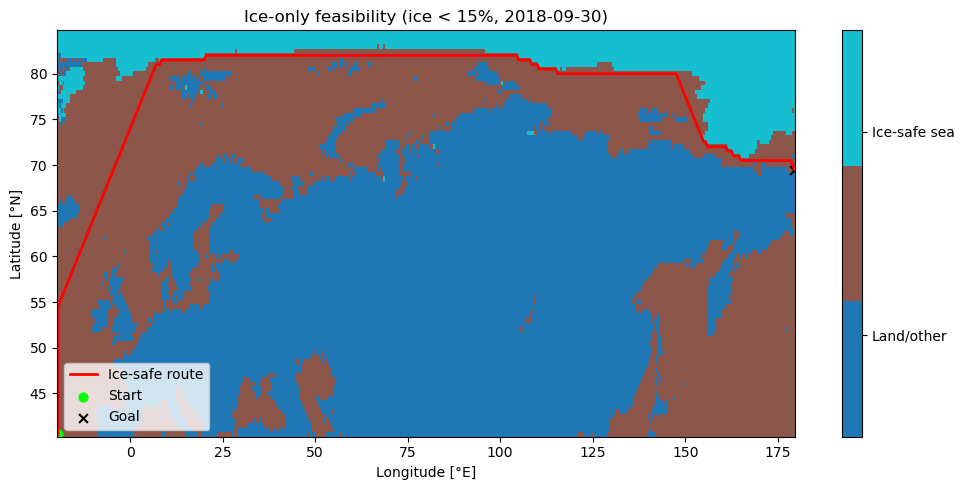

=== END STEP 13b ===


In [69]:
import numpy as np
import matplotlib.pyplot as plt

print("=== STEP 13b: Ice-only constrained routing (DEPTH OFF) ===")

ICE_THRESH = 0.15  # should match what we used before
sea_mask = sea_mask_rg.astype(bool)

# ice_blocked_rg comes from STEP 12 (sic >= ICE_THRESH)
ice_safe_mask = sea_mask & (~ice_blocked_rg)

sea_frac        = sea_mask.mean()
ice_safe_frac   = ice_safe_mask.mean()

print(f"Sea fraction on routing grid:        {sea_frac:.3f}")
print(f"Ice-safe (ice < {ICE_THRESH*100:.0f}%) sea: {ice_safe_frac:.3f} "
      f"({ice_safe_frac/sea_frac*100:.1f}% of sea)")

# --- Connected components on ice-safe sea ---
labels_ice, ncomp_ice = label_sea_components(ice_safe_mask)
print(f"\nNumber of ice-safe components: {ncomp_ice}")

si, sj = start_idx_test
gi, gj = goal_idx_test

lab_s = labels_ice[si, sj]
lab_g = labels_ice[gi, gj]
print(f"Component ID (start, goal): {lab_s} {lab_g}")

path_ice = None
if (lab_s == 0) or (lab_g == 0):
    print("  -> Start or goal lies outside ice-safe sea. No route under ice-only mask.")
else:
    same_comp = (lab_s == lab_g)
    print(f"Start and goal in same ice-safe component? {same_comp}")
    if not same_comp:
        print("  -> No continuous ice-safe corridor between start and goal (even without depth).")
    else:
        print("\nRunning A* on ice-safe mask (distance cost)...")
        path_ice = astar_route(
            ice_safe_mask,
            si, sj,
            gi, gj,
            lats_rg, lons_rg,
            cost_mode="distance"
        )
        if path_ice is None:
            print("  A*: No path found despite connectivity (check implementation).")
        else:
            print("  A*: path found. Summary:")
            summarise_route(
                path_ice,
                lats_rg,
                lons_rg,
                depth_rg.values,
                title_prefix=f"Ice<{ICE_THRESH*100:.0f}% (no depth constraint)"
            )

# --- Map: ice-safe feasibility + route if exists ---
plt.figure(figsize=(10, 5))

plot_mask = np.zeros_like(sea_mask, dtype=int)
plot_mask[sea_mask & (~ice_safe_mask)] = 2  # sea but ice-blocked
plot_mask[ice_safe_mask] = 1               # ice-safe sea

cmap = plt.cm.get_cmap("tab10", 3)
im = plt.pcolormesh(
    lons_rg,
    lats_rg,
    plot_mask,
    shading="auto",
    cmap=cmap,
    vmin=0,
    vmax=2,
)
cbar = plt.colorbar(im, ticks=[0.5, 1.5, 2.5])
cbar.ax.set_yticklabels(["Land/other", "Ice-safe sea", "Sea but ice-blocked"])

if path_ice is not None:
    p = np.array(path_ice)
    p_i, p_j = p[:, 0], p[:, 1]
    plt.plot(lons_rg[p_j], lats_rg[p_i], "r-", lw=2, label="Ice-safe route")
    plt.scatter(lons_rg[sj], lats_rg[si], c="lime", marker="o", s=40, label="Start")
    plt.scatter(lons_rg[gj], lats_rg[gi], c="black", marker="x", s=40, label="Goal")
    plt.legend(loc="lower left")

plt.xlabel("Longitude [°E]")
plt.ylabel("Latitude [°N]")
plt.title(f"Ice-only feasibility (ice < {ICE_THRESH*100:.0f}%, {str(sel_time)[:10]})")
plt.tight_layout()
plt.show()

print("=== END STEP 13b ===")

In [76]:
import numpy as np
import matplotlib.pyplot as plt

print("=== STEP 13b: Ice-only constrained routing (DEPTH OFF) ===")

ICE_THRESH = 0.15  # should match what we used before
sea_mask = sea_mask_rg.astype(bool)

# ice_blocked_rg comes from STEP 12 (sic >= ICE_THRESH)
ice_safe_mask = sea_mask & (~ice_blocked_rg)

sea_frac        = sea_mask.mean()
ice_safe_frac   = ice_safe_mask.mean()

print(f"Sea fraction on routing grid:        {sea_frac:.3f}")
print(f"Ice-safe (ice < {ICE_THRESH*100:.0f}%) sea: {ice_safe_frac:.3f} "
      f"({ice_safe_frac/sea_frac*100:.1f}% of sea)")

# --- Connected components on ice-safe sea ---
labels_ice, ncomp_ice = label_sea_components(ice_safe_mask)
print(f"\nNumber of ice-safe components: {ncomp_ice}")

si, sj = start_idx_test
gi, gj = goal_idx_test

lab_s = labels_ice[si, sj]
lab_g = labels_ice[gi, gj]
print(f"Component ID (start, goal): {lab_s} {lab_g}")

path_ice = None
if (lab_s == 0) or (lab_g == 0):
    print("  -> Start or goal lies outside ice-safe sea. No route under ice-only mask.")
else:
    same_comp = (lab_s == lab_g)
    print(f"Start and goal in same ice-safe component? {same_comp}")
    if not same_comp:
        print("  -> No continuous ice-safe corridor between start and goal (even without depth).")
    else:
        print("\nRunning A* on ice-safe mask (distance cost)...")
        path_ice = astar_route(
            ice_safe_mask,
            si, sj,
            gi, gj,
            lats_rg, lons_rg,
            cost_mode="distance"
        )
        if path_ice is None:
            print("  A*: No path found despite connectivity (check implementation).")
        else:
            print("  A*: path found. Summary:")
            summarise_route(
                path_ice,
                lats_rg,
                lons_rg,
                depth_rg.values,
                title_prefix=f"Ice<{ICE_THRESH*100:.0f}% (no depth constraint)"
            )

# --- Map: ice-safe feasibility + route if exists ---
plt.figure(figsize=(10, 5))

plot_mask = np.zeros_like(sea_mask, dtype=int)
plot_mask[sea_mask & (~ice_safe_mask)] = 2  # sea but ice-blocked
plot_mask[ice_safe_mask] = 1               # ice-safe sea

cmap = plt.cm.get_cmap("tab10", 3)
im = plt.pcolormesh(
    lons_rg,
    lats_rg,
    plot_mask,
    shading="auto",
    cmap=cmap,
    vmin=0,
    vmax=2,
)
cbar = plt.colorbar(im, ticks=[0.5, 1.5, 2.5])
cbar.ax.set_yticklabels(["Land/other", "Safe sea", "Ice-blocked"])

if path_ice is not None:
    p = np.array(path_ice)
    p_i, p_j = p[:, 0], p[:, 1]
    plt.plot(lons_rg[p_j], lats_rg[p_i], "r-", lw=2, label="Ice-safe route")
    plt.scatter(lons_rg[sj], lats_rg[si], c="lime", marker="o", s=40, label="Start")
    plt.scatter(lons_rg[gj], lats_rg[gi], c="black", marker="x", s=40, label="Goal")
    plt.legend(loc="lower left")

plt.xlabel("Longitude [°E]")
plt.ylabel("Latitude [°N]")
plt.title(f"Ice-only feasibility (ice < {ICE_THRESH*100:.0f}%, {str(sel_time)[:10]})")
plt.tight_layout()
plt.show()

print("=== END STEP 13b ===")

=== STEP 13b: Ice-only constrained routing (DEPTH OFF) ===


ValueError: operands could not be broadcast together with shapes (89,399) (1000,7667) 

In [67]:
sic

<xarray.DataArray 'siconc' (time: 122, latitude: 1000, longitude: 7667)> Size: 7GB
[935374000 values with dtype=float64]
Coordinates:
  * latitude   (latitude) float64 8kB 60.0 60.03 60.06 ... 89.91 89.94 89.97
  * time       (time) datetime64[ns] 976B 2018-06-01 2018-06-02 ... 2018-09-30
  * longitude  (longitude) float64 61kB -30.0 -29.97 -29.94 ... 200.0 200.0
Attributes:
    standard_name:  sea_ice_area_fraction
    units:          1
    long_name:      Sea Ice Concentration

In [75]:
import numpy as np
import matplotlib.pyplot as plt

print("=== STEP 13b: Ice-only constrained routing (DEPTH OFF) ===")

ICE_THRESH = 0.15  # 15 % SIC
sea_mask = sea_mask_rg.astype(bool)

# Two dates to show side by side
sel_times = [np.datetime64("2018-08-15"), np.datetime64("2018-09-15")]

si, sj = start_idx_test
gi, gj = goal_idx_test

results = []

for sel_time in sel_times:
    print(f"\n--- Date: {str(sel_time)[:10]} ---")

    # 1) Extract SIC for this date
    sic_rg_sel = sic.sel(time=sel_time)

    # 2) Regrid SIC to routing grid if necessary
    #    (shape mismatch => do xarray interp to 0.5° grid)
    if sic_rg_sel.shape != sea_mask.shape:
        # Infer coord names
        lat_dim = [d for d in sic_rg_sel.dims if "lat" in d.lower()][0]
        lon_dim = [d for d in sic_rg_sel.dims if "lon" in d.lower() or "x" in d.lower()][0]

        # Recover routing-grid 1D lat/lon from 2D arrays
        lat_rg_1d = lats_rg[:, 0]
        lon_rg_1d = lons_rg[0, :]

        sic_rg_sel = sic_rg_sel.interp(
            **{
                lat_dim: lat_rg_1d,
                lon_dim: lon_rg_1d,
            }
        )

    sic_vals = np.asarray(sic_rg_sel)  # now (89, 399)

    # 3) Build ice masks on routing grid
    ice_blocked_rg = sic_vals >= ICE_THRESH
    ice_safe_mask  = sea_mask & (~ice_blocked_rg)

    sea_frac      = sea_mask.mean()
    ice_safe_frac = ice_safe_mask.mean()

    print(f"Sea fraction on routing grid:        {sea_frac:.3f}")
    print(f"Ice-safe (ice < {ICE_THRESH*100:.0f}%) sea: {ice_safe_frac:.3f} "
          f"({ice_safe_frac/sea_frac*100:.1f}% of sea)")

    # 4) Connected components on ice-safe sea
    labels_ice, ncomp_ice = label_sea_components(ice_safe_mask)
    print(f"Number of ice-safe components: {ncomp_ice}")

    lab_s = labels_ice[si, sj]
    lab_g = labels_ice[gi, gj]
    print(f"Component ID (start, goal): {lab_s} {lab_g}")

    path_ice = None
    if (lab_s == 0) or (lab_g == 0):
        print("  -> Start or goal lies outside ice-safe sea. No route under ice-only mask.")
    else:
        same_comp = (lab_s == lab_g)
        print(f"Start and goal in same ice-safe component? {same_comp}")
        if not same_comp:
            print("  -> No continuous ice-safe corridor between start and goal (even without depth).")
        else:
            print("  Running A* on ice-safe mask (distance cost)...")
            path_ice = astar_route(
                ice_safe_mask,
                si, sj,
                gi, gj,
                lats_rg, lons_rg,
                cost_mode="distance"
            )
            if path_ice is None:
                print("    A*: No path found despite connectivity.")
            else:
                print("    A*: path found. Summary:")
                summarise_route(
                    path_ice,
                    lats_rg,
                    lons_rg,
                    depth_rg.values,
                    title_prefix=f"Ice<{ICE_THRESH*100:.0f}% (no depth constraint)"
                )

    results.append(
        dict(
            sel_time=sel_time,
            ice_safe_mask=ice_safe_mask,
            path_ice=path_ice,
        )
    )

# ====================================================================
# 2-panel map: 15 Aug (a) and 15 Sep (b)
# ====================================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

cmap = plt.cm.get_cmap("tab10", 3)
panel_labels = ["(a)", "(b)"]

for ax, res, plab in zip(axes, results, panel_labels):
    sel_time = res["sel_time"]
    ice_safe_mask = res["ice_safe_mask"]
    path_ice = res["path_ice"]

    plot_mask = np.zeros_like(sea_mask, dtype=int)
    plot_mask[sea_mask & (~ice_safe_mask)] = 2  # sea but ice-blocked
    plot_mask[ice_safe_mask] = 1               # ice-safe sea

    im = ax.pcolormesh(
        lons_rg,
        lats_rg,
        plot_mask,
        shading="auto",
        cmap=cmap,
        vmin=0,
        vmax=2,
    )

    if path_ice is not None:
        p = np.array(path_ice)
        p_i, p_j = p[:, 0], p[:, 1]
        ax.plot(lons_rg[p_j], lats_rg[p_i], "r-", lw=2, label="Ice-safe route")
        ax.scatter(lons_rg[sj], lats_rg[si], c="lime", marker="o", s=40, label="Start")
        ax.scatter(lons_rg[gj], lats_rg[gi], c="black", marker="x", s=40, label="Goal")
        ax.legend(loc="lower left")

    ax.set_xlabel("Longitude [°E]")
    date_str = str(sel_time)[:10]
    ax.set_title(f"{plab} Ice-only feasibility\n(ice < {ICE_THRESH*100:.0f}%, {date_str})")

axes[0].set_ylabel("Latitude [°N]")

# Shared colourbar
cbar = fig.colorbar(im, ax=axes, ticks=[0.5, 1.5, 2.5], shrink=0.8)
cbar.ax.set_yticklabels(["Land/other", "Ice-safe sea", "Sea but ice-blocked"])
cbar.set_label("Feasibility class")

fig.tight_layout()

out_fname = "fig_ice_only_feasibility_20180815_20180915.png"
fig.savefig(out_fname, dpi=300, bbox_inches="tight")
print(f"\nFigure saved to: {out_fname}")

plt.show()

print("=== END STEP 13b ===")

=== STEP 13b: Ice-only constrained routing (DEPTH OFF) ===

--- Date: 2018-08-15 ---


IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

In [55]:
import numpy as np
import matplotlib.pyplot as plt

def plot_route_diagnostics(
    path_idx,
    lats_rg,
    lons_rg,
    lat_s,
    lon_s,
    land_mask_s,
    depth_da,
    land_rg,
    title_prefix="",
    shallow_thresh_m=None,
    contour_levels=None,
    show_depth_histogram=True,
    depth_thresholds_for_connectivity=None,
    sea_mask_rg=None,
    # NEW:
    feasibility_mask=None,          # 2D int array (0=land/other, 1=safe, 2=blocked)
    feasibility_labels=None,        # tuple of 3 labels for colorbar
):
    """
    Plot a set of diagnostic figures for a given route on the routing grid.

    Parameters
    ----------
    path_idx : list[(i,j)]
        Sequence of grid indices along the route.
    lats_rg, lons_rg : 1D arrays
        Routing grid latitudes and longitudes.
    lat_s, lon_s : 2D arrays
        Sampled (high-res) lat/lon for background land/sea plots.
    land_mask_s : 2D array
        Sampled land mask (1=land, 0=sea) for background.
    depth_da : xarray.DataArray
        Bathymetry/elevation on routing grid (lat, lon), negative = deeper.
    land_rg : 2D array
        Land mask on routing grid (1=land, 0=sea).
    title_prefix : str
        Optional prefix for figure titles.
    shallow_thresh_m : float or None
        If not None, extra figure highlights shallow sea cells
        with depth > -shallow_thresh_m as red circles.
    contour_levels : list[float] or None
        If not None, overlay isobath contours (e.g. [-50, -200, -1000]) on the
        depth map figure.
    show_depth_histogram : bool
        If True, plot depth histogram: corridor sea vs along-route.
    depth_thresholds_for_connectivity : list[float] or None
        If provided, create a connectivity figure across these depth thresholds
        (in meters), using sea_mask_rg and global label_sea_components.
    sea_mask_rg : 2D bool/array or None
        Sea mask (True/1 = sea, False/0 = land) on routing grid.
        Needed only if depth_thresholds_for_connectivity is not None.
    """

    depth_vals = depth_da.values
    lon2d, lat2d = np.meshgrid(lons_rg, lats_rg)

    # Route indices & values
    path_idx_arr = np.array(path_idx)
    pi = path_idx_arr[:, 0]
    pj = path_idx_arr[:, 1]
    path_lats = lats_rg[pi]
    path_lons = lons_rg[pj]
    path_depths = depth_vals[pi, pj]

    # ---------- Helper for along-track distances ----------
    def haversine(lat1, lon1, lat2, lon2):
        R = 6371.0e3
        phi1 = np.radians(lat1)
        phi2 = np.radians(lat2)
        dphi = np.radians(lat2 - lat1)
        dlambda = np.radians(lon2 - lon1)
        a = np.sin(dphi / 2) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2) ** 2
        return 2 * R * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    dists = [0.0]
    for k in range(1, len(path_lats)):
        d = haversine(path_lats[k - 1], path_lons[k - 1], path_lats[k], path_lons[k])
        dists.append(d)
    dists = np.cumsum(dists) / 1000.0  # km

    # =====================================================
    # FIG 1: Route over depth (with optional contours)
    # =====================================================
    depth_plot = depth_vals.copy().astype(float)
    depth_plot[land_rg == 1] = np.nan

    plt.figure(figsize=(10, 5))
    im = plt.pcolormesh(
        lons_rg,
        lats_rg,
        depth_plot,
        shading="auto",
        vmin=-4000,
        vmax=0,
        cmap="viridis",
    )
    plt.colorbar(im, label="Depth [m] (negative = deeper)")

    # optional contours
    if contour_levels is not None:
        # ensure levels are strictly increasing as required by matplotlib
        levels_sorted = np.sort(np.array(contour_levels, dtype=float))
        cs = plt.contour(
            lons_rg,
            lats_rg,
            depth_plot,
            levels=levels_sorted,
            colors="black",
            linewidths=0.7,
            alpha=0.8,
        )
        plt.clabel(cs, inline=True, fontsize=7, fmt="%.0f")

    plt.plot(path_lons, path_lats, "r-", lw=2, label="A* path")
    plt.scatter(path_lons[0], path_lats[0], c="lime", marker="o", s=40, label="Start")
    plt.scatter(path_lons[-1], path_lats[-1], c="black", marker="x", s=40, label="Goal")

    plt.xlabel("Longitude [°E]")
    plt.ylabel("Latitude [°N]")
    plt.title(f"{title_prefix}: path over depth (0.5° grid)")
    plt.legend(loc="lower left")
    plt.tight_layout()
    plt.show()

    # =====================================================
    # FIG 2: Route over sampled land/sea + routing grid
    # =====================================================
    plt.figure(figsize=(10, 5))
    plt.pcolormesh(
        lon_s,
        lat_s,
        land_mask_s,
        shading="auto",
        cmap="cividis",
        vmin=0,
        vmax=1,
    )
    plt.scatter(lon2d, lat2d, c="k", s=1, alpha=0.2, label="Routing grid centres")
    plt.plot(path_lons, path_lats, "r-", lw=2, label="A* path")
    plt.scatter(path_lons[0], path_lats[0], c="lime", marker="o", s=40, label="Start")
    plt.scatter(path_lons[-1], path_lats[-1], c="black", marker="x", s=40, label="Goal")

    plt.xlabel("Longitude [°E]")
    plt.ylabel("Latitude [°N]")
    plt.title(f"{title_prefix}: route over land/sea")
    plt.legend(loc="lower left")
    plt.tight_layout()
    plt.show()

    # =====================================================
    # FIG 3: Bathymetry along the route (depth vs distance)
    # =====================================================
    plt.figure(figsize=(10, 4))
    plt.plot(dists, path_depths)
    plt.gca().invert_yaxis()
    plt.xlabel("Distance along route [km]")
    plt.ylabel("Depth [m] (downwards)")
    plt.title(f"{title_prefix}: Bathymetry along route")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # =====================================================
    # FIG 4: Route in lat–lon coloured by depth
    # =====================================================
    plt.figure(figsize=(10, 4))
    sc = plt.scatter(
        path_lons,
        path_lats,
        c=path_depths,
        cmap="viridis",
        vmin=-4000,
        vmax=0,
        s=30,
    )
    plt.colorbar(sc, label="Depth [m] (negative = deeper)")
    plt.xlabel("Longitude [°E]")
    plt.ylabel("Latitude [°N]")
    plt.title(f"{title_prefix}: route in lat-lon coloured by depth")
    plt.tight_layout()
    plt.show()

    # =====================================================
    # FIG 5: Latitude vs approximate straight line
    # =====================================================
    plt.figure(figsize=(10, 4))
    plt.plot(path_lons, path_lats, label="Route latitude")

    lon_line = np.linspace(path_lons[0], path_lons[-1], 100)
    lat_line = np.linspace(path_lats[0], path_lats[-1], 100)
    plt.plot(lon_line, lat_line, "k--", label="Straight-line (approx.)")

    plt.xlabel("Longitude [°E]")
    plt.ylabel("Latitude [°N]")
    plt.title(f"{title_prefix}: Latitude of route vs straight line")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # =====================================================
    # FIG 6: OPTIONAL shallow areas with circles
    # =====================================================
    if shallow_thresh_m is not None:
        print(
            f"Plotting shallow sea cells: depth > -{shallow_thresh_m:.1f} m "
            f"(i.e. |depth| < {shallow_thresh_m:.1f} m)"
        )
        shallow_mask = (land_rg == 0) & (depth_vals > -shallow_thresh_m)
        n_sea = (land_rg == 0).sum()
        n_shallow = shallow_mask.sum()
        if n_sea > 0:
            print(f"  Total sea cells:         {n_sea}")
            print(f"  Shallow sea cells:       {n_shallow}")
            print(f"  Fraction of sea shallow: {n_shallow / n_sea:.3f}")

        shallow_indices = np.argwhere(shallow_mask)
        max_points = 4000
        if shallow_indices.shape[0] > max_points:
            step = int(np.ceil(shallow_indices.shape[0] / max_points))
            shallow_indices = shallow_indices[::step]
            print(
                f"  Subsampling shallow points: every {step}-th "
                f"(plotting {len(shallow_indices)} circles)."
            )
        else:
            print(f"  Plotting {len(shallow_indices)} shallow points as circles.")

        sh_lat = lats_rg[shallow_indices[:, 0]]
        sh_lon = lons_rg[shallow_indices[:, 1]]

        depth_plot2 = depth_vals.copy().astype(float)
        depth_plot2[land_rg == 1] = np.nan

        plt.figure(figsize=(10, 5))
        im2 = plt.pcolormesh(
            lons_rg,
            lats_rg,
            depth_plot2,
            shading="auto",
            vmin=-4000,
            vmax=0,
            cmap="viridis",
        )
        plt.colorbar(im2, label="Depth [m] (negative = deeper)")

        plt.scatter(
            sh_lon,
            sh_lat,
            facecolors="none",
            edgecolors="red",
            linewidths=0.7,
            s=30,
            label=f"Shallow sea (>{-shallow_thresh_m:.0f} m)",
        )

        plt.plot(path_lons, path_lats, "w-", lw=1.5, alpha=0.8, label="Route")
        plt.scatter(
            path_lons[0],
            path_lats[0],
            c="lime",
            marker="o",
            s=40,
            label="Start",
        )
        plt.scatter(
            path_lons[-1],
            path_lats[-1],
            c="black",
            marker="x",
            s=40,
            label="Goal",
        )

        plt.xlabel("Longitude [°E]")
        plt.ylabel("Latitude [°N]")
        plt.title(
            f"{title_prefix}: Shallow sea areas (depth > {-shallow_thresh_m:.0f} m)"
        )
        plt.legend(loc="lower left")
        plt.tight_layout()
        plt.show()

    # =====================================================
    # FIG 7: OPTIONAL depth histogram (corridor vs route)
    # =====================================================
    if show_depth_histogram:
        sea_mask = (land_rg == 0)
        depths_corridor = depth_vals[sea_mask]

        plt.figure(figsize=(8, 4))
        bins = 40
        plt.hist(
            depths_corridor,
            bins=bins,
            alpha=0.5,
            label="All sea cells in corridor",
        )
        plt.hist(
            path_depths,
            bins=bins,
            alpha=0.7,
            label="Cells along route",
        )
        plt.gca().invert_xaxis()  # more negative (deeper) on left if you like
        plt.xlabel("Depth [m] (negative = deeper)")
        plt.ylabel("Count")
        plt.title(f"{title_prefix}: Depth distribution (corridor vs route)")
        plt.legend()
        plt.tight_layout()
        plt.show()

    # =====================================================
    # FIG 8: OPTIONAL depth-threshold connectivity curve
    # =====================================================
    if depth_thresholds_for_connectivity is not None and sea_mask_rg is not None:
        from copy import deepcopy

        thresholds = np.array(depth_thresholds_for_connectivity, dtype=float)

        frac_safe = []
        n_components = []
        connected = []

        start_i, start_j = pi[0], pj[0]
        goal_i, goal_j = pi[-1], pj[-1]

        for h_min in thresholds:
            depth_safe_mask = (sea_mask_rg.astype(bool) &
                               (depth_vals <= -h_min))
            frac_safe.append(depth_safe_mask.mean())

            labels_h, ncomp_h = label_sea_components(depth_safe_mask)
            n_components.append(ncomp_h)

            lab_s = labels_h[start_i, start_j]
            lab_g = labels_h[goal_i,  goal_j]
            conn = (lab_s != 0) and (lab_g != 0) and (lab_s == lab_g)
            connected.append(conn)

        frac_safe = np.array(frac_safe)
        n_components = np.array(n_components)
        connected = np.array(connected)

        plt.figure(figsize=(10, 4))

        ax1 = plt.gca()
        ax2 = ax1.twinx()

        ax1.plot(
            thresholds,
            frac_safe,
            "o-",
            label="Fraction of sea cells depth-safe",
        )
        ax1.set_xlabel("Minimum depth threshold [m]")
        ax1.set_ylabel("Sea fraction (depth <= -h)", color="C0")
        ax1.tick_params(axis="y", labelcolor="C0")

        ax2.plot(
            thresholds,
            n_components,
            "s--",
            color="C1",
            label="Number of depth-safe components",
        )
        ax2.set_ylabel("Number of components", color="C1")
        ax2.tick_params(axis="y", labelcolor="C1")

        # Mark connectivity
        for h, conn in zip(thresholds, connected):
            ax1.scatter(
                h,
                0.0,
                c="green" if conn else "red",
                marker="o" if conn else "x",
                s=40,
                zorder=5,
            )

        plt.title(
            f"{title_prefix}: Depth-threshold connectivity "
            "(green=connected, red=disconnected at bottom axis)"
        )
        plt.tight_layout()
        plt.show()

    # =====================================================
    # FIG 9: OPTIONAL feasibility map (ice-only or joint)
    # =====================================================
    if feasibility_mask is not None:
        if feasibility_labels is None:
            feasibility_labels = ("Land/other", "Safe", "Blocked")

        plt.figure(figsize=(10, 5))

        # Expect: 0 = land/other, 1 = safe, 2 = blocked
        cmap_feas = ListedColormap([
            "#cccccc",  # land/other (light grey)
            "#1f77b4",  # safe (blue)
            "#d62728",  # blocked (red)
        ])

        imf = plt.pcolormesh(
            lons_rg,
            lats_rg,
            feasibility_mask,
            shading="auto",
            cmap=cmap_feas,
            vmin=0,
            vmax=2,
        )

        cbar_f = plt.colorbar(imf, ticks=[0.5, 1.5, 2.5])
        cbar_f.ax.set_yticklabels(list(feasibility_labels))

        # overlay route if available
        path_arr = np.array(path_idx)
        pi = path_arr[:, 0]
        pj = path_arr[:, 1]
        plt.plot(lons_rg[pj], lats_rg[pi], "k-", lw=2, label="Route")
        plt.scatter(lons_rg[pj[0]], lats_rg[pi[0]], c="green", marker="o", s=40, label="Start")
        plt.scatter(lons_rg[pj[-1]], lats_rg[pi[-1]], c="black", marker="x", s=40, label="Goal")
        plt.legend(loc="lower left")

        plt.xlabel("Longitude [°E]")
        plt.ylabel("Latitude [°N]")
        plt.title(f"{title_prefix}: feasibility map")
        plt.tight_layout()
        plt.show()

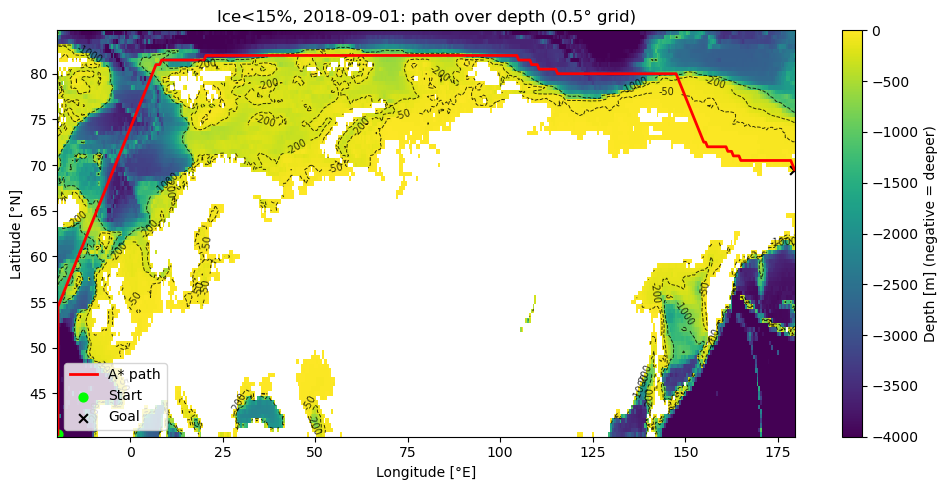

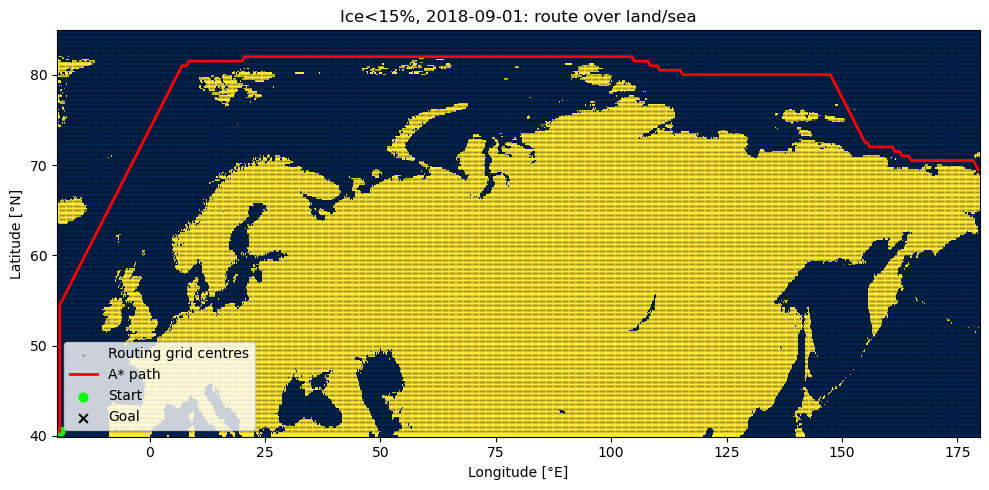

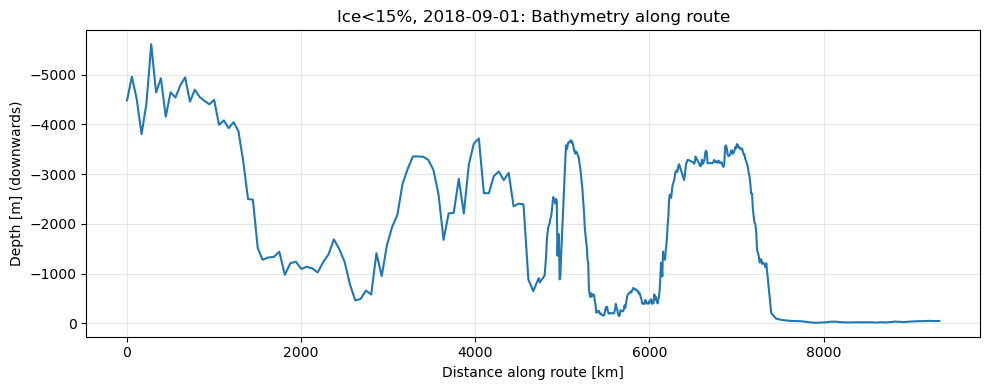

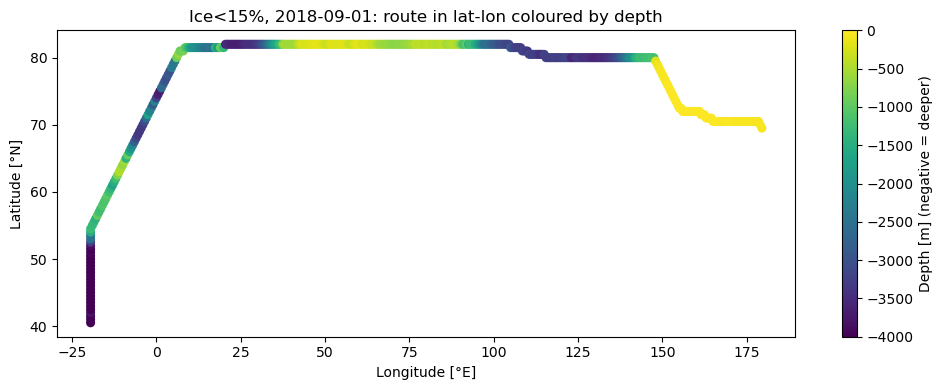

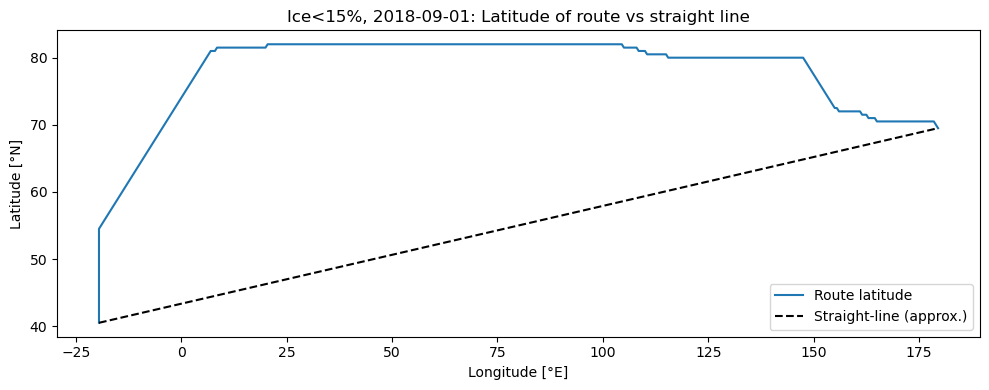

Plotting shallow sea cells: depth > -50.0 m (i.e. |depth| < 50.0 m)
  Total sea cells:         17129
  Shallow sea cells:       2630
  Fraction of sea shallow: 0.154
  Plotting 2630 shallow points as circles.


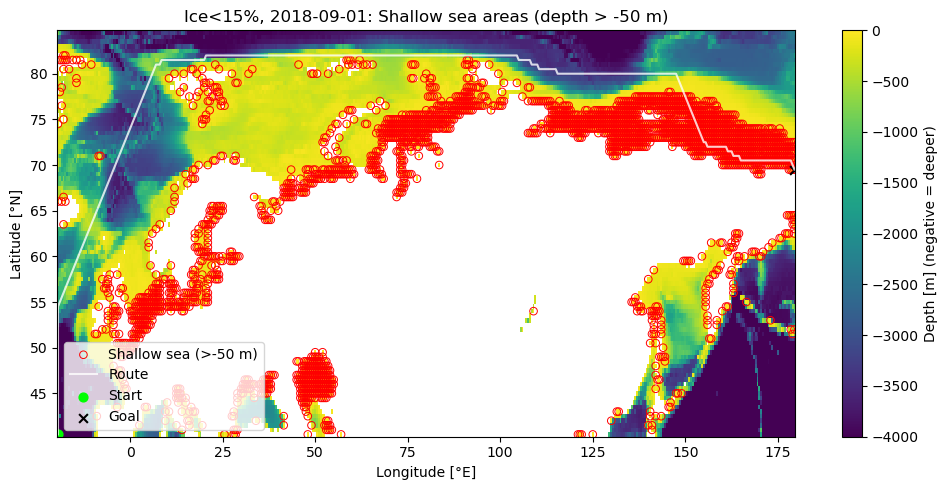

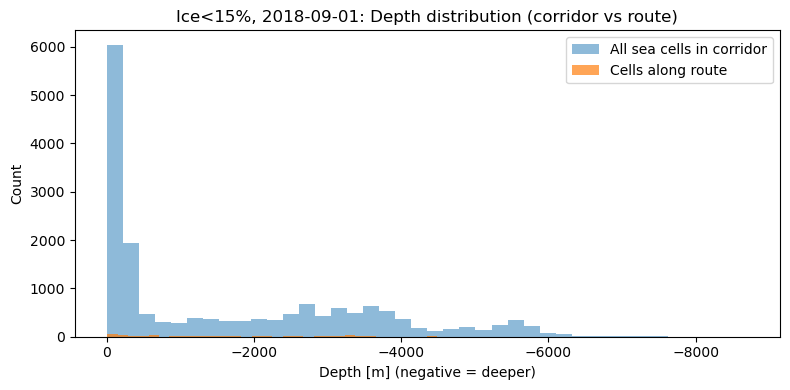

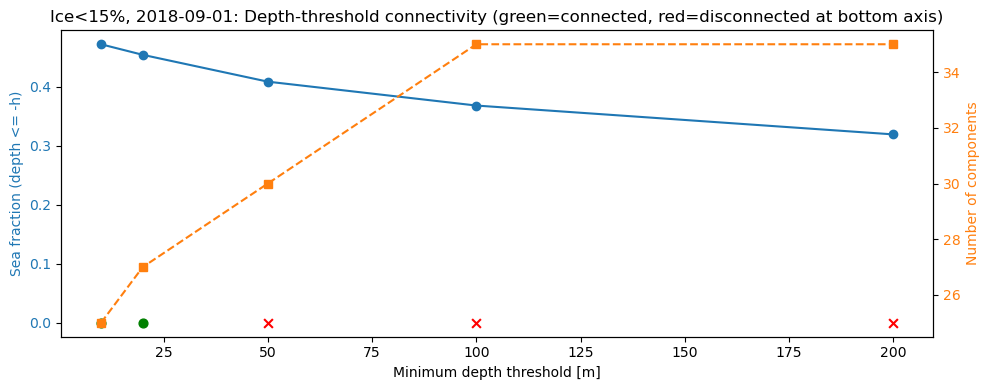

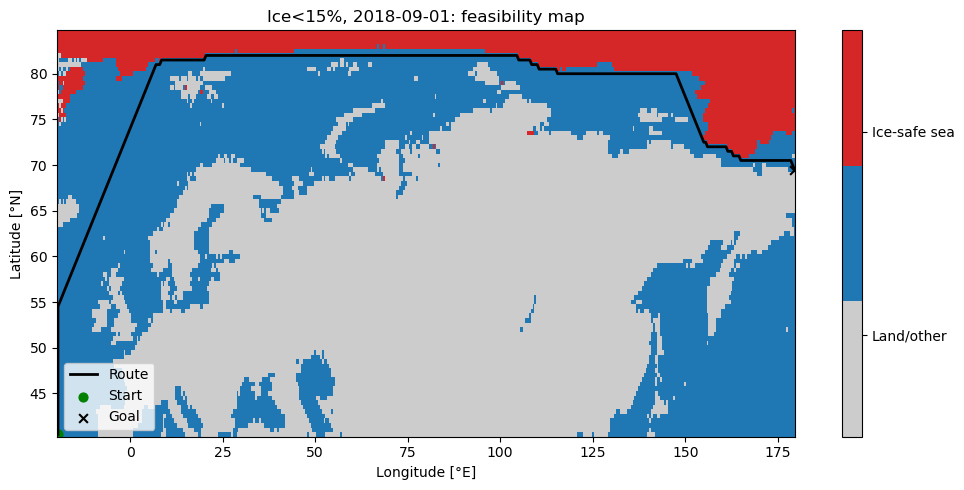

In [56]:
# Build feasibility mask for ice-only case
feas_ice = np.zeros_like(sea_mask_rg, dtype=int)
feas_ice[sea_mask_rg & (~ice_safe_mask)] = 2  # blocked by ice
feas_ice[ice_safe_mask] = 1                   # ice-safe

plot_route_diagnostics(
    path_idx=path_ice,
    lats_rg=lats_rg,
    lons_rg=lons_rg,
    lat_s=lat_s,
    lon_s=lon_s,
    land_mask_s=land_mask_s,
    depth_da=depth_rg,
    land_rg=land_rg,
    title_prefix=f"Ice<{ICE_THRESH*100:.0f}%, {str(sel_time)[:10]}",
    shallow_thresh_m=50.0,
    contour_levels=[-1000, -200, -50],
    show_depth_histogram=True,
    depth_thresholds_for_connectivity=[10, 20, 50, 100, 200],
    sea_mask_rg=sea_mask_rg,
    feasibility_mask=feas_ice,
    feasibility_labels=("Land/other", "Ice-safe sea", "Sea but ice-blocked"),
)

# Step 14

In [57]:
import numpy as np

print("=== STEP 14: Ice-only routing across multiple dates (ice < 15%) ===")

ICE_THRESH = 0.15
sea_mask = sea_mask_rg.astype(bool)

time_coord = ds_ice["time"]

# Choose a few representative dates across the season
date_strings = [
    "2018-06-15",
    "2018-07-15",
    "2018-08-15",
    "2018-09-15",
]

results = []

for ds_str in date_strings:
    target_date = np.datetime64(ds_str)
    print(f"\n--- Date: {ds_str} ---")

    # 1) select nearest time slice
    sic_slice = ds_ice["siconc"].sel(time=target_date, method="nearest")
    sel_time = sic_slice["time"].values
    print(f"Nearest CMEMS time: {sel_time}")

    # 2) normalise to 0–1 if needed
    raw_min = float(sic_slice.min())
    raw_max = float(sic_slice.max())
    print(f"siconc raw min/max: {raw_min:.3f}, {raw_max:.3f}")

    if raw_max > 1.5:
        sic_norm = sic_slice / 100.0
    else:
        sic_norm = sic_slice
    sic_norm = sic_norm.clip(0.0, 1.0)

    # 3) regrid to routing grid (nearest)
    sic_rg = sic_norm.interp(
        {lat_name: lats_rg, lon_name: lons_rg},
        method="nearest"
    )
    sic_vals = sic_rg.fillna(0.0).values  # treat NaNs as open water

    print(
        "Regridded siconc stats (0–1): "
        f"min={sic_vals.min():.3f}, mean={sic_vals.mean():.3f}, max={sic_vals.max():.3f}"
    )

    # 4) build ice-safe mask on sea
    ice_blocked = sic_vals >= ICE_THRESH
    ice_safe = sea_mask & (~ice_blocked)

    sea_frac      = sea_mask.mean()
    ice_safe_frac = ice_safe.mean()
    print(
        f"Sea fraction: {sea_frac:.3f}, "
        f"Ice-safe sea: {ice_safe_frac:.3f} ({ice_safe_frac/sea_frac*100:.1f}% of sea)"
    )

    # 5) connectivity & A* for canonical OD
    labels_ice, ncomp_ice = label_sea_components(ice_safe)
    print(f"Number of ice-safe components: {ncomp_ice}")

    si, sj = start_idx_test
    gi, gj = goal_idx_test
    lab_s = labels_ice[si, sj]
    lab_g = labels_ice[gi, gj]
    print(f"Component ID (start, goal): {lab_s} {lab_g}")

    summary = {
        "date": ds_str,
        "nearest_time": str(sel_time),
        "sea_frac": float(sea_frac),
        "ice_safe_frac": float(ice_safe_frac),
        "ice_safe_pct_of_sea": float(ice_safe_frac/sea_frac*100.0),
        "n_components": int(ncomp_ice),
        "lab_start": int(lab_s),
        "lab_goal": int(lab_g),
        "route_exists": False,
        "route_nm": np.nan,
        "gc_nm": np.nan,
        "ratio": np.nan,
    }

    if (lab_s == 0) or (lab_g == 0):
        print("  -> Start or goal outside ice-safe sea. No route.")
    elif lab_s != lab_g:
        print("  -> Start and goal in different ice-safe components. No route.")
    else:
        print("  -> Start and goal in same ice-safe component. Running A* ...")
        path = astar_route(
            ice_safe,
            si, sj,
            gi, gj,
            lats_rg, lons_rg,
            cost_mode="distance",
        )
        if path is None:
            print("     A*: No path found despite connectivity.")
        else:
            # summarise_route already prints; we also capture key stats
            # Reuse summarise_route logic here in a compact way:
            path_arr = np.array(path)
            pi = path_arr[:, 0]
            pj = path_arr[:, 1]
            lat_route = lats_rg[pi]
            lon_route = lons_rg[pj]

            def haversine(lat1, lon1, lat2, lon2):
                R = 6371.0e3
                phi1 = np.radians(lat1)
                phi2 = np.radians(lat2)
                dphi = np.radians(lat2 - lat1)
                dlambda = np.radians(lon2 - lon1)
                a = (np.sin(dphi/2)**2 +
                     np.cos(phi1)*np.cos(phi2)*np.sin(dlambda/2)**2)
                return 2 * R * np.arctan2(np.sqrt(a), np.sqrt(1-a))

            # route distance
            dists = []
            for k in range(1, len(lat_route)):
                d = haversine(lat_route[k-1], lon_route[k-1],
                              lat_route[k],   lon_route[k])
                dists.append(d)
            total_m = np.sum(dists)
            total_nm = total_m / 1852.0

            # great-circle
            gc_m = haversine(lat_route[0], lon_route[0],
                             lat_route[-1], lon_route[-1])
            gc_nm = gc_m / 1852.0
            ratio = total_nm / gc_nm if gc_nm > 0 else np.nan

            print(
                f"     Route distance: {total_nm:.1f} NM, "
                f"GC: {gc_nm:.1f} NM, ratio={ratio:.3f}"
            )

            summary["route_exists"] = True
            summary["route_nm"] = float(total_nm)
            summary["gc_nm"] = float(gc_nm)
            summary["ratio"] = float(ratio)

    results.append(summary)

print("\n=== Summary table (ice < 15%) ===")
for r in results:
    print(
        f"{r['date']}: "
        f"ice-safe sea={r['ice_safe_pct_of_sea']:.1f}% of sea, "
        f"components={r['n_components']}, "
        f"route_exists={r['route_exists']}, "
        f"route_nm={r['route_nm']:.1f}, ratio={r['ratio']:.3f}"
    )

print("=== END STEP 14 ===")

=== STEP 14: Ice-only routing across multiple dates (ice < 15%) ===

--- Date: 2018-06-15 ---
Nearest CMEMS time: 2018-06-15T00:00:00.000000000
siconc raw min/max: 0.000, 1.000
Regridded siconc stats (0–1): min=0.000, mean=0.176, max=1.000
Sea fraction: 0.482, Ice-safe sea: 0.282 (58.5% of sea)
Number of ice-safe components: 96
Component ID (start, goal): 1 0
  -> Start or goal outside ice-safe sea. No route.

--- Date: 2018-07-15 ---
Nearest CMEMS time: 2018-07-15T00:00:00.000000000
siconc raw min/max: 0.000, 1.000
Regridded siconc stats (0–1): min=0.000, mean=0.138, max=1.000
Sea fraction: 0.482, Ice-safe sea: 0.316 (65.5% of sea)
Number of ice-safe components: 66
Component ID (start, goal): 1 0
  -> Start or goal outside ice-safe sea. No route.

--- Date: 2018-08-15 ---
Nearest CMEMS time: 2018-08-15T00:00:00.000000000
siconc raw min/max: 0.000, 1.000
Regridded siconc stats (0–1): min=0.000, mean=0.093, max=1.000
Sea fraction: 0.482, Ice-safe sea: 0.371 (77.0% of sea)
Number of ice-

# Step 15

In [58]:
import numpy as np

print("=== STEP 15: Ice-only routing vs threshold (fixed date) ===")

# Fixed date where a route exists at 15%
TARGET_DATE_STR = "2018-09-15"
TARGET_DATE = np.datetime64(TARGET_DATE_STR)

sea_mask = sea_mask_rg.astype(bool)
time_coord = ds_ice["time"]

# thresholds to test (in fraction 0–1)
ice_thresholds = [0.05, 0.10, 0.15, 0.30, 0.50]

# 1) select nearest time slice once
sic_slice = ds_ice["siconc"].sel(time=TARGET_DATE, method="nearest")
sel_time = sic_slice["time"].values
print(f"Nearest CMEMS time: {sel_time}")

raw_min = float(sic_slice.min())
raw_max = float(sic_slice.max())
print(f"siconc raw min/max: {raw_min:.3f}, {raw_max:.3f}")

if raw_max > 1.5:
    sic_norm = sic_slice / 100.0
else:
    sic_norm = sic_slice
sic_norm = sic_norm.clip(0.0, 1.0)

# regrid once
sic_rg = sic_norm.interp(
    {lat_name: lats_rg, lon_name: lons_rg},
    method="nearest"
)
sic_vals = sic_rg.fillna(0.0).values

print(
    "Regridded siconc stats (0–1): "
    f"min={sic_vals.min():.3f}, mean={sic_vals.mean():.3f}, max={sic_vals.max():.3f}"
)

results_thr = []

for thr in ice_thresholds:
    print(f"\n--- Ice threshold: {thr*100:.0f}% ---")
    ice_blocked = sic_vals >= thr
    ice_safe = sea_mask & (~ice_blocked)

    sea_frac = sea_mask.mean()
    ice_safe_frac = ice_safe.mean()
    print(
        f"Sea fraction: {sea_frac:.3f}, "
        f"Ice-safe sea: {ice_safe_frac:.3f} ({ice_safe_frac/sea_frac*100:.1f}% of sea)"
    )

    labels_ice, ncomp_ice = label_sea_components(ice_safe)
    print(f"Number of ice-safe components: {ncomp_ice}")

    si, sj = start_idx_test
    gi, gj = goal_idx_test
    lab_s = labels_ice[si, sj]
    lab_g = labels_ice[gi, gj]
    print(f"Component ID (start, goal): {lab_s} {lab_g}")

    summary = {
        "thr": thr,
        "sea_frac": float(sea_frac),
        "ice_safe_frac": float(ice_safe_frac),
        "ice_safe_pct_of_sea": float(ice_safe_frac/sea_frac*100.0),
        "n_components": int(ncomp_ice),
        "lab_start": int(lab_s),
        "lab_goal": int(lab_g),
        "route_exists": False,
        "route_nm": np.nan,
        "ratio": np.nan,
    }

    if (lab_s == 0) or (lab_g == 0):
        print("  -> Start or goal outside ice-safe sea. No route.")
    elif lab_s != lab_g:
        print("  -> Start and goal in different ice-safe components. No route.")
    else:
        print("  -> Start and goal in same ice-safe component. Running A* ...")
        path = astar_route(
            ice_safe,
            si, sj,
            gi, gj,
            lats_rg, lons_rg,
            cost_mode="distance",
        )
        if path is None:
            print("     A*: No path found despite connectivity.")
        else:
            path_arr = np.array(path)
            pi = path_arr[:, 0]
            pj = path_arr[:, 1]
            lat_route = lats_rg[pi]
            lon_route = lons_rg[pj]

            def haversine(lat1, lon1, lat2, lon2):
                R = 6371.0e3
                phi1 = np.radians(lat1)
                phi2 = np.radians(lat2)
                dphi = np.radians(lat2 - lat1)
                dlambda = np.radians(lon2 - lon1)
                a = (np.sin(dphi/2)**2 +
                     np.cos(phi1)*np.cos(phi2)*np.sin(dlambda/2)**2)
                return 2 * R * np.arctan2(np.sqrt(a), np.sqrt(1-a))

            dists = []
            for k in range(1, len(lat_route)):
                d = haversine(lat_route[k-1], lon_route[k-1],
                              lat_route[k],   lon_route[k])
                dists.append(d)
            total_m = np.sum(dists)
            total_nm = total_m / 1852.0

            gc_m = haversine(lat_route[0], lon_route[0],
                             lat_route[-1], lon_route[-1])
            gc_nm = gc_m / 1852.0
            ratio = total_nm / gc_nm if gc_nm > 0 else np.nan

            print(
                f"     Route distance: {total_nm:.1f} NM, "
                f"GC: {gc_nm:.1f} NM, ratio={ratio:.3f}"
            )

            summary["route_exists"] = True
            summary["route_nm"] = float(total_nm)
            summary["ratio"] = float(ratio)

    results_thr.append(summary)

print("\n=== Summary table vs ice threshold ===")
for r in results_thr:
    print(
        f"thr={r['thr']*100:.0f}%: "
        f"ice-safe sea={r['ice_safe_pct_of_sea']:.1f}% of sea, "
        f"components={r['n_components']}, "
        f"route_exists={r['route_exists']}, "
        f"route_nm={r['route_nm']:.1f}, ratio={r['ratio']:.3f}"
    )

print("=== END STEP 15 ===")

=== STEP 15: Ice-only routing vs threshold (fixed date) ===
Nearest CMEMS time: 2018-09-15T00:00:00.000000000
siconc raw min/max: 0.000, 1.000
Regridded siconc stats (0–1): min=0.000, mean=0.083, max=1.000

--- Ice threshold: 5% ---
Sea fraction: 0.482, Ice-safe sea: 0.388 (80.4% of sea)
Number of ice-safe components: 37
Component ID (start, goal): 1 1
  -> Start and goal in same ice-safe component. Running A* ...
  A*: reached goal after visiting 17918 nodes.
     Route distance: 5024.5 NM, GC: 4149.6 NM, ratio=1.211

--- Ice threshold: 10% ---
Sea fraction: 0.482, Ice-safe sea: 0.389 (80.6% of sea)
Number of ice-safe components: 34
Component ID (start, goal): 1 1
  -> Start and goal in same ice-safe component. Running A* ...
  A*: reached goal after visiting 17939 nodes.
     Route distance: 5024.2 NM, GC: 4149.6 NM, ratio=1.211

--- Ice threshold: 15% ---
Sea fraction: 0.482, Ice-safe sea: 0.389 (80.7% of sea)
Number of ice-safe components: 33
Component ID (start, goal): 1 1
  -> St

# Step 16

=== STEP 16: Seasonal summary plots (ice < 15%) ===

Seasonal DataFrame:
         date  ice_safe_pct_of_sea  n_components  route_exists     route_nm  \
0  2018-06-15            58.549828            96         False          NaN   
1  2018-07-15            65.514624            66         False          NaN   
2  2018-08-15            76.980559            33          True  5205.967959   
3  2018-09-15            80.687723            33          True  5019.874306   

      ratio  
0       NaN  
1       NaN  
2  1.254581  
3  1.209735  


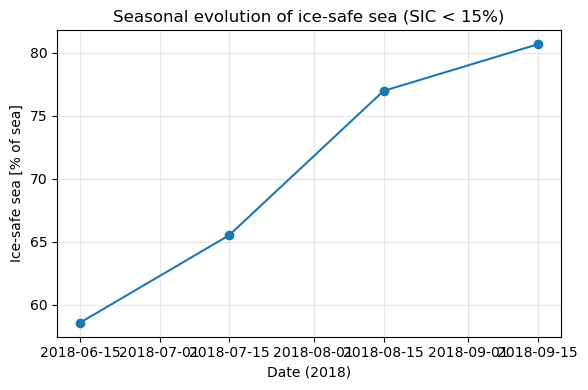

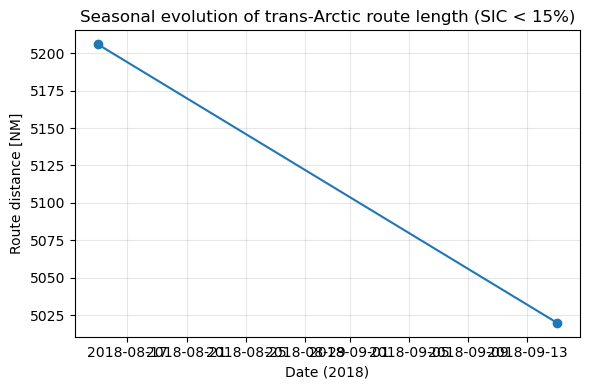

=== END STEP 16 ===


In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

print("=== STEP 16: Seasonal summary plots (ice < 15%) ===")

# Build DataFrame from results (from STEP 14)
df_season = pd.DataFrame(results)  # 'results' from STEP 14

# Parse date string to datetime for plotting
df_season["date_dt"] = pd.to_datetime(df_season["date"])

print("\nSeasonal DataFrame:")
print(df_season[["date", "ice_safe_pct_of_sea", "n_components", "route_exists", "route_nm", "ratio"]])

# 1) Plot: date vs ice-safe sea (% of sea)
plt.figure(figsize=(6, 4))
plt.plot(df_season["date_dt"], df_season["ice_safe_pct_of_sea"], marker="o")
plt.xlabel("Date (2018)")
plt.ylabel("Ice-safe sea [% of sea]")
plt.title("Seasonal evolution of ice-safe sea (SIC < 15%)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2) Plot: date vs route distance (only for dates where route exists)
mask_route = df_season["route_exists"]

plt.figure(figsize=(6, 4))
plt.plot(
    df_season.loc[mask_route, "date_dt"],
    df_season.loc[mask_route, "route_nm"],
    marker="o"
)
plt.xlabel("Date (2018)")
plt.ylabel("Route distance [NM]")
plt.title("Seasonal evolution of trans-Arctic route length (SIC < 15%)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("=== END STEP 16 ===")

# Step 17

=== STEP 17: Threshold sensitivity plots (2018-09-15) ===

Threshold DataFrame:
   thr_pct  ice_safe_pct_of_sea  n_components  route_exists     route_nm  \
0      5.0            80.430848            37          True  5024.466047   
1     10.0            80.594314            34          True  5024.207121   
2     15.0            80.687723            33          True  5019.874306   
3     30.0            81.055520            33          True  5019.874306   
4     50.0            81.470022            44          True  5018.589856   

      ratio  
0  1.210841  
1  1.210779  
2  1.209735  
3  1.209735  
4  1.209425  


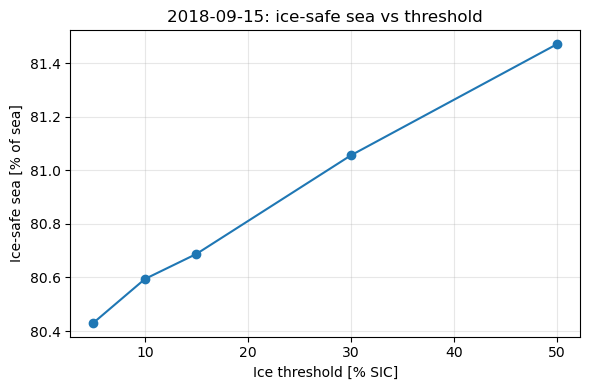

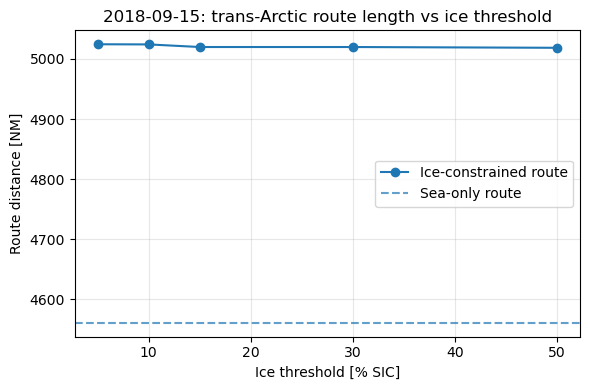

=== END STEP 17 ===


In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

print("=== STEP 17: Threshold sensitivity plots (2018-09-15) ===")

# Build DataFrame from results_thr (from STEP 15)
df_thr = pd.DataFrame(results_thr)

# Convert threshold to percent for nicer x-axis
df_thr["thr_pct"] = df_thr["thr"] * 100.0

print("\nThreshold DataFrame:")
print(df_thr[["thr_pct", "ice_safe_pct_of_sea", "n_components", "route_exists", "route_nm", "ratio"]])

# Sea-only baseline distance (from earlier bathymetry-only run)
BASELINE_SEAONLY_NM = 4561.1  # adjust if your exact value differs

# 1) Plot: threshold vs ice-safe sea (% of sea)
plt.figure(figsize=(6, 4))
plt.plot(df_thr["thr_pct"], df_thr["ice_safe_pct_of_sea"], marker="o")
plt.xlabel("Ice threshold [% SIC]")
plt.ylabel("Ice-safe sea [% of sea]")
plt.title("2018-09-15: ice-safe sea vs threshold")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2) Plot: threshold vs route distance (only thresholds with a route)
mask_route = df_thr["route_exists"]

plt.figure(figsize=(6, 4))
plt.plot(
    df_thr.loc[mask_route, "thr_pct"],
    df_thr.loc[mask_route, "route_nm"],
    marker="o",
    label="Ice-constrained route"
)

# Add horizontal line for sea-only baseline
plt.axhline(BASELINE_SEAONLY_NM, linestyle="--", label="Sea-only route", alpha=0.7)

plt.xlabel("Ice threshold [% SIC]")
plt.ylabel("Route distance [NM]")
plt.title("2018-09-15: trans-Arctic route length vs ice threshold")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("=== END STEP 17 ===")

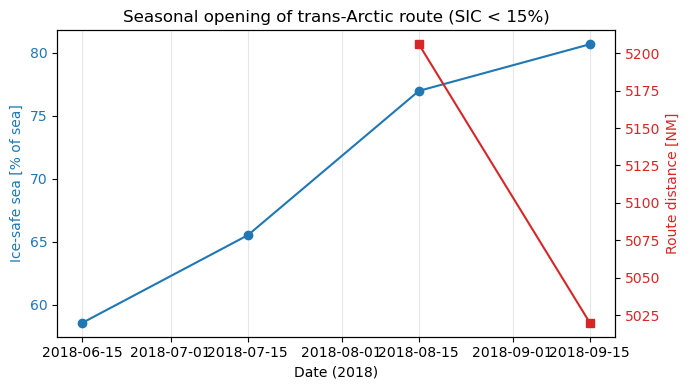

In [61]:
import matplotlib.pyplot as plt

# Use df_season from STEP 16
x = df_season["date_dt"]

fig, ax1 = plt.subplots(figsize=(7, 4))

color1 = "tab:blue"
ax1.set_xlabel("Date (2018)")
ax1.set_ylabel("Ice-safe sea [% of sea]", color=color1)
ax1.plot(x, df_season["ice_safe_pct_of_sea"], marker="o", color=color1, label="Ice-safe sea")
ax1.tick_params(axis="y", labelcolor=color1)
ax1.grid(True, axis="x", alpha=0.3)

# Second axis for route length
ax2 = ax1.twinx()
color2 = "tab:red"

mask_route = df_season["route_exists"]
ax2.set_ylabel("Route distance [NM]", color=color2)
ax2.plot(
    df_season.loc[mask_route, "date_dt"],
    df_season.loc[mask_route, "route_nm"],
    marker="s",
    linestyle="-",
    color=color2,
    label="Ice route"
)
ax2.tick_params(axis="y", labelcolor=color2)

plt.title("Seasonal opening of trans-Arctic route (SIC < 15%)")

fig.tight_layout()
plt.show()

=== STEP 17: Threshold sensitivity plots (2018-09-15) ===

Threshold DataFrame:
   thr_pct  ice_safe_pct_of_sea  n_components  route_exists     route_nm  \
0      5.0            80.430848            37          True  5024.466047   
1     10.0            80.594314            34          True  5024.207121   
2     15.0            80.687723            33          True  5019.874306   
3     30.0            81.055520            33          True  5019.874306   
4     50.0            81.470022            44          True  5018.589856   

      ratio  
0  1.210841  
1  1.210779  
2  1.209735  
3  1.209735  
4  1.209425  


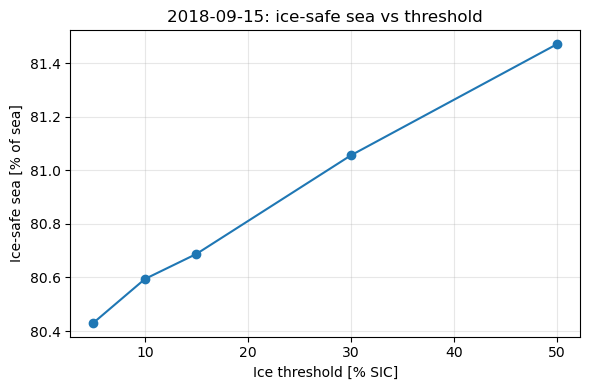

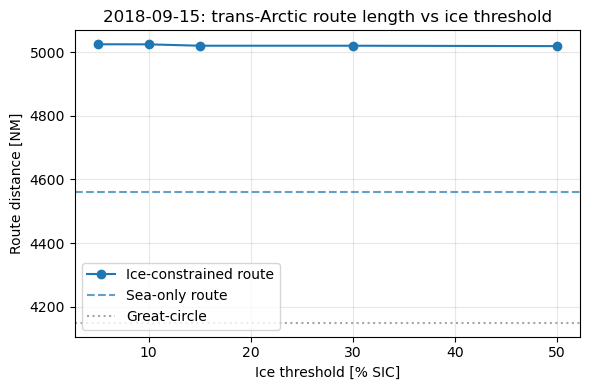

=== END STEP 17 ===


In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

print("=== STEP 17: Threshold sensitivity plots (2018-09-15) ===")

# Build DataFrame from results_thr (from STEP 15)
df_thr = pd.DataFrame(results_thr)

# Convert threshold to percent for nicer x-axis
df_thr["thr_pct"] = df_thr["thr"] * 100.0

print("\nThreshold DataFrame:")
print(df_thr[["thr_pct", "ice_safe_pct_of_sea", "n_components", "route_exists", "route_nm", "ratio"]])

# Sea-only baseline distance (from earlier bathymetry-only run)
BASELINE_SEAONLY_NM = 4561.1  # adjust if your exact value differs

# 1) Plot: threshold vs ice-safe sea (% of sea)
plt.figure(figsize=(6, 4))
plt.plot(df_thr["thr_pct"], df_thr["ice_safe_pct_of_sea"], marker="o")
plt.xlabel("Ice threshold [% SIC]")
plt.ylabel("Ice-safe sea [% of sea]")
plt.title("2018-09-15: ice-safe sea vs threshold")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2) Plot: threshold vs route distance (only thresholds with a route)
mask_route = df_thr["route_exists"]

plt.figure(figsize=(6, 4))
plt.plot(
    df_thr.loc[mask_route, "thr_pct"],
    df_thr.loc[mask_route, "route_nm"],
    marker="o",
    label="Ice-constrained route"
)

# Add horizontal line for sea-only baseline
plt.axhline(BASELINE_SEAONLY_NM, linestyle="--", label="Sea-only route", alpha=0.7)

plt.xlabel("Ice threshold [% SIC]")
plt.ylabel("Route distance [NM]")
plt.title("2018-09-15: trans-Arctic route length vs ice threshold")

GC_NM = 4149.6  # great-circle from your earlier summary

plt.axhline(GC_NM, linestyle=":", color="gray", label="Great-circle", alpha=0.7)

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("=== END STEP 17 ===")

# Step 18

=== STEP 18: Date × threshold heatmap of route/GC ratio (ice-only) ===
Great-circle distance for OD: 4149.6 NM

=== Date 2018-06-15 ===
  Nearest CMEMS time: 2018-06-15T00:00:00.000000000
  siconc raw min/max: 0.000, 1.000
  Regridded siconc stats (0–1): min=0.000, mean=0.176, max=1.000
    - Threshold 5%
      Ice-safe sea: 0.280 (58.1% of sea)
      Components=96, label(start)=1, label(goal)=0
      -> Start or goal outside ice-safe sea. No route.
    - Threshold 10%
      Ice-safe sea: 0.281 (58.3% of sea)
      Components=96, label(start)=1, label(goal)=0
      -> Start or goal outside ice-safe sea. No route.
    - Threshold 15%
      Ice-safe sea: 0.282 (58.5% of sea)
      Components=96, label(start)=1, label(goal)=0
      -> Start or goal outside ice-safe sea. No route.
    - Threshold 30%
      Ice-safe sea: 0.287 (59.5% of sea)
      Components=99, label(start)=1, label(goal)=0
      -> Start or goal outside ice-safe sea. No route.
    - Threshold 50%
      Ice-safe sea: 0.294

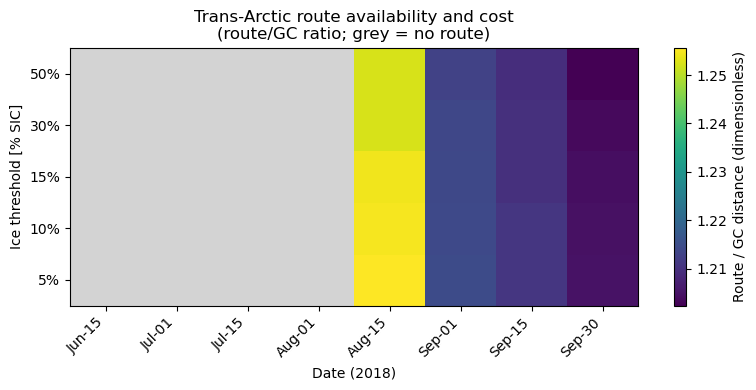

=== END STEP 18 ===


In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=== STEP 18: Date × threshold heatmap of route/GC ratio (ice-only) ===")

sea_mask = sea_mask_rg.astype(bool)
time_coord = ds_ice["time"]

# Choose a small grid of dates across the melt season
date_strings = [
    "2018-06-15",
    "2018-07-01",
    "2018-07-15",
    "2018-08-01",
    "2018-08-15",
    "2018-09-01",
    "2018-09-15",
    "2018-09-30",
]

# Thresholds (as fractions 0–1)
thresholds = [0.05, 0.10, 0.15, 0.30, 0.50]

n_dates = len(date_strings)
n_thrs  = len(thresholds)

# Output arrays [thr, date] (we'll use NaN for "no route")
route_ratio = np.full((n_thrs, n_dates), np.nan)
route_nm    = np.full((n_thrs, n_dates), np.nan)
ice_safe_pct = np.full((n_thrs, n_dates), np.nan)

# Precompute GC distance once for this OD
si, sj = start_idx_test
gi, gj = goal_idx_test
lat_s_gc = lats_rg[si]
lon_s_gc = lons_rg[sj]
lat_g_gc = lats_rg[gi]
lon_g_gc = lons_rg[gj]

def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0e3
    phi1 = np.radians(lat1)
    phi2 = np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = (np.sin(dphi/2)**2 +
         np.cos(phi1)*np.cos(phi2)*np.sin(dlambda/2)**2)
    return 2 * R * np.arctan2(np.sqrt(a), np.sqrt(1-a))

gc_m  = haversine(lat_s_gc, lon_s_gc, lat_g_gc, lon_g_gc)
GC_NM = gc_m / 1852.0
print(f"Great-circle distance for OD: {GC_NM:.1f} NM")

for j, ds_str in enumerate(date_strings):
    target_date = np.datetime64(ds_str)
    print(f"\n=== Date {ds_str} ===")

    # 1) select nearest CMEMS slice and normalise SIC
    sic_slice = ds_ice["siconc"].sel(time=target_date, method="nearest")
    sel_time = sic_slice["time"].values
    print(f"  Nearest CMEMS time: {sel_time}")

    raw_min = float(sic_slice.min())
    raw_max = float(sic_slice.max())
    print(f"  siconc raw min/max: {raw_min:.3f}, {raw_max:.3f}")

    if raw_max > 1.5:
        sic_norm = sic_slice / 100.0
    else:
        sic_norm = sic_slice
    sic_norm = sic_norm.clip(0.0, 1.0)

    # 2) regrid once for this date
    sic_rg = sic_norm.interp(
        {lat_name: lats_rg, lon_name: lons_rg},
        method="nearest"
    )
    sic_vals = sic_rg.fillna(0.0).values

    print(
        "  Regridded siconc stats (0–1): "
        f"min={sic_vals.min():.3f}, mean={sic_vals.mean():.3f}, max={sic_vals.max():.3f}"
    )

    for i, thr in enumerate(thresholds):
        print(f"    - Threshold {thr*100:.0f}%")

        ice_blocked = sic_vals >= thr
        ice_safe    = sea_mask & (~ice_blocked)

        sea_frac      = sea_mask.mean()
        ice_safe_frac = ice_safe.mean()
        pct = float(ice_safe_frac / sea_frac * 100.0)
        ice_safe_pct[i, j] = pct

        print(
            f"      Ice-safe sea: {ice_safe_frac:.3f} "
            f"({pct:.1f}% of sea)"
        )

        labels_ice, ncomp_ice = label_sea_components(ice_safe)
        lab_s = labels_ice[si, sj]
        lab_g = labels_ice[gi, gj]
        print(
            f"      Components={ncomp_ice}, "
            f"label(start)={lab_s}, label(goal)={lab_g}"
        )

        if (lab_s == 0) or (lab_g == 0):
            print("      -> Start or goal outside ice-safe sea. No route.")
            continue
        if lab_s != lab_g:
            print("      -> Start and goal in different components. No route.")
            continue

        # A* if connected
        path = astar_route(
            ice_safe,
            si, sj,
            gi, gj,
            lats_rg, lons_rg,
            cost_mode="distance",
        )
        if path is None:
            print("      -> A* failed despite connectivity.")
            continue

        path_arr = np.array(path)
        pi = path_arr[:, 0]
        pj = path_arr[:, 1]
        lat_route = lats_rg[pi]
        lon_route = lons_rg[pj]

        # route distance
        dists = []
        for k in range(1, len(lat_route)):
            d = haversine(lat_route[k-1], lon_route[k-1],
                          lat_route[k],   lon_route[k])
            dists.append(d)
        total_m  = np.sum(dists)
        total_nm = total_m / 1852.0
        ratio    = total_nm / GC_NM if GC_NM > 0 else np.nan

        route_nm[i, j]    = float(total_nm)
        route_ratio[i, j] = float(ratio)

        print(f"      -> Route: {total_nm:.1f} NM, ratio={ratio:.3f}")

print("\n=== Building heatmap ===")

# Prepare labels
dates_dt = pd.to_datetime(date_strings)
thr_pct  = np.array(thresholds) * 100.0

# Mask NaNs (no route) so they appear in a special color
data = np.ma.masked_invalid(route_ratio)

cmap = plt.cm.viridis.copy()
cmap.set_bad(color="lightgrey")  # no route = grey

fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(
    data,
    aspect="auto",
    origin="lower",
    cmap=cmap,
)

# Tick labels
ax.set_xticks(np.arange(len(date_strings)))
ax.set_xticklabels([d.strftime("%b-%d") for d in dates_dt], rotation=45, ha="right")

ax.set_yticks(np.arange(len(thresholds)))
ax.set_yticklabels([f"{p:.0f}%" for p in thr_pct])

ax.set_xlabel("Date (2018)")
ax.set_ylabel("Ice threshold [% SIC]")

cbar = plt.colorbar(im)
cbar.set_label("Route / GC distance (dimensionless)")

plt.title("Trans-Arctic route availability and cost\n(route/GC ratio; grey = no route)")
plt.tight_layout()
plt.show()

print("=== END STEP 18 ===")